# Comparison — medición Pre/Post de las reductions

Este notebook es la fuente del análisis de impacto antes/después. Construye las
cohortes de treatment, control, resto de Chile y total nacional; calcula las Holy
Tables; muestra las vistas por wave, flag y ciudad; y genera los gráficos Pre/Post.

Los indicadores AWT usan una sola definición consistente en todo el flujo:
`Null`, `0`, `1–3` y `4+`, además de la vista detallada `Null`, `0`, `1`, …,
`10`, `11+`. Los gráficos finales comparan la distribución Pre y Post.

Este notebook conserva la regla analítica del Comparison: cuando un vendor tiene
múltiples reductions, se asigna a su wave más reciente para construir cohortes que
no se superpongan. El análisis descriptivo del historial completo vive en
`wave_analysis.ipynb`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Load

### EPT reductions

In [2]:
# import pandas as pd
# import numpy as np
# pd.set_option('display.max_columns', None)
# file_path_external = '/content/drive/MyDrive/lower ept y awt/impact_measure.xlsx'

In [3]:
import pandas as pd
import gspread
from google.colab import auth
import google.auth

auth.authenticate_user()

credentials, _ = google.auth.default(scopes=[
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive"
])

gc = gspread.authorize(credentials)

sheet_id = "17lef3Nf4BOwEbtzMyvePV1wVs_1Klb1wm8Xb1wDtRfk"
sheet_name = "ept_adjustment_history"

worksheet = gc.open_by_key(sheet_id).worksheet(sheet_name)
data = worksheet.get_all_values()
reduction_raw = pd.DataFrame(data[1:], columns=data[0])

reduction_raw.head()

,executed_at,wave,flag,adjustment_scope,franchise_id,franchise_name,vendor_code,vertical_type,store_name,ept_old,ept_change_pct,ept_new,ept_change_min
0,2026-08-13 18:03,,Manual adjustment,vendor,0011r00002VoHwaAAF,Wing It - LATAM,200873,Restaurant,Wing It! - Puerto Varas,8.0,38%,11.0,3.0
1,2026-08-13 18:03,,Manual adjustment,vendor,,,593458,Restaurant,China Huo,19.0,26%,24.0,5.0
2,2026-08-13 18:03,,Manual adjustment,vendor,,,625586,Restaurant,Niflaot07,8.0,38%,11.0,3.0
3,2026-08-13 18:03,,Manual adjustment,vendor,,,627034,Pharmacy,Farmacia Skol,6.0,117%,13.0,7.0
4,2026-08-13 18:03,,Manual adjustment,vendor,,,629476,Restaurant,La Quinta Zona,13.0,77%,23.0,10.0


#### () queries dashboard

In [4]:
reduction = reduction_raw.copy()

In [5]:
reduction['start_date'] = reduction['executed_at']

In [6]:
# Convert 'wave' and 'flag' to string and strip whitespace
reduction['wave'] = reduction['wave'].astype(str).str.strip()
reduction['flag'] = reduction['flag'].astype(str).str.strip()

# Filter out rows where 'wave' is empty or 'nan' after string conversion
reduction = reduction[
    (reduction['wave'] != '') & (reduction['wave'].str.lower() != 'nan')
].copy()

# Filter out rows where 'flag' is 'Manual adjustment'
reduction = reduction[reduction['flag'] != 'Manual adjustment'].copy()

In [7]:
import pandas as pd

reduction = reduction.copy()

## Convertir start_date a fecha
reduction["start_date"] = pd.to_datetime(
    reduction["start_date"],
    errors="coerce"
)

## Eliminar fechas inválidas
reduction = reduction.dropna(subset=["start_date"])

## # Quedarse solo con los últimos 30 días
# cutoff_date = pd.Timestamp.today().normalize() - pd.Timedelta(days=30)

# reduction_30d = reduction[
#     reduction["start_date"] >= cutoff_date
# ].copy()
reduction_latest_wave = reduction.copy()
# Última wave de cada vendor
reduction_latest_wave = (
    reduction_latest_wave
    .sort_values(
        ["vendor_code", "start_date"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset=["vendor_code"],
        keep="first"
    )
    .copy()
)

# Crear identificador W6_2026-12-30
reduction_latest_wave["wave_date"] = (
    reduction_latest_wave["start_date"].dt.strftime("%Y-%m-%d")
    + "_"
    + reduction_latest_wave["wave"].astype(str)
)

# Generar CASE WHEN
case_lines = ["CASE"]

for wave_date, df_wave in reduction_latest_wave.groupby(
    "wave_date",
    sort=False
):
    vendors = (
        df_wave["vendor_code"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.replace("'", "''", regex=False)
        .unique()
    )

    vendors_string = ", ".join(f"'{vendor}'" for vendor in vendors)

    case_lines.append(
        f"  WHEN CAST(vendor_code AS STRING) IN ({vendors_string}) "
        f"THEN '{wave_date}'"
    )

case_lines.extend([
    "  ELSE NULL",
    "END"
])

case_query = "\n".join(case_lines)

print(case_query)

CASE
  WHEN CAST(vendor_code AS STRING) IN ('100004', '100697', '101354', '101365', '102287', '106869', '115870', '119308', '120974', '127845', '128638', '128884', '133584', '133585', '133605', '133625', '134139', '137518', '139902', '139914', '139922', '140569', '141111', '141482', '143550', '143815', '144829', '147474', '148502', '148636', '149308', '152400', '160176', '160248', '160249', '170841', '172457', '172842', '176943', '182109', '183636', '194185', '204005', '204405', '205345', '205374', '222103', '222913', '262376', '263454', '264652', '264653', '264960', '277456', '282865', '282867', '299049', '307148', '307269', '309089', '313536', '313789', '315994', '316068', '319597', '325354', '327489', '334534', '335169', '337620', '352620', '354027', '361954', '364058', '374879', '375826', '378810', '380097', '38752', '389824', '401741', '407962', '42007', '423514', '42452', '425859', '45345', '464915', '468774', '47138', '474788', '475015', '47514', '477367', '477996', '484236', '4

In [8]:
case_lines = ["CASE"]

for flag, df_flag in reduction_latest_wave.groupby(
    "flag",
    sort=False,
    dropna=False
):
    # Ignorar flags nulos o vacíos
    if pd.isna(flag) or str(flag).strip() == "":
        continue

    vendors = (
        df_flag["vendor_code"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.replace("'", "''", regex=False)
        .unique()
    )

    vendors_string = ", ".join(
        f"'{vendor}'"
        for vendor in vendors
    )

    flag_clean = str(flag).strip().replace("'", "''")

    case_lines.append(
        f"  WHEN CAST(vendor_code AS STRING) IN ({vendors_string}) "
        f"THEN '{flag_clean}'"
    )

case_lines.extend([
    "  ELSE NULL",
    "END"
])

case_flag_query = "\n".join(case_lines)

print(case_flag_query)

CASE
  WHEN CAST(vendor_code AS STRING) IN ('100004', '101277', '101354', '104663', '106865', '110763', '116924', '120086', '120302', '120784', '122583', '129625', '133189', '137884', '140418', '141215', '144867', '147488', '160248', '161938', '183636', '188225', '188363', '189791', '190525', '196312', '198522', '198524', '198535', '203161', '204405', '225275', '234113', '234301', '244254', '264970', '276009', '277300', '301940', '313536', '315714', '327489', '334534', '337718', '346960', '353613', '354027', '368454', '370051', '376701', '385297', '396521', '398553', '408657', '409726', '413261', '418601', '422024', '425859', '428735', '438444', '446236', '456503', '458188', '481572', '481600', '482291', '483681', '484237', '506001', '508222', '509893', '509897', '514281', '514744', '515484', '519454', '52577', '52578', '530738', '531455', '538349', '540804', '54426', '546716', '547969', '548387', '548887', '549464', '552405', '553502', '561992', '564143', '564157', '564180', '565244',

In [9]:
import pandas as pd
from datetime import date, timedelta

# Convert 'start_date' to datetime.date objects
reduction['start_date'] = pd.to_datetime(reduction['start_date']).dt.date

# Calculate the date 30 days ago from today
today_date = date.today()
thirty_days_ago_date = today_date - timedelta(days=30)

# Filter for reductions from the last 30 days
reduction = reduction[reduction['start_date'] >= thirty_days_ago_date].copy()

reduction.head()

,executed_at,wave,flag,adjustment_scope,franchise_id,franchise_name,vendor_code,vertical_type,store_name,ept_old,ept_change_pct,ept_new,ept_change_min,start_date
115,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,523373,MISSING,Alemán Experto - Providencia,14.6,-35%,9.5,-5.2,2026-08-31
116,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,66806,MISSING,Alemán Experto - Vitacura,20.1,-26%,14.8,-5.2,2026-08-31
117,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,370667,MISSING,Alemán Experto Chicureo,21.2,-32%,14.4,-6.8,2026-08-31
118,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,399367,MISSING,Alemán Experto Macul,18.3,-33%,12.2,-6.1,2026-08-31
119,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoIQIAA3,American (mechado),408558,MISSING,American Burger - Coronel,17.5,-37%,11.0,-6.5,2026-08-31


In [10]:
# quitar waves de hoy
reduction['start_date'] = pd.to_datetime(reduction['start_date']).dt.date
today_date = date.today()
thirty_days_ago_date = today_date - timedelta(days=0)
reduction = reduction[reduction['start_date'] < thirty_days_ago_date].copy()

reduction.head()

,executed_at,wave,flag,adjustment_scope,franchise_id,franchise_name,vendor_code,vertical_type,store_name,ept_old,ept_change_pct,ept_new,ept_change_min,start_date
115,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,523373,MISSING,Alemán Experto - Providencia,14.6,-35%,9.5,-5.2,2026-08-31
116,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,66806,MISSING,Alemán Experto - Vitacura,20.1,-26%,14.8,-5.2,2026-08-31
117,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,370667,MISSING,Alemán Experto Chicureo,21.2,-32%,14.4,-6.8,2026-08-31
118,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,399367,MISSING,Alemán Experto Macul,18.3,-33%,12.2,-6.1,2026-08-31
119,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoIQIAA3,American (mechado),408558,MISSING,American Burger - Coronel,17.5,-37%,11.0,-6.5,2026-08-31


### query maker

## Universo y reglas de esta versión

### `comparison` versus `timings_awt`

| Regla del universo | `comparison` | `timings_awt` |
|---|---:|---:|
| Chile | Sí | Sí |
| `peya_order_id IS NOT NULL` | Sí | Sí |
| `d.is_primary = TRUE` | Sí | Sí |
| `p.is_online = TRUE` | Sí | No |
| Excluir preorders | Sí | No |
| Excluir `courier_business` | Sí | No |

### Regla de waves

- Si un vendor aparece en más de una wave, se conserva únicamente su wave más
  reciente (`latest`).
- Post comienza en `start_date` y usa como máximo 14 días, incluyendo el día de
  inicio.
- Mientras no hayan pasado los 14 días, se usan solo los días disponibles.
- Después del día 14, la wave queda cerrada y sus fechas no siguen creciendo.
- Solo los vendors con órdenes en Pre y Post entran a las Holy Tables; los casos
  perdidos quedan en la auditoría de cohorte.

### Nombres de AWT

- `awt10` y `awt10_ratio`: métrica causal histórica.
- `awt_null`, `awt_0min`, `awt_1_3min`, `awt_4plus`: cuatro buckets no superpuestos usados en tablas y gráficos.

Las tablas por wave son independientes. Si se suman waves con fechas solapadas,
el total `General` puede repetir órdenes entre waves.
### Lectura country level

- `all_chile`: todo el universo CL elegible, incluidas otras waves.
- `resto_de_chile`: excluye vendors de todas las waves seleccionadas.
- Ambos agregados se conservan separados por `vertical_type`; la tabla CL general vuelve a sumarlos y la tabla restaurants filtra antes de calcular.
- `CL limpio`: treatment de la wave actual + `resto_de_chile`.
- El aporte estimado pondera el DID treatment-versus-resto por el peso
  Post de la wave en el denominador nacional de cada métrica.


In [11]:
from datetime import date, datetime, timedelta
from zoneinfo import ZoneInfo
from IPython.display import display
import json
import pandas as pd


def build_vendor_pre_post_query(
    reduction_df,
    today=None,
    timezone="America/Santiago",
    max_days=14
):
    """
    Preserva el nombre original de cada wave y devuelve:
    - treatment: vendors incluidos en la wave.
    - control: vendors no intervenidos de las mismas franchises (puede no existir).
    - resto_de_chile: vendors fuera de todas las waves seleccionadas,
      agregados por vertical_type.
    - all_chile: universo CL elegible agregado por vertical_type.

    Si un vendor aparece en varias waves, conserva solo la más reciente.
    Cada wave usa como máximo 14 días Post desde su fecha de inicio.

    Long tail puede pertenecer a treatment aunque no tenga franchise_name.
    courier_business se excluye desde la base.
    """

    required_cols = {
        "wave", "start_date", "franchise_name", "vendor_code"
    }
    missing_cols = required_cols.difference(reduction_df.columns)

    if missing_cols:
        raise ValueError(
            f"Faltan columnas en reduction_df: {sorted(missing_cols)}"
        )

    def parse_date(value):
        if isinstance(value, datetime):
            return value.date()
        if isinstance(value, date):
            return value
        return pd.to_datetime(value, errors="raise").date()

    def bq_string(value):
        # Mismo formato de comparison (26): strings SQL con comillas dobles.
        # Ejemplo: Wendy's -> "Wendy's".
        return json.dumps(str(value), ensure_ascii=False)

    def bq_array(values, indent=0):
        # Lista normal de BigQuery: ["a", "b"].
        # No agrega un tipo explícito delante de la lista.
        clean_values = sorted({
            str(value).strip()
            for value in values
            if pd.notna(value) and str(value).strip()
        })
        return "[" + ", ".join(
            bq_string(value) for value in clean_values
        ) + "]"

    today = (
        datetime.now(ZoneInfo(timezone)).date()
        if today is None
        else parse_date(today)
    )

    reduction_clean = reduction_df.copy()
    reduction_clean["start_date"] = pd.to_datetime(
        reduction_clean["start_date"],
        errors="coerce"
    ).dt.date

    for col in ["wave", "franchise_name", "vendor_code"]:
        reduction_clean[col] = (
            reduction_clean[col]
            .astype("string")
            .str.strip()
            .fillna("")
            .replace({"nan": "", "none": ""})
        )

    reduction_clean["vendor_code"] = (
        reduction_clean["vendor_code"]
        .str.replace(r"\.0$", "", regex=True)
    )

    valid = (
        reduction_clean["start_date"].notna()
        & reduction_clean["wave"].ne("")
        & reduction_clean["wave"].str.lower().ne("nan")
        & reduction_clean["vendor_code"].ne("")
        & reduction_clean["vendor_code"].str.lower().ne("nan")
    )
    reduction_clean = reduction_clean[valid].copy()

    if reduction_clean.empty:
        raise ValueError("No quedaron filas válidas en reduction_df.")

    reduction_latest = (
        reduction_clean
        .sort_values(
            ["vendor_code", "start_date"],
            ascending=[True, False]
        )
        .drop_duplicates("vendor_code", keep="first")
        .copy()
    )

    wave_date_counts = (
        reduction_latest.groupby("wave")["start_date"].nunique()
    )
    invalid_waves = wave_date_counts[wave_date_counts > 1].index.tolist()

    if invalid_waves:
        raise ValueError(
            "Cada wave debe tener una sola start_date. "
            f"Revisar: {invalid_waves}"
        )

    wave_config = (
        reduction_latest[["wave", "start_date"]]
        .drop_duplicates()
        .sort_values(["start_date", "wave"])
    )

    yesterday = today - timedelta(days=1)
    period_structs = []

    for row in wave_config.itertuples(index=False):
        wave = row.wave
        inicio_post = row.start_date

        if inicio_post > yesterday:
            raise ValueError(
                f"{wave}: start_date={inicio_post} es posterior a ayer={yesterday}."
            )

        n_days = min((yesterday - inicio_post).days + 1, max_days)
        if n_days <= 0:
            raise ValueError(f"{wave}: no hay días post disponibles.")

        fin_post = inicio_post + timedelta(days=n_days - 1)
        inicio_pre = inicio_post - timedelta(days=7)
        fin_pre = inicio_pre + timedelta(days=n_days - 1)

        while fin_pre >= inicio_post:
            inicio_pre -= timedelta(days=7)
            fin_pre -= timedelta(days=7)

        wave_rows = reduction_latest[
            reduction_latest["wave"].eq(wave)
        ]

        period_structs.append(f"""    STRUCT(
      {bq_string(wave)} AS wave,
      DATE '{inicio_pre}' AS inicio_pre,
      DATE '{fin_pre}' AS fin_pre,
      DATE '{inicio_post}' AS inicio_post,
      DATE '{fin_post}' AS fin_post,
      {bq_array(wave_rows["franchise_name"], indent=6)} AS franchises,
      {bq_array(wave_rows["vendor_code"], indent=6)} AS treatment_vendors
    )""")

    period_config_sql = ",\n".join(period_structs)
    selected_wave_vendors_sql = bq_array(
        reduction_latest["vendor_code"],
        indent=4
    )
    # Definición exacta de timings_awt:
    # awt_0min = 0; awt_1min = (0, 1]; awt_2min = (1, 2]; ...;
    # awt_20min = (19, 20); awt_21plus = [20, +inf).
    awt_detail_specs = [
        (bucket, f"awt_{bucket}min")
        for bucket in range(2, 21)
    ]

    awt_detail_count_sql = ",\n".join(
        f"""    COUNT(DISTINCT IF(
      awt_bucket = {bucket},
      peya_order_id,
      NULL
    )) AS awt_{bucket}_orders"""
        for bucket, _ in awt_detail_specs
    )

    awt_detail_count_sql += """,
    COUNT(DISTINCT IF(
      awt_bucket = 21,
      peya_order_id,
      NULL
    )) AS awt_21plus_orders"""

    awt_detail_count_select_sql = ",\n".join(
        f"  v.awt_{bucket}_orders"
        for bucket, _ in awt_detail_specs
    )
    awt_detail_count_select_sql += ",\n  v.awt_21plus_orders"

    awt_detail_ratio_select_sql = ",\n".join(
        f"""  ROUND(SAFE_DIVIDE(
    v.awt_{bucket}_orders, v.total_orders
  ), 4) AS {share_col}"""
        for bucket, share_col in awt_detail_specs
    )
    awt_detail_ratio_select_sql += """,
  ROUND(SAFE_DIVIDE(
    v.awt_21plus_orders, v.total_orders
  ), 4) AS awt_21plus"""

    query = f"""
WITH period_config AS (
  SELECT *
  FROM UNNEST([
{period_config_sql}
  ])
),

global_wave_config AS (
  SELECT
    {selected_wave_vendors_sql} AS vendors_in_selected_waves
),

date_bounds AS (
  SELECT
    MIN(inicio_pre) AS min_date,
    MAX(fin_post) AS max_date
  FROM period_config
),

base_raw AS (
  SELECT
    l.peya_order_id,
    CAST(l.vendor.vendor_code AS STRING) AS vendor_code,
    COALESCE(p.partner_name, l.vendor.name) AS store_name,
    l.city.city_name AS city_name,
    CAST(p.franchise.franchise_id AS STRING) AS franchise_id,
    p.franchise.franchise_name AS franchise_name,
    l.vendor.vertical_type AS vertical_type,
    l.food_is_ready_at,
    DATE(l.created_date_local) AS order_date,
    SAFE_DIVIDE(l.estimated_prep_time, 60) AS ept_min,
    SAFE_DIVIDE(l.timings.avoidable_wait_time, 60) AS awt_min,
    SAFE_DIVIDE(
      DATETIME_DIFF(
        d.rider_picked_up_at_local,
        l.sent_to_vendor_at_local,
        SECOND
      ),
      60.0
    ) AS pickup_time_min,
    o.is_slow_order AS slow,
    o.non_seamless_order AS non_seamless

  FROM `peya-bi-tools-pro.il_logistics.fact_logistic_orders` l
  LEFT JOIN UNNEST(l.deliveries) d
  LEFT JOIN `peya-bi-tools-pro.il_core.dim_partner` p
    ON l.vendor.vendor_code = CAST(p.partner_id AS STRING)
  LEFT JOIN `peya-datamarts-pro.dm_fulfillment.non_seamless_delivery_order_level` o
    ON o.platform_order_code = l.peya_order_id
  CROSS JOIN date_bounds db

  WHERE l.country_code = 'cl'
    AND l.peya_order_id IS NOT NULL
    AND d.is_primary = TRUE
    AND p.is_online = TRUE
    AND l.is_preorder = FALSE
    AND COALESCE(l.vendor.vertical_type, '') != 'courier_business'
    AND DATE(l.created_date_local) BETWEEN db.min_date AND db.max_date
),

base AS (
  SELECT
    br.*,
    CASE
      WHEN br.awt_min IS NULL THEN NULL
      WHEN br.awt_min = 0 THEN 0
      WHEN br.awt_min >= 20 THEN 21
      ELSE CAST(CEIL(br.awt_min) AS INT64)
    END AS awt_bucket
  FROM base_raw br
),

base_labeled_raw AS (
  SELECT
    b.*,
    pc.wave,
    pc.inicio_pre,
    pc.fin_pre,
    pc.inicio_post,
    pc.fin_post,

    CASE
      WHEN b.order_date BETWEEN pc.inicio_pre AND pc.fin_pre THEN 'pre'
      WHEN b.order_date BETWEEN pc.inicio_post AND pc.fin_post THEN 'post'
    END AS period,

    CASE
      WHEN b.vendor_code IN UNNEST(pc.treatment_vendors)
        THEN 'treatment'
      WHEN b.franchise_name IN UNNEST(pc.franchises)
       AND b.vendor_code NOT IN UNNEST(g.vendors_in_selected_waves)
        THEN 'control'
      -- resto_de_chile se construye aparte para que también incluya
      -- los vendors de control. Aquí no se usa como categoría excluyente.
      ELSE 'exclude'
    END AS analysis_group

  FROM base b
  CROSS JOIN period_config pc
  CROSS JOIN global_wave_config g

  WHERE
    b.order_date BETWEEN pc.inicio_pre AND pc.fin_pre
    OR b.order_date BETWEEN pc.inicio_post AND pc.fin_post
),

-- Referencia nacional independiente: todos los vendors que no están en
-- ninguna wave. Un vendor de control también pertenece a esta referencia.
resto_labeled_raw AS (
  SELECT
    b.*,
    pc.wave,
    pc.inicio_pre,
    pc.fin_pre,
    pc.inicio_post,
    pc.fin_post,
    CASE
      WHEN b.order_date BETWEEN pc.inicio_pre AND pc.fin_pre THEN 'pre'
      WHEN b.order_date BETWEEN pc.inicio_post AND pc.fin_post THEN 'post'
    END AS period,
    'resto_de_chile' AS analysis_group
  FROM base b
  CROSS JOIN period_config pc
  CROSS JOIN global_wave_config g
  WHERE b.vendor_code NOT IN UNNEST(g.vendors_in_selected_waves)
    AND (
      b.order_date BETWEEN pc.inicio_pre AND pc.fin_pre
      OR b.order_date BETWEEN pc.inicio_post AND pc.fin_post
    )
),

-- Total nacional independiente. Incluye treatment, otras waves,
-- control y resto; sirve para medir el cambio CL realmente observado.
all_chile_labeled_raw AS (
  SELECT
    b.*,
    pc.wave,
    pc.inicio_pre,
    pc.fin_pre,
    pc.inicio_post,
    pc.fin_post,
    CASE
      WHEN b.order_date BETWEEN pc.inicio_pre AND pc.fin_pre THEN 'pre'
      WHEN b.order_date BETWEEN pc.inicio_post AND pc.fin_post THEN 'post'
    END AS period,
    'all_chile' AS analysis_group
  FROM base b
  CROSS JOIN period_config pc
  WHERE
    b.order_date BETWEEN pc.inicio_pre AND pc.fin_pre
    OR b.order_date BETWEEN pc.inicio_post AND pc.fin_post
),

base_labeled_union AS (
  SELECT * FROM base_labeled_raw
  UNION ALL
  SELECT * FROM resto_labeled_raw
  UNION ALL
  SELECT * FROM all_chile_labeled_raw
),

chile_period_orders AS (
  SELECT
    wave,
    period,
    COUNT(DISTINCT peya_order_id) AS cl_total_orders
  FROM base_labeled_raw
  WHERE period IS NOT NULL
  GROUP BY
    wave,
    period
),

base_labeled AS (
  SELECT
    peya_order_id,
    wave,
    inicio_pre,
    fin_pre,
    inicio_post,
    fin_post,
    period,
    analysis_group,

    CASE
      WHEN analysis_group = 'resto_de_chile' THEN '__RESTO_DE_CHILE__'
      WHEN analysis_group = 'all_chile' THEN '__ALL_CHILE__'
      ELSE franchise_id
    END AS franchise_id,
    CASE
      WHEN analysis_group = 'resto_de_chile' THEN 'resto_de_chile'
      WHEN analysis_group = 'all_chile' THEN 'all_chile'
      ELSE franchise_name
    END AS franchise_name,
    CASE
      WHEN analysis_group = 'resto_de_chile' THEN '__RESTO_DE_CHILE__'
      WHEN analysis_group = 'all_chile' THEN '__ALL_CHILE__'
      ELSE vendor_code
    END AS vendor_code,
    CASE
      WHEN analysis_group = 'resto_de_chile' THEN 'resto_de_chile'
      WHEN analysis_group = 'all_chile' THEN 'all_chile'
      ELSE store_name
    END AS store_name,
    CASE
      WHEN analysis_group IN ('resto_de_chile', 'all_chile') THEN 'Chile'
      ELSE city_name
    END AS city_name,
    -- Mantener el vertical real permite reconstruir tanto CL total
    -- como el impacto nacional específico de restaurants.
    vertical_type AS vertical_type,

    food_is_ready_at,
    ept_min,
    awt_min,
    awt_bucket,
    pickup_time_min,
    slow,
    non_seamless

  FROM base_labeled_union
  WHERE analysis_group != 'exclude'
),

base_order_keys AS (
  SELECT DISTINCT
    CAST(peya_order_id AS STRING) AS order_id,
    wave,
    inicio_pre,
    fin_pre,
    inicio_post,
    fin_post,
    period,
    analysis_group,
    franchise_id,
    franchise_name,
    vendor_code,
    store_name,
    city_name,
    vertical_type
  FROM base_labeled
),

vendor_metrics AS (
  SELECT
    wave,
    analysis_group,
    franchise_id,
    franchise_name,
    vendor_code,
    store_name,
    city_name,
    vertical_type,
    period,
    inicio_pre,
    fin_pre,
    inicio_post,
    fin_post,

    COUNT(DISTINCT peya_order_id) AS total_orders,
    COUNT(DISTINCT IF(
      food_is_ready_at IS NOT NULL, peya_order_id, NULL
    )) AS orders_with_fir,
    SAFE_DIVIDE(
      COUNT(DISTINCT IF(
        food_is_ready_at IS NOT NULL, peya_order_id, NULL
      )),
      COUNT(DISTINCT peya_order_id)
    ) AS fir,
    COUNT(DISTINCT IF(slow = 1, peya_order_id, NULL)) AS slow_orders,
    COUNT(DISTINCT IF(
      non_seamless = TRUE, peya_order_id, NULL
    )) AS non_seamless_orders,
    COUNT(DISTINCT IF(
      awt_min IS NULL, peya_order_id, NULL
    )) AS awt_null_orders,
    COUNT(DISTINCT IF(
      awt_bucket = 0, peya_order_id, NULL
    )) AS awt_0_orders,
    COUNT(DISTINCT IF(
      awt_bucket = 1, peya_order_id, NULL
    )) AS awt_1_orders,
{awt_detail_count_sql},
    -- Se conserva para compatibilidad: buckets 2 o superiores.
    COUNT(DISTINCT IF(
      awt_bucket >= 2, peya_order_id, NULL
    )) AS awt_2plus_orders,

    SUM(ept_min) AS ept_sum,
    COUNT(DISTINCT IF(
      ept_min IS NOT NULL, peya_order_id, NULL
    )) AS ept_orders,
    SUM(awt_min) AS awt_sum,
    COUNT(DISTINCT IF(
      awt_min IS NOT NULL, peya_order_id, NULL
    )) AS awt_orders,
    SUM(pickup_time_min) AS pickup_time_sum,
    COUNT(DISTINCT IF(
      pickup_time_min IS NOT NULL, peya_order_id, NULL
    )) AS pickup_time_orders,

    ROUND(SAFE_DIVIDE(
      SUM(ept_min),
      COUNT(DISTINCT IF(ept_min IS NOT NULL, peya_order_id, NULL))
    ), 2) AS ept,
    ROUND(SAFE_DIVIDE(
      SUM(awt_min),
      COUNT(DISTINCT IF(awt_min IS NOT NULL, peya_order_id, NULL))
    ), 2) AS awt,
    ROUND(
      SAFE_DIVIDE(
        SUM(ept_min),
        COUNT(DISTINCT IF(ept_min IS NOT NULL, peya_order_id, NULL))
      )
      + SAFE_DIVIDE(
        SUM(awt_min),
        COUNT(DISTINCT IF(awt_min IS NOT NULL, peya_order_id, NULL))
      ),
      2
    ) AS tt,
    ROUND(SAFE_DIVIDE(
      SUM(pickup_time_min),
      COUNT(DISTINCT IF(
        pickup_time_min IS NOT NULL, peya_order_id, NULL
      ))
    ), 2) AS ctp

  FROM base_labeled
  GROUP BY
    wave,
    analysis_group,
    franchise_id,
    franchise_name,
    vendor_code,
    store_name,
    city_name,
    vertical_type,
    period,
    inicio_pre,
    fin_pre,
    inicio_post,
    fin_post
),

ns_metrics AS (
  SELECT
    bok.wave,
    bok.analysis_group,
    bok.franchise_id,
    bok.franchise_name,
    bok.vendor_code,
    bok.store_name,
    bok.city_name,
    bok.vertical_type,
    bok.period,
    bok.inicio_pre,
    bok.fin_pre,
    bok.inicio_post,
    bok.fin_post,

    COUNT(DISTINCT n.order_id) AS ns_distinct_orders,
    COUNT(DISTINCT IF(
      n.SEAMLESS = 0, n.order_id, NULL
    )) AS ns_non_seamless_orders,
    COUNT(DISTINCT IF(
      n.SEAMLESS = 1, n.order_id, NULL
    )) AS ns_seamless_orders,
    SUM(COALESCE(n.PARTNER_PERFORMANCE, 0)) AS partner_perfo,

    SUM(
      COALESCE(n.TR_HIGH_PREP_TIME, 0)
        + COALESCE(n.TR_HIGH_PREP_TIME_AND_DISTANCE, 0) / 2
        + COALESCE(
            n.TR_HIGH_PREP_TIME_AND_DISTANCE_COMBINATION, 0
          ) / 2
    ) AS high_preptimes,

    SUM(
      IF(
        IFNULL(n.undispatch_reason, '') != 'Late Order Preparation',
        COALESCE(n.TR_STAFFING_AND_PARTNER_PERFO, 0) / 2
          + COALESCE(
              n.TR_STAFFING_RIDER_AND_PARTNER_PERFO, 0
            ) / 3
          + COALESCE(n.TR_RIDER_AND_PARTNER_PERFO, 0) / 2
          + COALESCE(n.TR_PARTNER_PERFO, 0),
        0
      )
    ) AS awt10,

    SUM(COALESCE(n.PREDICTION_MODEL, 0)) AS prediction_model

  FROM `peya-delivery-and-support.automated_tables_reports.non_seamless_reasons` n
  CROSS JOIN date_bounds db
  INNER JOIN base_order_keys bok
    ON CAST(n.order_id AS STRING) = bok.order_id

  WHERE n.country_name = 'Chile'
    AND n.created_date_local BETWEEN db.min_date AND db.max_date

  GROUP BY
    bok.wave,
    bok.analysis_group,
    bok.franchise_id,
    bok.franchise_name,
    bok.vendor_code,
    bok.store_name,
    bok.city_name,
    bok.vertical_type,
    bok.period,
    bok.inicio_pre,
    bok.fin_pre,
    bok.inicio_post,
    bok.fin_post
)

SELECT
  v.wave,
  v.analysis_group,
  v.franchise_id,
  v.franchise_name,
  v.vendor_code,
  v.store_name,
  v.city_name,
  v.vertical_type,
  v.period,
  v.inicio_pre,
  v.fin_pre,
  v.inicio_post,
  v.fin_post,
  c.cl_total_orders,

  v.total_orders,
  v.orders_with_fir,
  ROUND(v.fir, 4) AS fir,
  v.slow_orders,
  ROUND(SAFE_DIVIDE(
    v.slow_orders, v.total_orders
  ), 4) AS slow_orders_ratio,
  v.non_seamless_orders,
  ROUND(SAFE_DIVIDE(
    v.non_seamless_orders, v.total_orders
  ), 4) AS non_seamless_orders_ratio,
  v.awt_null_orders,
  v.awt_0_orders,
  v.awt_1_orders,
{awt_detail_count_select_sql},
  v.awt_2plus_orders,
  ROUND(SAFE_DIVIDE(
    v.awt_null_orders, v.total_orders
  ), 4) AS awt_null,
  ROUND(SAFE_DIVIDE(
    v.awt_0_orders, v.total_orders
  ), 4) AS awt_0min,
  ROUND(SAFE_DIVIDE(
    v.awt_1_orders, v.total_orders
  ), 4) AS awt_1min,
{awt_detail_ratio_select_sql},
  ROUND(SAFE_DIVIDE(
    v.awt_2plus_orders, v.total_orders
  ), 4) AS awt_2plus,
  v.ept_sum,
  v.ept_orders,
  v.awt_sum,
  v.awt_orders,
  v.pickup_time_sum,
  v.pickup_time_orders,
  v.ept,
  v.awt,
  v.tt,
  v.ctp,

  COALESCE(ns.ns_distinct_orders, 0) AS ns_distinct_orders,
  COALESCE(ns.ns_non_seamless_orders, 0) AS ns_non_seamless_orders,
  COALESCE(ns.ns_seamless_orders, 0) AS ns_seamless_orders,

  ROUND(COALESCE(ns.partner_perfo, 0), 4) AS partner_perfo,
  ROUND(SAFE_DIVIDE(
    COALESCE(ns.partner_perfo, 0), v.total_orders
  ), 4) AS partner_perfo_ratio,

  ROUND(COALESCE(ns.high_preptimes, 0), 4) AS high_preptimes,
  ROUND(SAFE_DIVIDE(
    COALESCE(ns.high_preptimes, 0), v.total_orders
  ), 4) AS high_preptimes_ratio,

  ROUND(COALESCE(ns.awt10, 0), 4) AS awt10,
  ROUND(SAFE_DIVIDE(
    COALESCE(ns.awt10, 0), v.total_orders
  ), 4) AS awt10_ratio,

  ROUND(COALESCE(ns.prediction_model, 0), 4) AS prediction_model,
  ROUND(SAFE_DIVIDE(
    COALESCE(ns.prediction_model, 0), v.total_orders
  ), 4) AS prediction_model_ratio

FROM vendor_metrics v
LEFT JOIN chile_period_orders c
  ON v.wave = c.wave
 AND v.period = c.period
LEFT JOIN ns_metrics ns
  ON v.wave = ns.wave
 AND v.analysis_group = ns.analysis_group
 AND COALESCE(v.franchise_id, '__NULL_FRANCHISE_ID__')
     = COALESCE(ns.franchise_id, '__NULL_FRANCHISE_ID__')
 AND COALESCE(v.franchise_name, '__NULL_FRANCHISE__')
     = COALESCE(ns.franchise_name, '__NULL_FRANCHISE__')
 AND v.vendor_code = ns.vendor_code
 AND COALESCE(v.city_name, '__NULL_CITY__')
     = COALESCE(ns.city_name, '__NULL_CITY__')
 AND COALESCE(v.vertical_type, 'NULL_VERTICAL')
     = COALESCE(ns.vertical_type, 'NULL_VERTICAL')
 AND v.period = ns.period
 AND v.inicio_pre = ns.inicio_pre
 AND v.fin_pre = ns.fin_pre
 AND v.inicio_post = ns.inicio_post
 AND v.fin_post = ns.fin_post

ORDER BY
  v.inicio_post,
  CASE v.analysis_group
    WHEN 'treatment' THEN 1
    WHEN 'control' THEN 2
    WHEN 'resto_de_chile' THEN 3
    WHEN 'all_chile' THEN 4
  END,
  v.franchise_name,
  v.store_name,
  CASE v.period
    WHEN 'pre' THEN 1
    WHEN 'post' THEN 2
  END
"""

    return query.strip()

In [12]:
REDUCT_DATE_COL = "start_date"
REDUCT_FRANCHISE_COL = "franchise_name"
REDUCT_VENDOR_COL = "vendor_code"
REDUCT_WAVE_COL = "wave"
REDUCT_FLAG_COL = "flag"

reduct_base = reduction.copy()

required_cols = [
    REDUCT_WAVE_COL,
    REDUCT_DATE_COL,
    REDUCT_FRANCHISE_COL,
    REDUCT_VENDOR_COL,
    REDUCT_FLAG_COL
]
missing_cols = [
    col for col in required_cols
    if col not in reduct_base.columns
]

if missing_cols:
    raise ValueError(
        f"Faltan columnas en reduction: {missing_cols}"
    )

reduct_base[REDUCT_DATE_COL] = pd.to_datetime(
    reduct_base[REDUCT_DATE_COL],
    errors="coerce"
).dt.date

for col in [
    REDUCT_WAVE_COL,
    REDUCT_FRANCHISE_COL,
    REDUCT_VENDOR_COL,
    REDUCT_FLAG_COL
]:
    reduct_base[col] = (
        reduct_base[col].astype(str).str.strip()
    )

# W9, Week32, etc. se conservan exactamente como vienen en reduction.
wave_config_preview = (
    reduct_base[required_cols]
    .drop_duplicates()
    .sort_values(
        [REDUCT_DATE_COL, REDUCT_WAVE_COL, REDUCT_FRANCHISE_COL]
    )
)
# display(wave_config_preview)

query = build_vendor_pre_post_query(
    reduct_base,
    max_days=14,
)
# print(query)


In [13]:
# input_confirmation = input("¿Ya tomaste los resultados de la query y actualizaste los EPT pre y post en la hoja de cálculo? \n https://docs.google.com/spreadsheets/d/1RwbpetVhmSIIqf78Jx2hm_wffgXOxsxDWqvMQDcVrEw \n Escribe 'sí' para continuar: ")

# if input_confirmation.lower() != 'si':
#     raise ValueError("Por favor, actualiza los EPTs en la hoja de cálculo y vuelve a ejecutar esta celda.")

# print("Confirmación recibida. Continuando con el procesamiento.")

In [14]:
!gcloud config get-value project

(unset)


To take a quick anonymous survey, run:
  $ gcloud survey



### pre/post df

In [15]:
# from datetime import datetime
# from zoneinfo import ZoneInfo

# file_name = datetime.now(
#     ZoneInfo("America/Santiago")
# ).strftime("%Y-%m-%d.csv")

# print(file_name)

In [16]:
# from google.colab import drive
# drive.mount('/content/drive')
# file_name = '2026-09-02.csv'

# file_path_main = '/content/drive/MyDrive/lower ept y awt/deprecated/'
# file_path_main = '/content/drive/MyDrive/lower ept y awt/comparison_data/'
# file_path = file_path_main + file_name
# df_pre_post = pd.read_csv(file_path)
# df_pre_post.head(3)

In [17]:
import pandas as pd
project_id = 'peya-chile'

# Ejecuta la consulta en BigQuery y descarga los datos a Colab
df_pre_post = pd.read_gbq(query, project_id=project_id)

# Muestra las primeras 5 filas del resultado
df_pre_post.head()

/tmp/ipykernel_3895/2861703729.py:5: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_pre_post = pd.read_gbq(query, project_id=project_id)


,wave,analysis_group,franchise_id,franchise_name,vendor_code,store_name,city_name,vertical_type,period,inicio_pre,...,ns_non_seamless_orders,ns_seamless_orders,partner_perfo,partner_perfo_ratio,high_preptimes,high_preptimes_ratio,awt10,awt10_ratio,prediction_model,prediction_model_ratio
0,W11,treatment,0011r00002VoHw2AAF,KFC,435680,KFC - El Belloto,Vina del mar,restaurants,pre,2026-07-27,...,81,430,28.5000,0.0558,0.0,0.0000,6.5000,0.0127,14.5,0.0284
1,W11,treatment,0011r00002VoHw2AAF,KFC,435680,KFC - El Belloto,Vina del mar,restaurants,post,2026-07-27,...,54,400,23.5000,0.0518,0.0,0.0000,5.0000,0.0110,7.5,0.0165
2,W11,treatment,0011r00002VoHw2AAF,KFC,166897,KFC Alto Las Condes,Santiago,restaurants,pre,2026-07-27,...,62,344,22.5000,0.0554,0.0,0.0000,5.5000,0.0135,8.0,0.0197
3,W11,treatment,0011r00002VoHw2AAF,KFC,166897,KFC Alto Las Condes,Santiago,restaurants,post,2026-07-27,...,76,410,13.8333,0.0285,0.0,0.0000,1.8333,0.0038,9.0,0.0185
4,W11,treatment,0011r00002VoHw2AAF,KFC,311955,KFC Angamos,Antofagasta,restaurants,pre,2026-07-27,...,188,1029,77.0000,0.0633,35.0,0.0288,10.5000,0.0086,14.0,0.0115


In [18]:
# # desde google sheets
# import gspread
# from google.colab import auth
# import google.auth

# auth.authenticate_user()

# credentials, _ = google.auth.default(scopes=[
#     "https://www.googleapis.com/auth/spreadsheets",
#     "https://www.googleapis.com/auth/drive"
# ])

# gc = gspread.authorize(credentials)
# sheet_id =  "1RwbpetVhmSIIqf78Jx2hm_wffgXOxsxDWqvMQDcVrEw"
# sheet_name = "Sheet1"

# worksheet = gc.open_by_key(sheet_id).worksheet(sheet_name)
# data = worksheet.get_all_values()
# df_pre_post = pd.DataFrame(data[1:], columns=data[0])

# df_pre_post.head()

In [19]:
# # EPT actuales
# file_name = 'W10_WW32_ANALYSE.csv'
# file_name = 'last_waves_martes_.csv'
# file_name = 'last_waves_martes_final.csv'

# from google.colab import drive
# drive.mount('/content/drive')
# file_path_main = '/content/drive/MyDrive/lower ept y awt/ept reductions input data/'
# file_path = file_path_main + file_name
# df_pre_post = pd.read_csv(file_path)
# df_pre_post.head(3)

In [20]:
print("Filas originales:", len(df_pre_post))

# Seguridad adicional para CSVs generados con una versión anterior.
if "vertical_type" in df_pre_post.columns:
    df_pre_post = df_pre_post[
        df_pre_post["vertical_type"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .ne("courier_business")
    ].copy()

required_query_columns = {
    "ept_sum", "ept_orders",
    "awt_sum", "awt_orders",
    "pickup_time_sum", "pickup_time_orders",
    "awt10", "awt10_ratio",
}
missing_query_columns = required_query_columns.difference(
    df_pre_post.columns
)

if missing_query_columns:
    raise ValueError(
        "El CSV no viene de la query corregida. Vuelve a ejecutar la query "
        f"y carga el resultado nuevo. Faltan: {sorted(missing_query_columns)}"
    )

print("Filas sin courier_business:", len(df_pre_post))
required_analysis_groups = {
    "treatment",
    "resto_de_chile",
    "all_chile",
}
present_analysis_groups = set(
    df_pre_post["analysis_group"].dropna().astype(str).str.strip()
)
missing_analysis_groups = (
    required_analysis_groups - present_analysis_groups
)

if missing_analysis_groups:
    raise ValueError(
        "El CSV debe volver a generarse con la query nueva. "
        "Faltan grupos: "
        f"{sorted(missing_analysis_groups)}"
    )


Filas originales: 16091
Filas sin courier_business: 16091


In [21]:
# df_pre_post = pd.read_excel(file_path_external, sheet_name='all_pre_post')
df_pre = df_pre_post[df_pre_post['period']=='pre']
df_post = df_pre_post[df_pre_post['period']=='post']

In [22]:
df_pre.head()

,wave,analysis_group,franchise_id,franchise_name,vendor_code,store_name,city_name,vertical_type,period,inicio_pre,...,ns_non_seamless_orders,ns_seamless_orders,partner_perfo,partner_perfo_ratio,high_preptimes,high_preptimes_ratio,awt10,awt10_ratio,prediction_model,prediction_model_ratio
0,W11,treatment,0011r00002VoHw2AAF,KFC,435680,KFC - El Belloto,Vina del mar,restaurants,pre,2026-07-27,...,81,430,28.5000,0.0558,0.00,0.0000,6.5000,0.0127,14.5,0.0284
2,W11,treatment,0011r00002VoHw2AAF,KFC,166897,KFC Alto Las Condes,Santiago,restaurants,pre,2026-07-27,...,62,344,22.5000,0.0554,0.00,0.0000,5.5000,0.0135,8.0,0.0197
4,W11,treatment,0011r00002VoHw2AAF,KFC,311955,KFC Angamos,Antofagasta,restaurants,pre,2026-07-27,...,188,1029,77.0000,0.0633,35.00,0.0288,10.5000,0.0086,14.0,0.0115
6,W11,treatment,0011r00002VoHw2AAF,KFC,153603,KFC Apumanque,Santiago,restaurants,pre,2026-07-27,...,34,246,14.6667,0.0524,0.00,0.0000,0.6667,0.0024,5.0,0.0179
8,W11,treatment,0011r00002VoHw2AAF,KFC,533131,KFC Avenida Alemania,Temuco,restaurants,pre,2026-07-27,...,254,719,78.0833,0.0803,27.75,0.0285,8.5000,0.0087,16.0,0.0164


In [23]:
df_post.head()

,wave,analysis_group,franchise_id,franchise_name,vendor_code,store_name,city_name,vertical_type,period,inicio_pre,...,ns_non_seamless_orders,ns_seamless_orders,partner_perfo,partner_perfo_ratio,high_preptimes,high_preptimes_ratio,awt10,awt10_ratio,prediction_model,prediction_model_ratio
1,W11,treatment,0011r00002VoHw2AAF,KFC,435680,KFC - El Belloto,Vina del mar,restaurants,post,2026-07-27,...,54,400,23.5000,0.0518,0.00,0.000,5.0000,0.0110,7.5,0.0165
3,W11,treatment,0011r00002VoHw2AAF,KFC,166897,KFC Alto Las Condes,Santiago,restaurants,post,2026-07-27,...,76,410,13.8333,0.0285,0.00,0.000,1.8333,0.0038,9.0,0.0185
5,W11,treatment,0011r00002VoHw2AAF,KFC,311955,KFC Angamos,Antofagasta,restaurants,post,2026-07-27,...,181,1030,66.0833,0.0546,1.25,0.001,19.3333,0.0160,20.5,0.0169
7,W11,treatment,0011r00002VoHw2AAF,KFC,153603,KFC Apumanque,Santiago,restaurants,post,2026-07-27,...,53,263,18.1667,0.0575,0.00,0.000,0.6667,0.0021,4.5,0.0142
9,W11,treatment,0011r00002VoHw2AAF,KFC,533131,KFC Avenida Alemania,Temuco,restaurants,post,2026-07-27,...,103,910,32.1667,0.0318,0.00,0.000,12.1667,0.0120,15.5,0.0153


In [24]:
df_post['wave'].unique()

array(['W11', 'Week34', 'Week34 mini', 'W12', 'Week36'], dtype=object)

In [25]:
reduction

,executed_at,wave,flag,adjustment_scope,franchise_id,franchise_name,vendor_code,vertical_type,store_name,ept_old,ept_change_pct,ept_new,ept_change_min,start_date
115,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,523373,MISSING,Alemán Experto - Providencia,14.6,-35%,9.5,-5.2,2026-08-31
116,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,66806,MISSING,Alemán Experto - Vitacura,20.1,-26%,14.8,-5.2,2026-08-31
117,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,370667,MISSING,Alemán Experto Chicureo,21.2,-32%,14.4,-6.8,2026-08-31
118,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoHwkAAF,Alemán Experto,399367,MISSING,Alemán Experto Macul,18.3,-33%,12.2,-6.1,2026-08-31
119,2026-08-31 17:13,Week36,AWT0 reduction,vendor,0011r00002VoIQIAA3,American (mechado),408558,MISSING,American Burger - Coronel,17.5,-37%,11.0,-6.5,2026-08-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3073,2026-08-25 17:47,W12,Data Partner,vendor,0011r00002VoHw4AAF,McDonald's,564141,Restaurant,Mcdonald's Mall Paseo Quilín Chicken,13.2,-25%,10.0,-3.2,2026-08-25
3103,2026-08-25 17:47,W12,Data Partner,vendor,0011r00002VoHw4AAF,McDonald's,564174,Restaurant,McDonald's - Bellavista Postres,12.0,-25%,9.0,-3.0,2026-08-25
3104,2026-08-25 17:47,W12,Data Partner,vendor,0011r00002VoHw4AAF,McDonald's,613157,Restaurant,McDonald's Santo Domingo - Chicken,13.0,-23%,10.0,-3.0,2026-08-25
3105,2026-08-25 17:47,W12,Data Partner,vendor,0011r00002VoHw4AAF,McDonald's,564223,Restaurant,McDonald´s - Piedra Roja Postres,12.0,-25%,9.0,-3.0,2026-08-25


# Data Processing

### functions

build_franchise_summary()

In [26]:
def weighted_average(df, value_col, weight_col):
    if value_col not in df.columns or weight_col not in df.columns:
        return np.nan

    temp_df = df[[value_col, weight_col]].dropna()
    if temp_df.empty:
        return np.nan

    total_weight = temp_df[weight_col].sum()
    if total_weight == 0:
        return np.nan

    return (temp_df[value_col] * temp_df[weight_col]).sum() / total_weight


def safe_ratio(num, den):
    if pd.isna(den) or den == 0:
        return np.nan
    return num / den


def build_franchise_summary(
    df,
    metric_config,
    group_cols=("wave", "franchise_id", "franchise_name", "analysis_group"),
    post_weight_col="total_orders",
    pre_weight_col="total_orders_0",
    pre_suffix="_0",
    ratio_scale=100,
    strict_group_cols=True,
):
    """
    Agrega primero numeradores y denominadores y luego divide.

    aggregate_mean se usa para tiempos: por ejemplo,
    SUM(awt_min) / COUNT(orders con AWT no nulo).
    """
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()]

    missing_group_cols = [col for col in group_cols if col not in df.columns]
    if strict_group_cols and missing_group_cols:
        raise ValueError(f"Faltan columnas de agrupación: {missing_group_cols}")

    group_cols = [col for col in group_cols if col in df.columns]
    if not group_cols:
        raise ValueError("No quedó ninguna columna válida para groupby.")

    def metric_type(spec):
        return spec if isinstance(spec, str) else spec.get("type")

    def group_sum(g, col):
        return g[col].sum(min_count=1) if col in g.columns else np.nan

    def summarize_group(g):
        out = {}

        for metric, spec in metric_config.items():
            kind = metric_type(spec)

            if kind in ["weighted_avg", "weighted_average", "weighted"]:
                out[f"avg_{metric}_post"] = weighted_average(
                    g, metric, post_weight_col
                )
                out[f"avg_{metric}_pre"] = weighted_average(
                    g, f"{metric}{pre_suffix}", pre_weight_col
                )

            elif kind == "aggregate_mean":
                num_col = spec["num"]
                den_col = spec["den"]
                out[f"avg_{metric}_post"] = safe_ratio(
                    group_sum(g, num_col), group_sum(g, den_col)
                )
                out[f"avg_{metric}_pre"] = safe_ratio(
                    group_sum(g, f"{num_col}{pre_suffix}"),
                    group_sum(g, f"{den_col}{pre_suffix}"),
                )

            elif kind == "derived_sum":
                components = spec["components"]
                out[f"avg_{metric}_post"] = sum(
                    safe_ratio(
                        group_sum(g, metric_config[item]["num"]),
                        group_sum(g, metric_config[item]["den"]),
                    )
                    for item in components
                )
                out[f"avg_{metric}_pre"] = sum(
                    safe_ratio(
                        group_sum(g, f"{metric_config[item]['num']}{pre_suffix}"),
                        group_sum(g, f"{metric_config[item]['den']}{pre_suffix}"),
                    )
                    for item in components
                )

            elif kind in ["nominal", "sum"]:
                out[f"{metric}_post"] = group_sum(g, metric)
                out[f"{metric}_pre"] = group_sum(
                    g, f"{metric}{pre_suffix}"
                )

            elif kind == "ratio":
                num_col = spec["num"]
                den_col = spec["den"]
                out[f"avg_{metric}_post"] = (
                    safe_ratio(group_sum(g, num_col), group_sum(g, den_col))
                    * ratio_scale
                )
                out[f"avg_{metric}_pre"] = (
                    safe_ratio(
                        group_sum(g, f"{num_col}{pre_suffix}"),
                        group_sum(g, f"{den_col}{pre_suffix}"),
                    )
                    * ratio_scale
                )
            else:
                raise ValueError(f"Unsupported metric type: {kind}")

        return pd.Series(out)

    summary = (
        df.groupby(group_cols, dropna=False)
        .apply(summarize_group, include_groups=False)
        .reset_index()
    )

    for metric, spec in metric_config.items():
        kind = metric_type(spec)
        if kind in [
            "weighted_avg", "weighted_average", "weighted",
            "aggregate_mean", "derived_sum", "ratio",
        ]:
            post_col = f"avg_{metric}_post"
            pre_col = f"avg_{metric}_pre"
        else:
            post_col = f"{metric}_post"
            pre_col = f"{metric}_pre"

        if kind == "ratio":
            summary[f"{metric}_diff_pp"] = summary[post_col] - summary[pre_col]
        else:
            summary[f"{metric}_diff_nominal"] = summary[post_col] - summary[pre_col]
            summary[f"{metric}_diff_percent"] = (
                summary[f"{metric}_diff_nominal"] / summary[pre_col]
            ).replace([np.inf, -np.inf], np.nan)

    return summary


 build_merged_pre_post_reduction()

In [27]:
def build_merged_pre_post_reduction(
    df_post,
    df_pre,
    reduction,
    key="vendor_code",
    pre_suffix="_0",
    franchise_col="franchise_name",
    wave_col="wave"
):
    post = df_post.copy()
    pre = df_pre.copy()
    red = reduction.copy()

    for df in [post, pre, red]:
        if key in df.columns:
            df[key] = (
                df[key]
                .astype(str)
                .str.replace(r"\.0$", "", regex=True)
                .str.strip()
            )

    # Conservar la wave más reciente de cada vendor.
    sort_cols = []
    ascending = []

    if franchise_col in red.columns:
        sort_cols.append(franchise_col)
        ascending.append(True)

    sort_cols.append(key)
    ascending.append(True)

    if "start_date" in red.columns:
        red["start_date"] = pd.to_datetime(
            red["start_date"],
            errors="coerce"
        )
        sort_cols.append("start_date")
        ascending.append(False)
    elif wave_col in red.columns:
        red["_wave_order"] = pd.to_numeric(
            red[wave_col]
            .astype(str)
            .str.extract(r"(\d+)")[0],
            errors="coerce"
        )
        sort_cols.append("_wave_order")
        ascending.append(False)

    red = red.sort_values(
        sort_cols,
        ascending=ascending,
        na_position="last"
    )

    dedup_subset = [key]
    if franchise_col in red.columns:
        dedup_subset = [franchise_col, key]

    red = red.drop_duplicates(
        subset=dedup_subset,
        keep="first"
    ).drop(columns=["_wave_order"], errors="ignore")

    pre = pre.rename(columns={
        col: f"{col}{pre_suffix}"
        for col in pre.columns
        if col != key and not col.endswith(pre_suffix)
    })

    df_merged = post.merge(
        pre,
        on=key,
        how="left",
        validate="m:1"
    )

    reduction_merge_keys = [key]
    if (
        franchise_col in df_merged.columns
        and franchise_col in red.columns
    ):
        reduction_merge_keys = [franchise_col, key]

    df_merged = df_merged.merge(
        red,
        on=reduction_merge_keys,
        how="left",
        suffixes=("", "_reduction"),
        validate="m:1"
    )

    duplicated_reduction_cols = [
        col for col in df_merged.columns
        if col.endswith("_reduction")
    ]

    df_merged = df_merged.drop(
        columns=duplicated_reduction_cols
    )
    df_merged = df_merged.loc[
        :,
        ~df_merged.columns.duplicated()
    ]

    return df_merged


In [28]:
#

# def build_merged_pre_post_reduction(
#     df_post,
#     df_pre,
#     reduction,
#     key="vendor_code",
#     pre_suffix="_0",
#     wave_col="wave"
# ):
#     post = df_post.copy()
#     pre = df_pre.copy()
#     red = reduction.copy()

#     merge_keys = [wave_col, key]

#     for df_name, df in {
#         "df_post": post,
#         "df_pre": pre
#     }.items():
#         missing = [c for c in merge_keys if c not in df.columns]
#         if missing:
#             raise ValueError(f"{df_name} no tiene columnas requeridas: {missing}")

#     if key not in red.columns:
#         raise ValueError(f"reduction no tiene columna requerida: {key}")

#     # normalizar vendor_code
#     post[key] = post[key].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
#     pre[key] = pre[key].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
#     red[key] = red[key].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

#     # normalizar wave
#     post[wave_col] = post[wave_col].astype(str).str.strip()
#     pre[wave_col] = pre[wave_col].astype(str).str.strip()

#     # renombrar columnas pre
#     pre = pre.rename(columns={
#         col: f"{col}{pre_suffix}"
#         for col in pre.columns
#         if col not in merge_keys and not col.endswith(pre_suffix)
#     })

#     # validar que pre sea único por wave + vendor_code
#     duplicated_pre = (
#         pre
#         .groupby(merge_keys)
#         .size()
#         .reset_index(name="n")
#         .query("n > 1")
#     )

#     if not duplicated_pre.empty:
#         raise ValueError(
#             "df_pre tiene más de una fila por wave + vendor_code. "
#             "Revisa estos casos:\n"
#             + duplicated_pre.head(20).to_string(index=False)
#         )

#     # merge post + pre
#     df_merged = post.merge(
#         pre,
#         on=merge_keys,
#         how="left",
#         validate="m:1"
#     )

#     # marcar si vendor_code está en reduction, sin hacer merge
#     reduction_vendor_codes = set(red[key].dropna().unique())

#     df_merged["is_in_reduction"] = df_merged[key].isin(reduction_vendor_codes)

#     return df_merged

 plot_slow_nonseamless_by_group()

In [29]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_slow_nonseamless_by_group(df_plot, title_suffix="", figsize=(8, 6),rotation=0):
    df_plot = df_plot.copy()

    df_plot["Franchise_Treatment"] = (
        df_plot["franchise_name"].astype(str)
        + " (T"
        + df_plot["treatment"].astype(int).astype(str)
        + ")"
    )

    df_plot = df_plot.sort_values(["franchise_name", "treatment"])

    fig, ax1 = plt.subplots(figsize=figsize)

    # ------------------------------------------------------------
    # Slow Orders Ratio - bars
    # ------------------------------------------------------------

    slow_orders_melted = df_plot.melt(
        id_vars=["Franchise_Treatment", "franchise_name", "treatment"],
        value_vars=["avg_slow_orders_ratio_pre", "avg_slow_orders_ratio_post"],
        var_name="Slow_Orders_Period",
        value_name="Average_Slow_Orders_Ratio"
    )

    slow_orders_melted["Slow_Orders_Period"] = slow_orders_melted["Slow_Orders_Period"].map({
        "avg_slow_orders_ratio_pre": "Pre-Intervention",
        "avg_slow_orders_ratio_post": "Post-Intervention"
    })

    # ------------------------------------------------------------
    # Non-Seamless Orders Ratio - dots
    # ------------------------------------------------------------

    non_seamless_melted = df_plot.melt(
        id_vars=["Franchise_Treatment", "franchise_name", "treatment"],
        value_vars=[
            "avg_non_seamless_orders_ratio_pre",
            "avg_non_seamless_orders_ratio_post"
        ],
        var_name="Non_Seamless_Period",
        value_name="Average_Non_Seamless_Orders_Ratio"
    )

    non_seamless_melted["Non_Seamless_Period"] = non_seamless_melted["Non_Seamless_Period"].map({
        "avg_non_seamless_orders_ratio_pre": "Pre-Intervention",
        "avg_non_seamless_orders_ratio_post": "Post-Intervention"
    })

    # ------------------------------------------------------------
    # Manual X-axis positioning
    # ------------------------------------------------------------

    x_positions = []
    x_labels = []
    x_coord_map = {}

    bar_width = 0.35
    group_spacing = 0.2
    major_group_spacing = 0.6

    current_x = 0
    unique_ft_groups = df_plot["Franchise_Treatment"].unique()

    for i, ft_group in enumerate(unique_ft_groups):

        treatment_value = int(
            df_plot.loc[
                df_plot["Franchise_Treatment"] == ft_group,
                "treatment"
            ].iloc[0]
        )

        franchise_label = df_plot.loc[
            df_plot["Franchise_Treatment"] == ft_group,
            "franchise_name"
        ].iloc[0]

        treatment_suffix = " (T)" if treatment_value == 1 else ""

        # ---------------- PRE ----------------

        pre_slow = slow_orders_melted[
            (slow_orders_melted["Franchise_Treatment"] == ft_group)
            & (slow_orders_melted["Slow_Orders_Period"] == "Pre-Intervention")
        ]["Average_Slow_Orders_Ratio"].iloc[0]

        ax1.bar(
            current_x,
            pre_slow,
            bar_width,
            color="skyblue",
            align="center",
            label="Slow Orders Pre" if i == 0 else ""
        )

        ax1.text(
            current_x,
            pre_slow + 0.5,
            f"{pre_slow:.0f}%",
            ha="center",
            va="bottom",
            color="black",
            fontsize=13
        )

        x_positions.append(current_x)
        x_labels.append(f"{franchise_label} - Pre{treatment_suffix}")
        x_coord_map[(ft_group, "Pre-Intervention")] = current_x

        current_x += bar_width + group_spacing

        # ---------------- POST ----------------

        post_slow = slow_orders_melted[
            (slow_orders_melted["Franchise_Treatment"] == ft_group)
            & (slow_orders_melted["Slow_Orders_Period"] == "Post-Intervention")
        ]["Average_Slow_Orders_Ratio"].iloc[0]

        ax1.bar(
            current_x,
            post_slow,
            bar_width,
            color="lightcoral",
            align="center",
            label="Slow Orders Post" if i == 0 else ""
        )

        ax1.text(
            current_x,
            post_slow + 0.5,
            f"{post_slow:.0f}%",
            ha="center",
            va="bottom",
            color="black",
            fontsize=13
        )

        x_positions.append(current_x)
        x_labels.append(f"{franchise_label} - Post{treatment_suffix}")
        x_coord_map[(ft_group, "Post-Intervention")] = current_x

        post_x = current_x

        current_x += bar_width + major_group_spacing

        # línea después de cada T1-Post
        if treatment_value == 1 and i < len(unique_ft_groups) - 1:
            ax1.axvline(
                x=post_x + (bar_width / 2) + (major_group_spacing / 2),
                color="grey",
                linestyle="--",
                linewidth=0.8
            )

    # ------------------------------------------------------------
    # Non-Seamless Orders Ratio - dots + line
    # ------------------------------------------------------------

    for j, ft_group in enumerate(unique_ft_groups):

        pre_seamless = non_seamless_melted[
            (non_seamless_melted["Franchise_Treatment"] == ft_group)
            & (non_seamless_melted["Non_Seamless_Period"] == "Pre-Intervention")
        ]["Average_Non_Seamless_Orders_Ratio"].iloc[0]

        post_seamless = non_seamless_melted[
            (non_seamless_melted["Franchise_Treatment"] == ft_group)
            & (non_seamless_melted["Non_Seamless_Period"] == "Post-Intervention")
        ]["Average_Non_Seamless_Orders_Ratio"].iloc[0]

        x_pre = x_coord_map[(ft_group, "Pre-Intervention")]
        x_post = x_coord_map[(ft_group, "Post-Intervention")]

        ax1.plot(
            [x_pre, x_post],
            [pre_seamless, post_seamless],
            color="forestgreen",
            linestyle="-",
            alpha=0.7,
            zorder=1
        )

        ax1.scatter(
            x_pre,
            pre_seamless,
            color="forestgreen",
            s=70,
            zorder=2,
            label="Non-Seamless Orders" if j == 0 else "",
            marker="o"
        )

        ax1.text(
            x_pre,
            pre_seamless + 0.5,
            f"{pre_seamless:.0f}%",
            ha="center",
            va="bottom",
            fontsize=13,
            color="forestgreen"
        )

        ax1.scatter(
            x_post,
            post_seamless,
            color="forestgreen",
            s=70,
            zorder=2,
            marker="o"
        )

        ax1.text(
            x_post,
            post_seamless + 0.5,
            f"{post_seamless:.0f}%",
            ha="center",
            va="bottom",
            fontsize=13,
            color="forestgreen"
        )

    # ------------------------------------------------------------
    # Format
    # ------------------------------------------------------------

    max_y_value = max(
        slow_orders_melted["Average_Slow_Orders_Ratio"].max(),
        non_seamless_melted["Average_Non_Seamless_Orders_Ratio"].max()
    )

    ax1.set_ylim(0, max_y_value + 2)

    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(x_labels, rotation=rotation, fontsize=10)

    ax1.set_title(
        f"Average Slow and Non-Seamless Orders Ratio Pre vs Post {title_suffix}",
        pad=18
    )

    # ax1.set_xlabel("Franchise and Treatment Group")
    ax1.get_yaxis().set_visible(False)
    ax1.set_ylabel("")
    ax1.grid(axis="y", linestyle="--", alpha=0.7)

    legend_elements = [
        Patch(facecolor="skyblue", label="Slow Orders Pre"),
        Patch(facecolor="lightcoral", label="Slow Orders Post"),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="forestgreen",
            label="Non-Seamless Orders",
            markerfacecolor="forestgreen",
            markersize=8
        )
    ]

    ax1.legend(
        handles=legend_elements,
        loc="upper left",
        # bbox_to_anchor=(0.75, 1),
        title="Metrics and Period"
    )

    plt.tight_layout(rect=[0, 0.03, 0.85, 0.98])
    plt.show()

 plot_ept_awt_ctp_by_group()

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch




def plot_ept_awt_ctp_by_group(
    df_plot,
    title_suffix="",
    figsize=(14, 6),
    rotation=0
):
    df_plot = df_plot.copy()

    df_plot["Franchise_Treatment"] = (
        df_plot["franchise_name"].astype(str)
        + " (T"
        + df_plot["treatment"].astype(int).astype(str)
        + ")"
    )

    df_plot = df_plot.sort_values(["franchise_name", "treatment"])

    plt.figure(figsize=figsize)
    ax = plt.gca()

    # ------------------------------------------------------------
    # EPT + AWT stacked bars
    # ------------------------------------------------------------

    melted_ept_awt_df = df_plot.melt(
        id_vars=["Franchise_Treatment", "franchise_name", "treatment"],
        value_vars=["avg_ept_pre", "avg_awt_pre", "avg_ept_post", "avg_awt_post"],
        var_name="Metric_Period",
        value_name="Value"
    )

    melted_ept_awt_df["Metric"] = melted_ept_awt_df["Metric_Period"].apply(
        lambda x: "EPT" if "ept" in x else "AWT"
    )

    melted_ept_awt_df["Period"] = melted_ept_awt_df["Metric_Period"].apply(
        lambda x: "Pre-Intervention" if "pre" in x else "Post-Intervention"
    )

    x_positions = []
    x_labels = []
    x_coord_map = {}

    bar_width = 0.35
    group_spacing = 0.2
    major_group_spacing = 0.6

    current_x = 0
    unique_ft_groups = df_plot["Franchise_Treatment"].unique()

    for i, ft_group in enumerate(unique_ft_groups):
        ft_data = melted_ept_awt_df[
            melted_ept_awt_df["Franchise_Treatment"] == ft_group
        ]

        treatment_value = int(
            df_plot.loc[
                df_plot["Franchise_Treatment"] == ft_group,
                "treatment"
            ].iloc[0]
        )

        franchise_label = df_plot.loc[
            df_plot["Franchise_Treatment"] == ft_group,
            "franchise_name"
        ].iloc[0]

        treatment_suffix = " (T)" if treatment_value == 1 else ""

        # ---------------- PRE ----------------

        pre_data = ft_data[ft_data["Period"] == "Pre-Intervention"]

        if not pre_data.empty:
            ept_pre = pre_data[pre_data["Metric"] == "EPT"]["Value"].iloc[0]
            awt_pre = pre_data[pre_data["Metric"] == "AWT"]["Value"].iloc[0]

            ax.bar(
                current_x,
                ept_pre,
                bar_width,
                color="skyblue",
                align="center",
                label="EPT" if i == 0 else ""
            )

            ax.text(
                current_x,
                ept_pre / 2,
                f"{ept_pre:.1f}",
                ha="center",
                va="center",
                color="black",
                fontsize=13
            )

            ax.bar(
                current_x,
                awt_pre,
                bar_width,
                bottom=ept_pre,
                color="lightcoral",
                align="center",
                label="AWT" if i == 0 else ""
            )

            ax.text(
                current_x,
                ept_pre + awt_pre / 2,
                f"{awt_pre:.1f}",
                ha="center",
                va="center",
                color="black",
                fontsize=13
            )

            x_positions.append(current_x)
            x_labels.append(f"{franchise_label} - Pre{treatment_suffix}")
            x_coord_map[(ft_group, "Pre-Intervention")] = current_x

            current_x += bar_width + group_spacing

        # ---------------- POST ----------------

        post_data = ft_data[ft_data["Period"] == "Post-Intervention"]

        if not post_data.empty:
            ept_post = post_data[post_data["Metric"] == "EPT"]["Value"].iloc[0]
            awt_post = post_data[post_data["Metric"] == "AWT"]["Value"].iloc[0]

            ax.bar(
                current_x,
                ept_post,
                bar_width,
                color="skyblue",
                align="center"
            )

            ax.text(
                current_x,
                ept_post / 2,
                f"{ept_post:.1f}",
                ha="center",
                va="center",
                color="black",
                fontsize=13
            )

            ax.bar(
                current_x,
                awt_post,
                bar_width,
                bottom=ept_post,
                color="lightcoral",
                align="center"
            )

            ax.text(
                current_x,
                ept_post + awt_post / 2,
                f"{awt_post:.1f}",
                ha="center",
                va="center",
                color="black",
                fontsize=13
            )

            x_positions.append(current_x)
            x_labels.append(f"{franchise_label} - Post{treatment_suffix}")
            x_coord_map[(ft_group, "Post-Intervention")] = current_x

            post_x = current_x

            current_x += bar_width + major_group_spacing

            # línea después de cada T1 - Post
            if treatment_value == 1 and i < len(unique_ft_groups) - 1:
                ax.axvline(
                    x=post_x + (bar_width / 2) + (major_group_spacing / 2),
                    color="grey",
                    linestyle="--",
                    linewidth=0.8
                )

    # ------------------------------------------------------------
    # CTP dots + connected line
    # ------------------------------------------------------------

    ctp_melted = df_plot.melt(
        id_vars=["Franchise_Treatment", "franchise_name", "treatment"],
        value_vars=["avg_ctp_pre", "avg_ctp_post"],
        var_name="ctp_Period",
        value_name="Average_ctp"
    )

    ctp_melted["ctp_Period"] = ctp_melted["ctp_Period"].map({
        "avg_ctp_pre": "Pre-Intervention",
        "avg_ctp_post": "Post-Intervention"
    })

    for j, ft_group in enumerate(ctp_melted["Franchise_Treatment"].unique()):
        pre_value = ctp_melted[
            (ctp_melted["Franchise_Treatment"] == ft_group)
            & (ctp_melted["ctp_Period"] == "Pre-Intervention")
        ]["Average_ctp"].iloc[0]

        post_value = ctp_melted[
            (ctp_melted["Franchise_Treatment"] == ft_group)
            & (ctp_melted["ctp_Period"] == "Post-Intervention")
        ]["Average_ctp"].iloc[0]

        x_pre = x_coord_map[(ft_group, "Pre-Intervention")]
        x_post = x_coord_map[(ft_group, "Post-Intervention")]

        ax.plot(
            [x_pre, x_post],
            [pre_value, post_value],
            color="black",
            linestyle=":",
            alpha=0.7,
            zorder=1
        )

        ax.scatter(
            x_pre,
            pre_value,
            color="black",
            s=60,
            zorder=2,
            label="CTP" if j == 0 else ""
        )

        ax.text(
            x_pre,
            pre_value + 0.5,
            f"{pre_value:.1f}",
            ha="center",
            va="bottom",
            fontsize=13,
            color="black"
        )

        ax.scatter(
            x_post,
            post_value,
            color="black",
            s=60,
            zorder=2
        )

        ax.text(
            x_post,
            post_value + 0.5,
            f"{post_value:.1f}",
            ha="center",
            va="bottom",
            fontsize=13,
            color="black"
        )

    # ------------------------------------------------------------
    # Format
    # ------------------------------------------------------------

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=rotation,  fontsize=10)

    ax.set_title(f"Average EPT, AWT, and CTP Pre vs Post {title_suffix}")
    ax.grid(axis="y", linestyle="-", alpha=0.2)

    ax.get_yaxis().set_visible(False)
    ax.set_ylabel("")

    legend_elements = [
        Patch(facecolor="skyblue", label="EPT"),
        Patch(facecolor="lightcoral", label="AWT"),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="CTP",
            markerfacecolor="black",
            markersize=10
        )
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper left",
        # bbox_to_anchor=(0.8, 1),
        title="Metrics"
    )

    max_stacked_pre = (
        df_plot["avg_ept_pre"] + df_plot["avg_awt_pre"]
    ).max()

    max_stacked_post = (
        df_plot["avg_ept_post"] + df_plot["avg_awt_post"]
    ).max()

    max_ctp = df_plot[
        ["avg_ctp_pre", "avg_ctp_post"]
    ].max().max()

    max_y_value = max(max_stacked_pre, max_stacked_post, max_ctp)

    ax.set_ylim(0, max_y_value * 1.1)

    plt.tight_layout(rect=[0, 0.03, 0.85, 0.94])
    plt.show()

 plot_ept_awt_ctp_total_and_city()

In [31]:
def plot_ept_awt_ctp_total_and_city(
    df_merged,
    metric_config,
    franchise_summary=None,
    city_col="ciudad",
    city_labels=None,
    figsize=(14, 6),
    rotation=0
):
    """
    Genera 3 gráficos:
    1. Total
    2. Santiago
    3. Regiones

    Requiere que exista build_franchise_summary().
    """

    if city_labels is None:
        city_labels = {
            1: "Santiago",
            0: "Regiones"
        }

    # ------------------------------------------------------------
    # 1. Summary total, si no viene precalculado
    # ------------------------------------------------------------

    if franchise_summary is None:
        franchise_summary = build_franchise_summary(
            df=df_merged,
            metric_config=metric_config,
            group_cols=("franchise_id", "franchise_name", "treatment"),
            post_weight_col="total_orders",
            pre_weight_col="total_orders_0"
        )

        franchise_summary = franchise_summary.round(2)

    # gráfico total
    plot_ept_awt_ctp_by_group(
        df_plot=franchise_summary,
        title_suffix="- Total",
        figsize=figsize,
        rotation=rotation
    )

    # ------------------------------------------------------------
    # 2. Summary por ciudad
    # ------------------------------------------------------------

    franchise_summary_city = build_franchise_summary(
        df=df_merged,
        metric_config=metric_config,
        group_cols=("franchise_id", "franchise_name", city_col, "treatment"),
        post_weight_col="total_orders",
        pre_weight_col="total_orders_0"
    )

    franchise_summary_city = franchise_summary_city.round(2)

    # ------------------------------------------------------------
    # 3. Gráficos por ciudad
    # ------------------------------------------------------------

    for city_flag in [1, 0]:
        df_city = franchise_summary_city[
            franchise_summary_city[city_col] == city_flag
        ]

        if df_city.empty:
            continue

        city_label = city_labels.get(city_flag, str(city_flag))

        plot_ept_awt_ctp_by_group(
            df_plot=df_city,
            title_suffix=f"- {city_label}",
            figsize=figsize,
            rotation=rotation
        )

    return franchise_summary_city

 build_diff_table()

In [32]:
def build_diff_table(
    franchise_summary,
    index_cols=("wave", "franchise_id", "franchise_name"),
    group_col="analysis_group"
):
    metric_cols = [
        "ept_diff_nominal",
        "awt_diff_nominal",
        "tt_diff_nominal",
        "ctp_diff_nominal",
        "slow_orders_ratio_diff_pp",
        "non_seamless_orders_ratio_diff_pp",
        "awt_null_diff_pp",
        "awt_0min_diff_pp",
        "awt_1_3min_diff_pp",
        "awt_4plus_diff_pp",
        "partner_perfo_diff_nominal",
        "high_preptimes_diff_nominal",
        "awt10_diff_nominal",
        "prediction_model_diff_nominal",
        "partner_perfo_ratio_diff_pp",
        "high_preptimes_ratio_diff_pp",
        "awt10_ratio_diff_pp",
        "prediction_model_ratio_diff_pp"
    ]

    df = franchise_summary.copy()
    index_cols = list(index_cols)
    metric_cols = [col for col in metric_cols if col in df.columns]

    missing_cols = [
        col for col in index_cols + [group_col]
        if col not in df.columns
    ]
    if missing_cols:
        raise ValueError(f"Faltan columnas para pivotear: {missing_cols}")

    dupes = df[
        df.duplicated(index_cols + [group_col], keep=False)
    ].sort_values(index_cols + [group_col])

    if not dupes.empty:
        display(dupes[index_cols + [group_col]])
        raise ValueError(
            f"Hay duplicados en {index_cols + [group_col]}. "
            "El pivot requiere una fila única por combinación."
        )

    table = df.pivot(
        index=index_cols,
        columns=group_col,
        values=metric_cols
    )

    suffix_map = {
        "treatment": "_T",
        "control": "",
        "resto_de_chile": "_R"
    }

    new_columns = []

    for metric_name, analysis_group in table.columns:
        suffix = suffix_map.get(
            analysis_group,
            "_" + str(analysis_group)
        )

        clean_metric_name = (
            metric_name
            .replace("_diff_nominal", "_diff")
            .replace("_diff_pp", "_diff_pp")
            .replace("_orders_ratio_", "_")
        )

        new_columns.append(f"{clean_metric_name}{suffix}")

    table.columns = new_columns

    return table.reset_index().round(2)


 table_simplify()

In [33]:
def table_simplify(df, source_df=None):
    id_cols = [
        col for col in ["wave", "franchise_id", "franchise_name", "ciudad"]
        if col in df.columns
    ]

    simplified = (
        df[id_cols].copy()
        if id_cols
        else pd.DataFrame(index=df.index)
    )

    if source_df is not None:
        stats_df = source_df.copy()
        valid_groups = [
            "treatment", "control", "resto_de_chile"
        ]
        stats_df = stats_df[
            stats_df["analysis_group"].isin(valid_groups)
        ].copy()

        group_cols = id_cols.copy()
        missing_group_cols = [
            col for col in group_cols
            if col not in stats_df.columns
        ]

        if missing_group_cols:
            raise ValueError(
                "source_df no tiene estas columnas necesarias: "
                f"{missing_group_cols}"
            )

        date_cols = [
            "inicio_pre", "fin_pre", "inicio_post", "fin_post"
        ]
        for col in date_cols:
            if col in stats_df.columns:
                stats_df[col] = pd.to_datetime(
                    stats_df[col],
                    errors="coerce"
                ).dt.date

        total_stats = (
            stats_df
            .groupby(group_cols, dropna=False)
            .agg(
                inicio_pre=("inicio_pre", "min"),
                fin_pre=("fin_pre", "max"),
                inicio_post=("inicio_post", "min"),
                fin_post=("fin_post", "max"),
                franchises=("franchise_name", "nunique"),
                vendors=("vendor_code", "nunique"),
                post_orders=("total_orders", "sum"),
                pre_orders=("total_orders_0", "sum")
            )
            .reset_index()
        )

        total_stats["dias_pre_activo"] = (
            pd.to_datetime(total_stats["fin_pre"])
            - pd.to_datetime(total_stats["inicio_pre"])
        ).dt.days + 1

        total_stats["dias_post_activo"] = (
            pd.to_datetime(total_stats["fin_post"])
            - pd.to_datetime(total_stats["inicio_post"])
        ).dt.days + 1

        group_stats = (
            stats_df
            .groupby(
                group_cols + ["analysis_group"],
                dropna=False
            )
            .agg(
                franchises=("franchise_name", "nunique"),
                vendors=("vendor_code", "nunique"),
                post_orders=("total_orders", "sum"),
                pre_orders=("total_orders_0", "sum")
            )
            .reset_index()
        )

        group_stats_wide = group_stats.pivot(
            index=group_cols,
            columns="analysis_group",
            values=[
                "franchises",
                "vendors",
                "post_orders",
                "pre_orders"
            ]
        )

        group_stats_wide.columns = [
            f"{metric}_{group}"
            for metric, group in group_stats_wide.columns
        ]
        group_stats_wide = group_stats_wide.reset_index()

        total_stats = total_stats.merge(
            group_stats_wide,
            on=group_cols,
            how="left"
        )

        simplified = simplified.merge(
            total_stats,
            on=group_cols,
            how="left"
        )

    control_available = (
        "ept_diff" in df.columns
        and df["ept_diff"].notna().any()
    )
    rest_available = (
        "ept_diff_R" in df.columns
        and df["ept_diff_R"].notna().any()
    )

    if control_available:
        simplified["reference_group"] = "control"
    elif rest_available:
        simplified["reference_group"] = "resto_de_chile"

    def pair_col(
        out_col,
        treatment_col,
        control_col,
        rest_col
    ):
        if treatment_col not in df.columns:
            return

        reference = pd.Series(
            np.nan,
            index=df.index,
            dtype=float
        )

        if control_col in df.columns:
            reference = reference.fillna(df[control_col])

        if rest_col in df.columns:
            reference = reference.fillna(df[rest_col])

        if reference.notna().any():
            simplified[out_col] = (
                df[treatment_col].round(2).astype(str)
                + " ("
                + reference.round(2).astype(str)
                + ")"
            )
        else:
            simplified[out_col] = df[treatment_col].round(2)

    metric_pairs = {
        "delta_ept": ("ept_diff_T", "ept_diff", "ept_diff_R"),
        "delta_awt": ("awt_diff_T", "awt_diff", "awt_diff_R"),
        "delta_tt": ("tt_diff_T", "tt_diff", "tt_diff_R"),
        "delta_ctp": ("ctp_diff_T", "ctp_diff", "ctp_diff_R"),
        "delta_slow_pp": (
            "slow_diff_pp_T", "slow_diff_pp", "slow_diff_pp_R"
        ),
        "delta_non_seamless_pp": (
            "non_seamless_diff_pp_T",
            "non_seamless_diff_pp",
            "non_seamless_diff_pp_R"
        ),
        "delta_awt_null_pp": (
            "awt_null_diff_pp_T", "awt_null_diff_pp", "awt_null_diff_pp_R"
        ),
        "delta_awt_0min_pp": (
            "awt_0min_diff_pp_T", "awt_0min_diff_pp", "awt_0min_diff_pp_R"
        ),
        "delta_awt_1_3min_pp": (
            "awt_1_3min_diff_pp_T", "awt_1_3min_diff_pp", "awt_1_3min_diff_pp_R"
        ),
        "delta_awt_4plus_pp": (
            "awt_4plus_diff_pp_T", "awt_4plus_diff_pp", "awt_4plus_diff_pp_R"
        ),
        "delta_partner_perfo_pp": (
            "partner_perfo_ratio_diff_pp_T",
            "partner_perfo_ratio_diff_pp",
            "partner_perfo_ratio_diff_pp_R"
        ),
        "delta_high_preptimes_pp": (
            "high_preptimes_ratio_diff_pp_T",
            "high_preptimes_ratio_diff_pp",
            "high_preptimes_ratio_diff_pp_R"
        ),
        "delta_awt10_pp": (
            "awt10_ratio_diff_pp_T",
            "awt10_ratio_diff_pp",
            "awt10_ratio_diff_pp_R"
        ),
        "delta_prediction_model_pp": (
            "prediction_model_ratio_diff_pp_T",
            "prediction_model_ratio_diff_pp",
            "prediction_model_ratio_diff_pp_R"
        )
    }

    for out_col, cols in metric_pairs.items():
        pair_col(out_col, *cols)

    return simplified


 table_simplify_treatment()

In [34]:
def table_simplify_treatment(df, source_df=None):
    id_cols = [
        col for col in [
            "wave", "flag", "franchise_id", "franchise_name", "ciudad"
        ]
        if col in df.columns
    ]

    simplified = df[id_cols].copy() if id_cols else pd.DataFrame(index=df.index)

    # --------------------------------------------------
    # 1. Stats extra SOLO treatment desde source_df
    # --------------------------------------------------
    if source_df is not None:
        stats_df = source_df.copy()

        stats_df = stats_df[
            stats_df["analysis_group"] == "treatment"
        ].copy()

        group_cols = id_cols.copy()

        missing_group_cols = [
            col for col in group_cols
            if col not in stats_df.columns
        ]

        if missing_group_cols:
            raise ValueError(
                f"source_df no tiene estas columnas necesarias: {missing_group_cols}"
            )

        date_cols = [
            "inicio_pre",
            "fin_pre",
            "inicio_post",
            "fin_post"
        ]

        existing_date_cols = [
            col for col in date_cols
            if col in stats_df.columns
        ]

        for col in existing_date_cols:
            stats_df[col] = pd.to_datetime(stats_df[col], errors="coerce").dt.date

        agg_dict = {}

        if "inicio_pre" in stats_df.columns:
            agg_dict["inicio_pre"] = ("inicio_pre", "min")

        if "fin_pre" in stats_df.columns:
            agg_dict["fin_pre"] = ("fin_pre", "max")

        if "inicio_post" in stats_df.columns:
            agg_dict["inicio_post"] = ("inicio_post", "min")

        if "fin_post" in stats_df.columns:
            agg_dict["fin_post"] = ("fin_post", "max")

        if "franchise_name" in stats_df.columns:
            agg_dict["franchises"] = ("franchise_name", "nunique")

        if "vendor_code" in stats_df.columns:
            agg_dict["vendors"] = ("vendor_code", "nunique")

        if "total_orders" in stats_df.columns:
            agg_dict["post_orders"] = ("total_orders", "sum")

        if "total_orders_0" in stats_df.columns:
            agg_dict["pre_orders"] = ("total_orders_0", "sum")

        # El total CL se repite por vendor: se toma MAX, nunca SUM.
        if "cl_total_orders" in stats_df.columns:
            agg_dict["post_cl_orders"] = ("cl_total_orders", "max")

        if "cl_total_orders_0" in stats_df.columns:
            agg_dict["pre_cl_orders"] = ("cl_total_orders_0", "max")

        treatment_stats = (
            stats_df
            .groupby(group_cols, dropna=False)
            .agg(**agg_dict)
            .reset_index()
        )

        if {"inicio_pre", "fin_pre"}.issubset(treatment_stats.columns):
            treatment_stats["dias_pre_activo"] = (
                pd.to_datetime(treatment_stats["fin_pre"])
                - pd.to_datetime(treatment_stats["inicio_pre"])
            ).dt.days + 1

        if {"inicio_post", "fin_post"}.issubset(treatment_stats.columns):
            treatment_stats["dias_post_activo"] = (
                pd.to_datetime(treatment_stats["fin_post"])
                - pd.to_datetime(treatment_stats["inicio_post"])
            ).dt.days + 1

        if {"pre_orders", "pre_cl_orders"}.issubset(treatment_stats.columns):
            treatment_stats["pre_orders_cl_share"] = np.where(
                treatment_stats["pre_cl_orders"] > 0,
                treatment_stats["pre_orders"]
                / treatment_stats["pre_cl_orders"],
                np.nan
            )

        if {"post_orders", "post_cl_orders"}.issubset(treatment_stats.columns):
            treatment_stats["post_orders_cl_share"] = np.where(
                treatment_stats["post_cl_orders"] > 0,
                treatment_stats["post_orders"]
                / treatment_stats["post_cl_orders"],
                np.nan
            )

        simplified = simplified.merge(
            treatment_stats,
            on=group_cols,
            how="left"
        )

    # --------------------------------------------------
    # 2. Deltas SOLO treatment
    # --------------------------------------------------
    def treatment_col(out_col, col):
        if col in df.columns:
            simplified[out_col] = df[col].round(2)

    treatment_col("delta_ept", "ept_diff_T")
    treatment_col("delta_awt", "awt_diff_T")
    # treatment_col("delta_tt", "tt_diff_T")
    treatment_col("delta_ctp", "ctp_diff_T")

    treatment_col("delta_non_seamless_pp", "non_seamless_diff_pp_T")
    # treatment_col("delta_slow_pp", "slow_diff_pp_T")
    treatment_col("delta_partner_perfo_pp", "partner_perfo_ratio_diff_pp_T")
    treatment_col("delta_high_preptimes_pp", "high_preptimes_ratio_diff_pp_T")
    treatment_col("delta_awt10_pp", "awt10_ratio_diff_pp_T")
    treatment_col("delta_prediction_model_pp", "prediction_model_ratio_diff_pp_T")

    treatment_col("delta_awt_null_pp", "awt_null_diff_pp_T")
    treatment_col("delta_awt_0min_pp", "awt_0min_diff_pp_T")
    treatment_col("delta_awt_1_3min_pp", "awt_1_3min_diff_pp_T")
    treatment_col("delta_awt_4plus_pp", "awt_4plus_diff_pp_T")


    return simplified


 format_wave_treatment_table()

In [35]:
def format_wave_treatment_table(delta_table_treatment):
    """
    Formatea la Holy Table.

    - Tabla por wave: una columna por wave.
    - Tabla wave + flag: encabezado multinivel real (wave, flag).
      No concatena nombres del tipo "wave | flag".
    """

    df = delta_table_treatment.copy()
    has_flag = "flag" in df.columns

    df["_wave_order"] = pd.to_numeric(
        df["wave"].astype(str).str.extract(r"(\d+)")[0],
        errors="coerce",
    )

    sort_cols = ["_wave_order", "wave"]
    if has_flag:
        sort_cols.append("flag")

    df = (
        df.sort_values(sort_cols)
        .drop(columns="_wave_order")
        .copy()
    )

    month_map = {
        1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
    }

    def fmt_date(value):
        value = pd.to_datetime(value, errors="coerce")
        if pd.isna(value):
            return ""
        return f"{value.day:02d}/{month_map[value.month]}"

    def fmt_range(start_col, end_col):
        return (
            df[start_col].apply(fmt_date)
            + "-"
            + df[end_col].apply(fmt_date)
        )

    if {"inicio_pre", "fin_pre"}.issubset(df.columns):
        df["Pre"] = fmt_range("inicio_pre", "fin_pre")

    if {"inicio_post", "fin_post"}.issubset(df.columns):
        df["Post"] = fmt_range("inicio_post", "fin_post")

    col_map = {
        "franchises": "franchises",
        "vendors": "vendors",
        "dias_post_activo": "días evaluados",
        "post_orders": "Post #Orders",
        "pre_orders": "Pre #Orders",
        "pre_orders_cl_share": "% Orders CL Pre",
        "post_orders_cl_share": "% Orders CL Post",
        "delta_ept": "Δ ept (min)",
        "delta_awt": "Δ awt (min)",
        "delta_ctp": "Δ pickup time (min)",
        "delta_high_preptimes_pp": "Δ high preptimes (pp)",
        "delta_awt10_pp": "Δ AWT10 causal (pp)",
        "delta_awt_null_pp": "Δ awt_null (pp)",
        "delta_awt_0min_pp": "Δ awt_0min (pp)",
        "delta_awt_1_3min_pp": "Δ awt_1_3min (pp)",
        "delta_awt_4plus_pp": "Δ awt_4plus (pp)",
        "Pre": "Pre",
        "Post": "Post",
    }

    existing_cols = [
        column for column in col_map
        if column in df.columns
    ]

    identifier_cols = ["wave"]
    if has_flag:
        identifier_cols.append("flag")

    out = df[identifier_cols + existing_cols].copy()

    def fmt_int(value):
        if pd.isna(value):
            return ""
        return f"{value:.0f}"

    def fmt_1(value):
        if pd.isna(value):
            return ""
        return f"{value:.1f}"

    def fmt_2(value):
        if pd.isna(value):
            return ""
        return f"{value:.2f}"

    def fmt_pct(value):
        if pd.isna(value):
            return ""
        return f"{value * 100:.1f}%"

    int_cols = [
        "franchises",
        "vendors",
        "dias_post_activo",
        "post_orders",
        "pre_orders",
    ]

    one_decimal_cols = [
        "delta_ept",
        "delta_awt",
        "delta_ctp",
        "delta_high_preptimes_pp",
        "delta_awt10_pp",
        "delta_awt_null_pp",
        "delta_awt_0min_pp",
        "delta_awt_1_3min_pp",
        "delta_awt_4plus_pp",
    ]

    two_decimal_cols = [
        "delta_tt",
        "delta_partner_perfo_pp",
        "delta_prediction_model_pp",
    ]

    pct_cols = [
        "pre_orders_cl_share",
        "post_orders_cl_share",
    ]

    for column in int_cols:
        if column in out.columns:
            out[column] = pd.to_numeric(
                out[column], errors="coerce"
            ).map(fmt_int)

    for column in one_decimal_cols:
        if column in out.columns:
            out[column] = pd.to_numeric(
                out[column], errors="coerce"
            ).map(fmt_1)

    for column in two_decimal_cols:
        if column in out.columns:
            out[column] = pd.to_numeric(
                out[column], errors="coerce"
            ).map(fmt_2)

    for column in pct_cols:
        if column in out.columns:
            out[column] = pd.to_numeric(
                out[column], errors="coerce"
            ).map(fmt_pct)

    out = out.rename(columns=col_map)

    if has_flag:
        duplicate_mask = out.duplicated(["wave", "flag"], keep=False)
        if duplicate_mask.any():
            duplicates = out.loc[duplicate_mask, ["wave", "flag"]]
            raise ValueError(
                "Hay más de una fila por wave + flag:\n"
                + duplicates.to_string(index=False)
            )

        out = out.set_index(["wave", "flag"]).T

        # Así se visualiza como:
        # metric | Week32 | Week32 | Week34 ...
        # flag   | criterio 1 | criterio 2 ...
        out.columns.names = ["metric", "flag"]
        out.index.name = None

    else:
        duplicate_mask = out.duplicated(["wave"], keep=False)
        if duplicate_mask.any():
            duplicates = out.loc[duplicate_mask, ["wave"]]
            raise ValueError(
                "Hay más de una fila por wave:\n"
                + duplicates.to_string(index=False)
            )

        out = out.set_index("wave").T
        out.columns.name = None
        out.index.name = "metric"

    return out


 build_wave_summary()

In [36]:
def build_wave_summary(
    df_eval,
    metric_config,
    city_filter=None,
    analysis_groups=(
        "treatment",
        "control",
        "resto_de_chile"
    )
):
    df = df_eval.copy()

    # resto_de_chile es una referencia nacional: no se fuerza dentro
    # de los cortes Santiago/Regiones.
    if city_filter is not None:
        df = df[
            df["analysis_group"].isin(["treatment", "control"])
        ].copy()
        df = df[df["ciudad"] == city_filter].copy()
    else:
        df = df[
            df["analysis_group"].isin(analysis_groups)
        ].copy()

    if df.empty:
        raise ValueError(
            "No quedaron filas para construir el wave summary."
        )

    summary = build_franchise_summary(
        df=df,
        metric_config=metric_config,
        group_cols=("wave", "analysis_group"),
        post_weight_col="total_orders",
        pre_weight_col="total_orders_0"
    )

    return summary.round(2)


def build_wave_summary_city(
    df_eval,
    metric_config
):
    df = df_eval.copy()

    df = df[
        df["analysis_group"].isin(["treatment", "control"])
    ].copy()

    summary = build_franchise_summary(
        df=df,
        metric_config=metric_config,
        group_cols=("wave", "ciudad", "analysis_group"),
        post_weight_col="total_orders",
        pre_weight_col="total_orders_0"
    )

    return summary.round(2)


def build_wave_diff_table(wave_summary):
    return build_diff_table(
        franchise_summary=wave_summary,
        index_cols=("wave",),
        group_col="analysis_group"
    )


def build_wave_city_diff_table(wave_summary_city):
    return build_diff_table(
        franchise_summary=wave_summary_city,
        index_cols=("wave", "ciudad"),
        group_col="analysis_group"
    )



def build_wave_flag_eval(
    df_eval,
    flag_col="flag",
    missing_flag_label="SIN_FLAG"
):
    """
    Crea el universo para comparar cada wave+flag.

    - treatment conserva la flag real de cada vendor.
    - control y resto_de_chile se replican dentro de cada flag de su wave
      para que funcionen como la misma referencia de tendencia.
    """
    required_cols = {"wave", "analysis_group", flag_col}
    missing_cols = required_cols.difference(df_eval.columns)

    if missing_cols:
        raise ValueError(
            f"Faltan columnas para wave+flag: {sorted(missing_cols)}"
        )

    df = df_eval.copy()
    treatment = df[
        df["analysis_group"].eq("treatment")
    ].copy()

    if treatment.empty:
        raise ValueError(
            "No hay filas treatment para construir la tabla wave+flag."
        )

    clean_flag = treatment[flag_col].astype("string").str.strip()
    treatment[flag_col] = clean_flag.mask(
        clean_flag.isna()
        | clean_flag.eq("")
        | clean_flag.str.lower().eq("nan"),
        missing_flag_label
    )

    wave_flags = (
        treatment[["wave", flag_col]]
        .drop_duplicates()
    )

    references = df[
        df["analysis_group"].isin(["control", "resto_de_chile"])
    ].copy()
    references = references.drop(columns=[flag_col], errors="ignore")
    references = references.merge(
        wave_flags,
        on="wave",
        how="inner",
        validate="m:m"
    )

    return pd.concat(
        [treatment, references],
        ignore_index=True,
        sort=False
    )


def build_wave_flag_summary(df_eval_wave_flag, metric_config):
    return build_franchise_summary(
        df=df_eval_wave_flag,
        metric_config=metric_config,
        group_cols=("wave", "flag", "analysis_group"),
        post_weight_col="total_orders",
        pre_weight_col="total_orders_0"
    ).round(2)


def build_wave_flag_diff_table(wave_flag_summary):
    return build_diff_table(
        franchise_summary=wave_flag_summary,
        index_cols=("wave", "flag"),
        group_col="analysis_group"
    )

def build_treatment_delta_transpose(wave_summary):
    df = (
        wave_summary
        .query("analysis_group == 'treatment'")
        .drop(columns=["analysis_group"])
        .set_index("wave")
    )

    delta_cols = [
        col for col in df.columns
        if col.endswith("_diff_nominal")
        or col.endswith("_diff_pp")
    ]

    out = df[delta_cols].T.round(2)

    out.index = (
        out.index
        .str.replace(
            "_orders_ratio_diff_pp",
            "_diff_pp",
            regex=False
        )
        .str.replace(
            "_ratio_diff_pp",
            "_diff_pp",
            regex=False
        )
        .str.replace(
            "_diff_nominal",
            "_diff",
            regex=False
        )
    )

    out.columns.name = None
    out.index.name = "metric"

    return out


def add_wave_did_cols(wave_diff):
    """
    Agrega comparaciones solo cuando existe la referencia.
    control se mantiene como DID; resto_de_chile se informa como
    referencia de tendencia, no como control causal.
    """
    df = wave_diff.copy()

    metric_pairs = {
        "ept": "ept_diff",
        "awt": "awt_diff",
        "tt": "tt_diff",
        "ctp": "ctp_diff",
        "slow": "slow_diff_pp",
        "non_seamless": "non_seamless_diff_pp",
        "awt_null": "awt_null_diff_pp",
        "awt_0min": "awt_0min_diff_pp",
        "awt_1_3min": "awt_1_3min_diff_pp",
        "awt_4plus": "awt_4plus_diff_pp",
        "partner_perfo": "partner_perfo_ratio_diff_pp",
        "high_preptimes": "high_preptimes_ratio_diff_pp",
        "awt10": "awt10_ratio_diff_pp",
        "prediction_model": "prediction_model_ratio_diff_pp"
    }

    for metric, base_col in metric_pairs.items():
        treatment_col = f"{base_col}_T"

        if treatment_col not in df.columns:
            continue

        if base_col in df.columns:
            suffix = "_pp" if "diff_pp" in base_col else ""
            df[f"{metric}_did{suffix}"] = (
                df[treatment_col] - df[base_col]
            )

        rest_col = f"{base_col}_R"
        if rest_col in df.columns:
            suffix = "_pp" if "diff_pp" in base_col else ""
            df[f"{metric}_vs_resto_de_chile{suffix}"] = (
                df[treatment_col] - df[rest_col]
            )

    return df.round(2)


def plot_wave_diff_bars(
    wave_diff,
    treatment_col,
    control_col=None,
    title=None,
    ylabel="post - pre"
):
    if treatment_col not in wave_diff.columns:
        print(
            f"Columna faltante para graficar: {treatment_col}"
        )
        return

    cols = ["wave", treatment_col]
    rename_cols = {treatment_col: "treatment"}

    if control_col is not None:
        if control_col in wave_diff.columns:
            cols.append(control_col)
            rename_cols[control_col] = "control"
        elif f"{control_col}_R" in wave_diff.columns:
            rest_col = f"{control_col}_R"
            cols.append(rest_col)
            rename_cols[rest_col] = "resto_de_chile"

    plot_df = (
        wave_diff[cols]
        .copy()
        .rename(columns=rename_cols)
        .set_index("wave")
    )

    ax = plot_df.plot(kind="bar", figsize=(10, 5))
    ax.axhline(0, linewidth=1)
    ax.set_title(title or treatment_col)
    ax.set_xlabel("wave")
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


 prep_summary_for_old_plots()

In [37]:
def prep_summary_for_old_plots(summary):
    df_plot = summary.copy()

    if "treatment" not in df_plot.columns:
        df_plot["treatment"] = (
            df_plot["analysis_group"].eq("treatment").astype(int)
        )

    # Importante: si hay wave, meterla en el label para no mezclar W3 Burger King con W5 Burger King
    if "wave" in df_plot.columns:
        df_plot["franchise_name"] = (
            df_plot["wave"].astype(str)
            + " | "
            + df_plot["franchise_name"].astype(str)
        )

    return df_plot

 keys()

In [38]:
def normalize_vendor_code(s):
    return (
        s.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
    )


def add_keys(df):
    df = df.copy()
    df["vendor_code"] = normalize_vendor_code(df["vendor_code"])
    df["wave"] = df["wave"].astype(str).str.strip()
    df["analysis_group"] = df["analysis_group"].astype(str).str.strip()

    # No depende de franchise_name: long tail también puede ser treatment.
    df["cohort_key"] = (
        df["wave"] + " | " + df["vendor_code"]
    )

    # Los pseudo-vendors nacionales vienen separados por vertical.
    # Treatment/control mantienen su clave histórica por vendor.
    aggregate_scope = df["analysis_group"].isin([
        "resto_de_chile", "all_chile"
    ])
    vertical_scope = (
        df.get("vertical_type", pd.Series(
            "__NULL_VERTICAL__", index=df.index
        ))
        .astype("string")
        .fillna("__NULL_VERTICAL__")
        .str.strip()
        .str.lower()
    )
    df["_unit_vertical_scope"] = np.where(
        aggregate_scope, vertical_scope, "__VENDOR__"
    )
    df["unit_key"] = (
        df["wave"]
        + " | " + df["analysis_group"]
        + " | " + df["vendor_code"]
        + " | " + df["_unit_vertical_scope"]
    )
    return df


def consolidate_city_rows(df):
    """
    Consolida todas las ciudades de un vendor-periodo sin perder órdenes.

    La ciudad canónica es la de mayor volumen combinado Pre+Post. Los campos
    de ubicación/nombre vienen de esa fila; numeradores y denominadores se
    suman y los promedios se recalculan.
    """
    work = add_keys(df)

    required = {
        "ept_sum", "ept_orders",
        "awt_sum", "awt_orders",
        "pickup_time_sum", "pickup_time_orders",
    }
    missing = required.difference(work.columns)
    if missing:
        raise ValueError(
            "No se pueden consolidar ciudades correctamente. "
            f"Faltan numeradores/bases: {sorted(missing)}"
        )

    work["_city_key"] = (
        work["city_name"].astype("string").fillna("__NULL_CITY__")
    )
    work["total_orders"] = pd.to_numeric(
        work["total_orders"], errors="coerce"
    )

    city_volume = (
        work.groupby(["unit_key", "_city_key"], dropna=False)["total_orders"]
        .sum(min_count=1)
        .reset_index(name="orders_pre_post")
        .sort_values(
            ["unit_key", "orders_pre_post", "_city_key"],
            ascending=[True, False, True],
        )
    )
    primary_city = city_volume.drop_duplicates("unit_key", keep="first")

    anchor = (
        work.merge(
            primary_city[["unit_key", "_city_key"]],
            on=["unit_key", "_city_key"],
            how="inner",
        )
        .sort_values(
            ["unit_key", "total_orders"],
            ascending=[True, False],
        )
        .drop_duplicates("unit_key", keep="first")
        .set_index("unit_key")
    )

    sum_cols = [
        col for col in work.columns
        if (
            col == "total_orders"
            or col == "orders_with_fir"
            or (col.endswith("_orders") and col != "cl_total_orders")
            or col.endswith("_sum")
            or col in {
                "partner_perfo", "high_preptimes",
                "awt10", "prediction_model",
            }
        )
    ]
    sum_cols = list(dict.fromkeys(sum_cols))
    work[sum_cols] = work[sum_cols].apply(
        lambda series: pd.to_numeric(series, errors="coerce")
    )

    location_cols = [
        "franchise_id", "franchise_name", "store_name",
        "city_name", "vertical_type",
    ]
    rows = []

    for (unit_key, period), group in work.groupby(
        ["unit_key", "period"], dropna=False, sort=False
    ):
        record = group.iloc[0].to_dict()
        anchor_row = anchor.loc[unit_key]

        for col in location_cols:
            if col in work.columns:
                record[col] = anchor_row[col]

        for col in sum_cols:
            record[col] = group[col].sum(min_count=1)

        if "cl_total_orders" in group.columns:
            record["cl_total_orders"] = pd.to_numeric(
                group["cl_total_orders"], errors="coerce"
            ).max()

        total = record.get("total_orders")
        record["fir"] = safe_ratio(record.get("orders_with_fir"), total)
        record["slow_orders_ratio"] = safe_ratio(
            record.get("slow_orders"), total
        )
        record["non_seamless_orders_ratio"] = safe_ratio(
            record.get("non_seamless_orders"), total
        )

        for count_col in [
            col for col in sum_cols
            if col.startswith("awt_")
            and col.endswith("_orders")
            and col != "awt_orders"
        ]:
            bucket = count_col[len("awt_"):-len("_orders")]
            if bucket == "null":
                share_col = "awt_null"
            elif bucket.endswith("plus"):
                share_col = f"awt_{bucket}"
            else:
                share_col = f"awt_{bucket}min"
            record[share_col] = safe_ratio(
                record.get(count_col), total
            )

        record["ept"] = safe_ratio(
            record.get("ept_sum"), record.get("ept_orders")
        )
        record["awt"] = safe_ratio(
            record.get("awt_sum"), record.get("awt_orders")
        )
        record["ctp"] = safe_ratio(
            record.get("pickup_time_sum"),
            record.get("pickup_time_orders"),
        )
        record["tt"] = record["ept"] + record["awt"]

        for impact in [
            "partner_perfo", "high_preptimes",
            "awt10", "prediction_model",
        ]:
            record[f"{impact}_ratio"] = safe_ratio(
                record.get(impact), total
            )

        rows.append(record)

    consolidated = pd.DataFrame(rows).drop(columns=["_city_key"], errors="ignore")

    def joined_cities(series):
        values = sorted({
            str(value) for value in series.dropna()
            if str(value) != "__NULL_CITY__"
        })
        return " | ".join(values)

    audit = (
        work.groupby("unit_key", dropna=False)
        .agg(
            wave=("wave", "first"),
            analysis_group=("analysis_group", "first"),
            vendor_code=("vendor_code", "first"),
            cities_before=("city_name", joined_cities),
            city_count=("_city_key", "nunique"),
            rows_before=("period", "size"),
            rows_pre=("period", lambda s: (s == "pre").sum()),
            rows_post=("period", lambda s: (s == "post").sum()),
            orders_total=("total_orders", "sum"),
        )
        .reset_index()
        .merge(
            primary_city[["unit_key", "_city_key"]].rename(
                columns={"_city_key": "selected_city"}
            ),
            on="unit_key",
            how="left",
            validate="1:1",
        )
    )
    audit = audit[
        (audit["city_count"] > 1)
        | (audit["rows_pre"] > 1)
        | (audit["rows_post"] > 1)
    ].reset_index(drop=True)

    return consolidated, audit


 format_analysis_group_table()

In [39]:
def format_analysis_group_table(
    df_eval,
    metric_config,
    analysis_groups=("treatment", "control", "resto_de_chile")
):
    df = df_eval.copy()

    df = df[
        df["analysis_group"].isin(analysis_groups)
    ].copy()

    # --------------------------------------------------
    # 1. Summary agregado SOLO por control/treatment
    # --------------------------------------------------
    summary = build_franchise_summary(
        df=df,
        metric_config=metric_config,
        group_cols=("analysis_group",),
        post_weight_col="total_orders",
        pre_weight_col="total_orders_0"
    )

    # --------------------------------------------------
    # 2. Stats extra por control/treatment
    # --------------------------------------------------
    stats = (
        df
        .groupby("analysis_group", dropna=False)
        .agg(
            franchises=("franchise_name", "nunique"),
            vendors=("vendor_code", "nunique"),
            post_orders=("total_orders", "sum"),
            pre_orders=("total_orders_0", "sum")
        )
        .reset_index()
    )

    if "resto_de_chile" in set(analysis_groups):
        # control está contenido en resto_de_chile: no son grupos disjuntos.
        stats["share_orders"] = np.nan
    else:
        total_post_orders = stats["post_orders"].sum()
        stats["share_orders"] = np.where(
            total_post_orders > 0,
            stats["post_orders"] / total_post_orders,
            np.nan,
        )

    summary = summary.merge(
        stats,
        on="analysis_group",
        how="left"
    )

    # --------------------------------------------------
    # 3. Columnas finales
    # --------------------------------------------------
    metric_map = {
        "franchises": "franchises",
        "vendors": "vendors",
        "share_orders": "share orders",

        "ept_diff_nominal": "Δ ept (min)",
        "awt_diff_nominal": "Δ awt (min)",
        "ctp_diff_nominal": "Δ pickup time (min)",
        "slow_orders_ratio_diff_pp": "Δ slow (pp)",
        "non_seamless_orders_ratio_diff_pp": "Δ non_seamless (pp)",
        "awt_null_diff_pp": "Δ awt_null (pp)",
        "awt_0min_diff_pp": "Δ awt_0min (pp)",
        "awt_1_3min_diff_pp": "Δ awt_1_3min (pp)",
        "awt_4plus_diff_pp": "Δ awt_4plus (pp)",
        "high_preptimes_ratio_diff_pp": "Δ high preptimes (pp)",
        "awt10_ratio_diff_pp": "Δ AWT10 causal (pp)",

        "tt_diff_nominal": "Δ ept + awt (min)",
        "partner_perfo_ratio_diff_pp": "Δ partner performance (pp)",
        "prediction_model_ratio_diff_pp": "Δ prediction model (pp)",

        "post_orders": "Post #Orders",
        "pre_orders": "Pre #Orders"
    }

    existing_cols = [
        col for col in metric_map
        if col in summary.columns
    ]

    out = summary[
        ["analysis_group"] + existing_cols
    ].copy()

    # --------------------------------------------------
    # 4. Formato
    # --------------------------------------------------
    int_cols = [
        "franchises",
        "vendors",
        "post_orders",
        "pre_orders"
    ]

    one_decimal_cols = [
        "ept_diff_nominal",
        "awt_diff_nominal",
        "ctp_diff_nominal",
        "slow_orders_ratio_diff_pp",
        "non_seamless_orders_ratio_diff_pp",
        "awt_null_diff_pp",
        "awt_0min_diff_pp",
        "awt_1_3min_diff_pp",
        "awt_4plus_diff_pp",
        "high_preptimes_ratio_diff_pp",
        "awt10_ratio_diff_pp"
    ]

    two_decimal_cols = [
        "tt_diff_nominal",
        "partner_perfo_ratio_diff_pp",
        "prediction_model_ratio_diff_pp"
    ]

    for col in int_cols:
        if col in out.columns:
            out[col] = (
                pd.to_numeric(out[col], errors="coerce")
                .round(0)
                .astype("Int64")
                .astype(str)
            )

    for col in one_decimal_cols:
        if col in out.columns:
            out[col] = (
                pd.to_numeric(out[col], errors="coerce")
                .round(1)
                .map(lambda x: "" if pd.isna(x) else f"{x:.1f}")
            )

    for col in two_decimal_cols:
        if col in out.columns:
            out[col] = (
                pd.to_numeric(out[col], errors="coerce")
                .round(2)
                .map(lambda x: "" if pd.isna(x) else f"{x:.2f}")
            )

    if "share_orders" in out.columns:
        out["share_orders"] = (
            pd.to_numeric(out["share_orders"], errors="coerce")
            .map(lambda x: "" if pd.isna(x) else f"{x * 100:.1f}%")
        )

    # --------------------------------------------------
    # 5. Transponer: filas = métricas, columnas = control/treatment
    # --------------------------------------------------
    out = out.rename(columns=metric_map)

    final = (
        out
        .set_index("analysis_group")
        .T
    )

    final = final[
        [col for col in ["treatment", "control", "resto_de_chile"] if col in final.columns]
    ]

    final.columns.name = None
    final.index.name = "metric"

    return final


 table_simplify_analysis_group()

In [40]:
import numpy as np
import pandas as pd

def table_simplify_analysis_group(df, source_df=None):
    id_cols = [
        col for col in ["wave", "franchise_id", "franchise_name", "ciudad"]
        if col in df.columns
    ]

    metric_map = {
        "delta_ept": {
            "control": "ept_diff",
            "treatment": "ept_diff_T"
        },
        "delta_awt": {
            "control": "awt_diff",
            "treatment": "awt_diff_T"
        },
        "delta_tt": {
            "control": "tt_diff",
            "treatment": "tt_diff_T"
        },
        "delta_ctp": {
            "control": "ctp_diff",
            "treatment": "ctp_diff_T"
        },
        "delta_slow_pp": {
            "control": "slow_diff_pp",
            "treatment": "slow_diff_pp_T"
        },
        "delta_non_seamless_pp": {
            "control": "non_seamless_diff_pp",
            "treatment": "non_seamless_diff_pp_T"
        },
        "delta_awt_null_pp": {
            "control": "awt_null_diff_pp",
            "treatment": "awt_null_diff_pp_T"
        },
        "delta_awt_0min_pp": {
            "control": "awt_0min_diff_pp",
            "treatment": "awt_0min_diff_pp_T"
        },
        "delta_awt_1_3min_pp": {
            "control": "awt_1_3min_diff_pp",
            "treatment": "awt_1_3min_diff_pp_T"
        },
        "delta_awt_4plus_pp": {
            "control": "awt_4plus_diff_pp",
            "treatment": "awt_4plus_diff_pp_T"
        },
        "delta_partner_perfo_pp": {
            "control": "partner_perfo_ratio_diff_pp",
            "treatment": "partner_perfo_ratio_diff_pp_T"
        },
        "delta_high_preptimes_pp": {
            "control": "high_preptimes_ratio_diff_pp",
            "treatment": "high_preptimes_ratio_diff_pp_T"
        },
        "delta_awt10_pp": {
            "control": "awt10_ratio_diff_pp",
            "treatment": "awt10_ratio_diff_pp_T"
        },
        "delta_prediction_model_pp": {
            "control": "prediction_model_ratio_diff_pp",
            "treatment": "prediction_model_ratio_diff_pp_T"
        }
    }

    frames = []

    for analysis_group in ["control", "treatment"]:
        tmp = df[id_cols].copy()
        tmp["analysis_group"] = analysis_group

        for out_col, cols in metric_map.items():
            source_col = cols[analysis_group]

            if source_col in df.columns:
                tmp[out_col] = df[source_col].round(2)

        frames.append(tmp)

    simplified = pd.concat(frames, ignore_index=True)

    # --------------------------------------------------
    # Stats extra desde source_df
    # share_orders = post_orders del grupo / post_orders total de la wave
    # --------------------------------------------------
    if source_df is not None:
        stats_df = source_df.copy()

        stats_df = stats_df[
            stats_df["analysis_group"].isin(["control", "treatment"])
        ].copy()

        group_cols = id_cols.copy()

        missing_group_cols = [
            col for col in group_cols
            if col not in stats_df.columns
        ]

        if missing_group_cols:
            raise ValueError(
                f"source_df no tiene estas columnas necesarias: {missing_group_cols}"
            )

        agg_dict = {}

        if "franchise_name" in stats_df.columns:
            agg_dict["franchises"] = ("franchise_name", "nunique")

        if "vendor_code" in stats_df.columns:
            agg_dict["vendors"] = ("vendor_code", "nunique")

        if "total_orders" in stats_df.columns:
            agg_dict["post_orders"] = ("total_orders", "sum")

        if "total_orders_0" in stats_df.columns:
            agg_dict["pre_orders"] = ("total_orders_0", "sum")

        stats = (
            stats_df
            .groupby(group_cols + ["analysis_group"], dropna=False)
            .agg(**agg_dict)
            .reset_index()
        )

        if "post_orders" in stats.columns:
            total_post_orders = (
                stats
                .groupby(group_cols, dropna=False)["post_orders"]
                .transform("sum")
            )

            stats["share_orders"] = np.where(
                total_post_orders > 0,
                stats["post_orders"] / total_post_orders,
                np.nan
            )

        simplified = simplified.merge(
            stats,
            on=group_cols + ["analysis_group"],
            how="left"
        )

    return simplified


def format_wave_analysis_group_table(delta_table_group):
    df = delta_table_group.copy()

    id_cols = [
        col for col in ["wave", "franchise_id", "franchise_name", "ciudad"]
        if col in df.columns
    ]

    # ordenar waves tipo W1, W2, W3...
    if "wave" in df.columns:
        df["_wave_order"] = (
            df["wave"]
            .astype(str)
            .str.extract(r"(\d+)")
            .astype(float)
        )

        df = (
            df
            .sort_values(["_wave_order", "analysis_group"])
            .drop(columns="_wave_order")
            .copy()
        )

    col_map = {
        "franchises": "franchises",
        "vendors": "vendors",
        "share_orders": "share orders",

        "delta_ept": "Δ ept (min)",
        "delta_awt": "Δ awt (min)",
        "delta_ctp": "Δ pickup time (min)",
        "delta_slow_pp": "Δ slow (pp)",
        "delta_non_seamless_pp": "Δ non_seamless (pp)",
        "delta_awt_null_pp": "Δ awt_null (pp)",
        "delta_awt_0min_pp": "Δ awt_0min (pp)",
        "delta_awt_1_3min_pp": "Δ awt_1_3min (pp)",
        "delta_awt_4plus_pp": "Δ awt_4plus (pp)",
        "delta_high_preptimes_pp": "Δ high preptimes (pp)",
        "delta_awt10_pp": "Δ AWT10 causal (pp)",

        "delta_tt": "Δ ept + awt (min)",
        "delta_partner_perfo_pp": "Δ partner performance (pp)",
        "delta_prediction_model_pp": "Δ prediction model (pp)",

        "post_orders": "Post #Orders",
        "pre_orders": "Pre #Orders"
    }

    existing_cols = [
        col for col in col_map
        if col in df.columns
    ]

    out = df[id_cols + ["analysis_group"] + existing_cols].copy()

    def fmt_int(x):
        if pd.isna(x):
            return ""
        return f"{x:.0f}"

    def fmt_1(x):
        if pd.isna(x):
            return ""
        return f"{x:.1f}"

    def fmt_2(x):
        if pd.isna(x):
            return ""
        return f"{x:.2f}"

    def fmt_pct(x):
        if pd.isna(x):
            return ""
        return f"{x * 100:.1f}%"

    int_cols = [
        "franchises",
        "vendors",
        "post_orders",
        "pre_orders"
    ]

    one_decimal_cols = [
        "delta_ept",
        "delta_awt",
        "delta_ctp",
        "delta_slow_pp",
        "delta_non_seamless_pp",
        "delta_awt_null_pp",
        "delta_awt_0min_pp",
        "delta_awt_1_3min_pp",
        "delta_awt_4plus_pp",
        "delta_high_preptimes_pp",
        "delta_awt10_pp"
    ]

    two_decimal_cols = [
        "delta_tt",
        "delta_partner_perfo_pp",
        "delta_prediction_model_pp"
    ]

    for col in int_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").map(fmt_int)

    for col in one_decimal_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").map(fmt_1)

    for col in two_decimal_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").map(fmt_2)

    if "share_orders" in out.columns:
        out["share_orders"] = pd.to_numeric(out["share_orders"], errors="coerce").map(fmt_pct)

    out = out.rename(columns=col_map)

    metric_order = [
        col_map[col]
        for col in existing_cols
    ]

    out = out.melt(
        id_vars=id_cols + ["analysis_group"],
        value_vars=metric_order,
        var_name="metric",
        value_name="value"
    )

    out["metric"] = pd.Categorical(
        out["metric"],
        categories=metric_order,
        ordered=True
    )

    final = (
        out
        .pivot_table(
            index=id_cols + ["metric"],
            columns="analysis_group",
            values="value",
            aggfunc="first",
            sort=False
        )
    )

    ordered_cols = [
        col for col in ["control", "treatment"]
        if col in final.columns
    ]

    final = final[ordered_cols]

    final.columns.name = None
    final.index.names = id_cols + ["metric"]

    return final


In [41]:
df_pre_post_k = add_keys(df_pre_post)

df_pre_post_consolidated, city_consolidation_audit = (
    consolidate_city_rows(df_pre_post_k)
)

pre = df_pre_post_consolidated[
    df_pre_post_consolidated["period"].eq("pre")
].copy()
post = df_pre_post_consolidated[
    df_pre_post_consolidated["period"].eq("post")
].copy()


### df_merged

## Auditoría de cohorte y consolidación por ciudad

La consolidación elige una ciudad canónica usando el mayor volumen combinado
Pre+Post. Luego suma órdenes, impactos, numeradores y bases de todas las
ciudades y recalcula los promedios. No se elimina información. Por ejemplo, si
`439914` tiene mayor volumen en Peñaflor, las órdenes de Santiago se incorporan
a Peñaflor y la fila secundaria desaparece solo después de la suma.

Las Holy Tables usan exclusivamente vendors observados en ambos periodos. Las
tablas de auditoría conservan los configurados y los casos perdidos.


In [42]:
reduction_latest = reduction.copy()

if "flag" not in reduction_latest.columns:
    raise ValueError("Falta la columna 'flag' en la tabla reduction.")

reduction_latest["flag"] = (
    reduction_latest["flag"]
    .fillna("SIN_FLAG")
    .astype(str)
    .str.strip()
    .replace({"": "SIN_FLAG", "nan": "SIN_FLAG"})
)
reduction_latest["vendor_code"] = normalize_vendor_code(
    reduction_latest["vendor_code"]
)
reduction_latest["wave"] = (
    reduction_latest["wave"].astype(str).str.strip()
)
reduction_latest["start_date"] = pd.to_datetime(
    reduction_latest["start_date"], errors="coerce"
)

reduction_latest = (
    reduction_latest
    .dropna(subset=["start_date"])
    .sort_values(
        ["vendor_code", "start_date"],
        ascending=[True, False],
    )
    .drop_duplicates("vendor_code", keep="first")
    .reset_index(drop=True)
)
reduction_latest["treatment_key"] = (
    reduction_latest["wave"].astype(str)
    + "|" + reduction_latest["vendor_code"].astype(str)
)


acá hacer que el left join tome la latest wave

In [43]:
print("Casos consolidados por ciudad:", len(city_consolidation_audit))
display(city_consolidation_audit)


Casos consolidados por ciudad: 34


,unit_key,wave,analysis_group,vendor_code,cities_before,city_count,rows_before,rows_pre,rows_post,orders_total,selected_city
0,W12 | control | 563942 | __VENDOR__,W12,control,563942,Penaflor | Santiago,2,4,2,2,56,Penaflor
1,Week34 mini | control | 439914 | __VENDOR__,Week34 mini,control,439914,Penaflor | Santiago,2,3,2,1,1282,Penaflor
2,Week34 mini | control | 547545 | __VENDOR__,Week34 mini,control,547545,Santiago,1,3,2,1,11,Santiago
3,Week34 mini | control | 547551 | __VENDOR__,Week34 mini,control,547551,Antofagasta,1,3,2,1,35,Antofagasta
4,Week34 mini | control | 547558 | __VENDOR__,Week34 mini,control,547558,Copiapo,1,3,2,1,35,Copiapo
5,Week34 mini | control | 547605 | __VENDOR__,Week34 mini,control,547605,Santiago,1,3,2,1,10,Santiago
6,Week34 mini | control | 547627 | __VENDOR__,Week34 mini,control,547627,Santiago,1,3,2,1,7,Santiago
7,Week34 mini | control | 554007 | __VENDOR__,Week34 mini,control,554007,Concepcion,1,3,2,1,14,Concepcion
8,Week34 mini | control | 554014 | __VENDOR__,Week34 mini,control,554014,Santiago,1,3,2,1,14,Santiago
9,Week34 mini | control | 554018 | __VENDOR__,Week34 mini,control,554018,Santiago,1,3,2,1,24,Santiago


In [44]:
# Ejemplo esperado: si 439914 tiene más órdenes en Peñaflor,
# selected_city será Peñaflor y las órdenes de Santiago se sumarán allí.
display(
    city_consolidation_audit[
        city_consolidation_audit["vendor_code"].eq("439914")
    ]
)


,unit_key,wave,analysis_group,vendor_code,cities_before,city_count,rows_before,rows_pre,rows_post,orders_total,selected_city
1,Week34 mini | control | 439914 | __VENDOR__,Week34 mini,control,439914,Penaflor | Santiago,2,3,2,1,1282,Penaflor
29,Week34 | control | 439914 | __VENDOR__,Week34,control,439914,Penaflor | Santiago,2,3,2,1,1289,Penaflor


In [45]:
# La consolidación ya dejó una sola fila por unit_key + period.
assert not pre.duplicated("unit_key").any()
assert not post.duplicated("unit_key").any()


In [46]:
df_merged_all = post.merge(
    pre,
    on="unit_key",
    how="outer",
    suffixes=("", "_0"),
    validate="1:1",
    indicator=True,
)


In [47]:
df_merged_all = df_merged_all.copy()

# Para casos solo-Pre, recuperar las dimensiones desde las columnas _0.
identity_cols = [
    "wave", "analysis_group", "franchise_id", "franchise_name",
    "vendor_code", "store_name", "city_name", "vertical_type",
    "inicio_pre", "fin_pre", "inicio_post", "fin_post", "cohort_key",
]

for col in identity_cols:
    pre_col = f"{col}_0"
    if pre_col not in df_merged_all.columns:
        continue
    if col not in df_merged_all.columns:
        df_merged_all[col] = df_merged_all[pre_col]
    else:
        df_merged_all[col] = df_merged_all[col].where(
            df_merged_all[col].notna(), df_merged_all[pre_col]
        )

df_merged_all["vendor_code"] = normalize_vendor_code(
    df_merged_all["vendor_code"]
)
df_merged_all["active_post"] = df_merged_all["_merge"].isin(
    ["left_only", "both"]
)
df_merged_all["active_pre"] = df_merged_all["_merge"].isin(
    ["right_only", "both"]
)
df_merged_all["active_both"] = df_merged_all["_merge"].eq("both")
df_merged_all["comparison_status"] = np.select(
    [
        df_merged_all["active_both"],
        df_merged_all["active_pre"] & ~df_merged_all["active_post"],
        ~df_merged_all["active_pre"] & df_merged_all["active_post"],
    ],
    ["COMPARABLE", "MISSING_POST", "MISSING_PRE"],
    default="MISSING_BOTH",
)

# Solo estos casos alimentan summaries y Holy Tables.
df_merged = df_merged_all[
    df_merged_all["active_both"]
].drop(columns=["_merge"]).copy()

df_merged["treatment_key"] = (
    df_merged["wave"].astype(str)
    + "|" + df_merged["vendor_code"].astype(str)
)


In [48]:
df_merged

,wave,analysis_group,franchise_id,franchise_name,vendor_code,store_name,city_name,vertical_type,period,inicio_pre,...,awt10_ratio_0,prediction_model_0,prediction_model_ratio_0,cohort_key_0,_unit_vertical_scope_0,active_post,active_pre,active_both,comparison_status,treatment_key
0,W11,all_chile,__ALL_CHILE__,all_chile,__ALL_CHILE__,all_chile,Chile,alcoholic_drinks,post,2026-07-27,...,0.001630,568.3333,0.013693,W11 | __ALL_CHILE__,alcoholic_drinks,True,True,True,COMPARABLE,W11|__ALL_CHILE__
1,W11,all_chile,__ALL_CHILE__,all_chile,__ALL_CHILE__,all_chile,Chile,butchery,post,2026-07-27,...,0.005144,67.0000,0.022977,W11 | __ALL_CHILE__,butchery,True,True,True,COMPARABLE,W11|__ALL_CHILE__
2,W11,all_chile,__ALL_CHILE__,all_chile,__ALL_CHILE__,all_chile,Chile,convenience,post,2026-07-27,...,0.004365,218.6667,0.012785,W11 | __ALL_CHILE__,convenience,True,True,True,COMPARABLE,W11|__ALL_CHILE__
3,W11,all_chile,__ALL_CHILE__,all_chile,__ALL_CHILE__,all_chile,Chile,courier,post,2026-07-27,...,0.000000,0.0000,0.000000,W11 | __ALL_CHILE__,courier,True,True,True,COMPARABLE,W11|__ALL_CHILE__
4,W11,all_chile,__ALL_CHILE__,all_chile,__ALL_CHILE__,all_chile,Chile,darkstores,post,2026-07-27,...,0.012556,2904.3333,0.017698,W11 | __ALL_CHILE__,darkstores,True,True,True,COMPARABLE,W11|__ALL_CHILE__
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8150,Week36,treatment,0011r00002VoHwCAAV,Wendy's,68597,Wendy's Mall Plaza Alameda,Santiago,restaurants,post,2026-08-17,...,0.005348,0.0000,0.000000,Week36 | 68597,__VENDOR__,True,True,True,COMPARABLE,Week36|68597
8151,Week36,treatment,0011r00002VoISNAA3,Melt Pizzas,88287,Melt Pizzas - La Florida,Santiago,restaurants,post,2026-08-17,...,0.012012,4.5000,0.013514,Week36 | 88287,__VENDOR__,True,True,True,COMPARABLE,Week36|88287
8152,Week36,treatment,0011r00002VoISNAA3,Melt Pizzas,88438,Melt Pizzas - Puente Alto,Santiago,restaurants,post,2026-08-17,...,0.007576,9.5000,0.021591,Week36 | 88438,__VENDOR__,True,True,True,COMPARABLE,Week36|88438
8153,Week36,treatment,0011r00002VoIRBAA3,Dominó,88656,Dominó Mallplaza Tobalaba,Santiago,restaurants,post,2026-08-17,...,0.000000,0.0000,0.000000,Week36 | 88656,__VENDOR__,True,True,True,COMPARABLE,Week36|88656


In [49]:
vendors_in_selected_waves = set(reduction_latest["vendor_code"])
treatment_keys = set(reduction_latest["treatment_key"])

df_merged["in_selected_wave"] = df_merged["vendor_code"].isin(
    vendors_in_selected_waves
)
df_merged["treatment"] = df_merged["treatment_key"].isin(
    treatment_keys
)

derived_group = np.select(
    [df_merged["treatment"], ~df_merged["in_selected_wave"]],
    ["treatment", "control"],
    default="exclude",
)

# La query nueva manda. derived_group solo es fallback para CSVs antiguos.
sql_group = df_merged["analysis_group"].astype(str).str.strip()
df_merged["analysis_group"] = sql_group.where(
    sql_group.isin(["treatment", "control", "resto_de_chile", "all_chile"]),
    derived_group,
)

flag_lookup = (
    reduction_latest[["wave", "vendor_code", "flag"]]
    .drop_duplicates(["wave", "vendor_code"], keep="first")
)
df_merged = (
    df_merged.drop(columns=["flag"], errors="ignore")
    .merge(
        flag_lookup,
        on=["wave", "vendor_code"],
        how="left",
        validate="m:1",
    )
)
df_merged.loc[
    df_merged["analysis_group"].ne("treatment"), "flag"
] = pd.NA
df_merged.loc[
    df_merged["analysis_group"].eq("treatment")
    & df_merged["flag"].isna(),
    "flag",
] = "SIN_FLAG"


In [50]:
# ------------------------------------------------------------
# AUDITORÍA 1: cohorte configurada de treatment
# ------------------------------------------------------------
treatment_activity = (
    df_pre_post_consolidated[
        df_pre_post_consolidated["analysis_group"].eq("treatment")
    ]
    .pivot_table(
        index=["wave", "vendor_code"],
        columns="period",
        values="total_orders",
        aggfunc="sum",
    )
    .rename(columns={"pre": "orders_pre", "post": "orders_post"})
    .reset_index()
)

configured_cols = [
    col for col in [
        "wave", "vendor_code", "franchise_name", "flag", "start_date"
    ]
    if col in reduction_latest.columns
]

cohort_audit_detail = (
    reduction_latest[configured_cols]
    .drop_duplicates(["wave", "vendor_code"])
    .merge(
        treatment_activity,
        on=["wave", "vendor_code"],
        how="left",
        validate="1:1",
    )
)
for col in ["orders_pre", "orders_post"]:
    if col not in cohort_audit_detail.columns:
        cohort_audit_detail[col] = np.nan

cohort_audit_detail["active_pre"] = (
    cohort_audit_detail["orders_pre"].fillna(0) > 0
)
cohort_audit_detail["active_post"] = (
    cohort_audit_detail["orders_post"].fillna(0) > 0
)
cohort_audit_detail["active_both"] = (
    cohort_audit_detail["active_pre"]
    & cohort_audit_detail["active_post"]
)
cohort_audit_detail["comparison_status"] = np.select(
    [
        cohort_audit_detail["active_both"],
        cohort_audit_detail["active_pre"]
        & ~cohort_audit_detail["active_post"],
        ~cohort_audit_detail["active_pre"]
        & cohort_audit_detail["active_post"],
    ],
    ["COMPARABLE", "MISSING_POST", "MISSING_PRE"],
    default="MISSING_BOTH",
)

cohort_audit_summary = (
    cohort_audit_detail.groupby("wave", dropna=False)
    .agg(
        configured_vendors=("vendor_code", "nunique"),
        active_pre=("active_pre", "sum"),
        active_post=("active_post", "sum"),
        active_both=("active_both", "sum"),
        missing_pre=("active_pre", lambda s: (~s).sum()),
        missing_post=("active_post", lambda s: (~s).sum()),
    )
    .reset_index()
)

cohort_lost_cases = cohort_audit_detail[
    ~cohort_audit_detail["active_both"]
].copy()


# ------------------------------------------------------------
# AUDITORÍA 2: unión observada para treatment/control/resto/all_chile
# ------------------------------------------------------------
cohort_audit_observed = (
    df_merged_all.groupby(["wave", "analysis_group"], dropna=False)
    .agg(
        vendors_union=("vendor_code", "nunique"),
        active_pre=("active_pre", "sum"),
        active_post=("active_post", "sum"),
        active_both=("active_both", "sum"),
        only_pre=("comparison_status", lambda s: (s == "MISSING_POST").sum()),
        only_post=("comparison_status", lambda s: (s == "MISSING_PRE").sum()),
    )
    .reset_index()
)

df_eval = df_merged[
    df_merged["analysis_group"].isin(
        ["treatment", "control", "resto_de_chile"]
    )
].copy()

print("AUDITORÍA — COHORTE CONFIGURADA")
display(cohort_audit_summary)
print("AUDITORÍA — CASOS PERDIDOS (no entran a Holy Tables)")
display(cohort_lost_cases)
print("AUDITORÍA — ACTIVIDAD OBSERVADA POR GRUPO")
display(cohort_audit_observed)


AUDITORÍA — COHORTE CONFIGURADA


,wave,configured_vendors,active_pre,active_post,active_both,missing_pre,missing_post
0,W11,40,40,40,40,0,0
1,W12,23,23,23,23,0,0
2,Week34,193,192,191,191,1,2
3,Week34 mini,684,676,636,636,8,48
4,Week36,447,446,446,446,1,1


AUDITORÍA — CASOS PERDIDOS (no entran a Holy Tables)


,wave,vendor_code,franchise_name,flag,start_date,orders_post,orders_pre,active_pre,active_post,active_both,comparison_status
30,Week34 mini,110477,,High preptime | FIR vertical-cuisine,2026-08-21,NaN,NaN,False,False,False,MISSING_BOTH
48,Week34 mini,123330,,AWT0 reduction,2026-08-21,NaN,1.0,True,False,False,MISSING_POST
204,Week34 mini,175020,Lounge,Median Franchise-Grade,2026-08-21,NaN,2.0,True,False,False,MISSING_POST
205,Week34 mini,176711,,EPT 8w ago,2026-08-21,NaN,NaN,False,False,False,MISSING_BOTH
285,Week36,231695,Papa John's,Median Franchise-Grade,2026-08-31,NaN,NaN,False,False,False,MISSING_BOTH
311,Week34 mini,259648,,AWT0 reduction,2026-08-21,NaN,2.0,True,False,False,MISSING_POST
362,Week34 mini,307759,Churros españoles,Median Franchise-Grade,2026-08-21,NaN,3.0,True,False,False,MISSING_POST
380,Week34,319597,Papa John's,Median Franchise-Grade,2026-08-17,NaN,NaN,False,False,False,MISSING_BOTH
448,Week34 mini,376701,,FIR last week,2026-08-21,NaN,3.0,True,False,False,MISSING_POST
510,Week34,401741,Dunkin Donuts,Median Franchise-Grade,2026-08-17,NaN,57.0,True,False,False,MISSING_POST


AUDITORÍA — ACTIVIDAD OBSERVADA POR GRUPO


,wave,analysis_group,vendors_union,active_pre,active_post,active_both,only_pre,only_post
0,W11,all_chile,1,25,26,25,0,1
1,W11,control,71,71,70,70,1,0
2,W11,resto_de_chile,1,25,26,25,0,1
3,W11,treatment,40,40,40,40,0,0
4,W12,all_chile,1,26,25,25,1,0
5,W12,control,281,278,280,277,1,3
6,W12,resto_de_chile,1,26,25,25,1,0
7,W12,treatment,23,23,23,23,0,0
8,Week34,all_chile,1,24,25,23,1,2
9,Week34,control,1687,1667,1685,1665,2,20


In [51]:
df_eval

,wave,analysis_group,franchise_id,franchise_name,vendor_code,store_name,city_name,vertical_type,period,inicio_pre,...,cohort_key_0,_unit_vertical_scope_0,active_post,active_pre,active_both,comparison_status,treatment_key,in_selected_wave,treatment,flag
25,W11,control,0011r00002VoHw2AAF,KFC,125264,KFC Merced,Santiago,restaurants,post,2026-07-27,...,W11 | 125264,__VENDOR__,True,True,True,COMPARABLE,W11|125264,False,False,<NA>
26,W11,control,0011r00002VoHw2AAF,KFC,125266,KFC Patronato,Santiago,restaurants,post,2026-07-27,...,W11 | 125266,__VENDOR__,True,True,True,COMPARABLE,W11|125266,False,False,<NA>
27,W11,control,0011r00002VoHw2AAF,KFC,125315,KFC Los Leones,Santiago,restaurants,post,2026-07-27,...,W11 | 125315,__VENDOR__,True,True,True,COMPARABLE,W11|125315,False,False,<NA>
28,W11,control,0011r00002VoHw2AAF,KFC,127565,KFC Mall Paseo Quilin,Santiago,restaurants,post,2026-07-27,...,W11 | 127565,__VENDOR__,True,True,True,COMPARABLE,W11|127565,False,False,<NA>
29,W11,control,0011r00002VoHw2AAF,KFC,127578,KFC Viña Centro,Vina del mar,restaurants,post,2026-07-27,...,W11 | 127578,__VENDOR__,True,True,True,COMPARABLE,W11|127578,False,False,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7896,Week36,treatment,0011r00002VoHwCAAV,Wendy's,68597,Wendy's Mall Plaza Alameda,Santiago,restaurants,post,2026-08-17,...,Week36 | 68597,__VENDOR__,True,True,True,COMPARABLE,Week36|68597,True,True,AWT0 reduction
7897,Week36,treatment,0011r00002VoISNAA3,Melt Pizzas,88287,Melt Pizzas - La Florida,Santiago,restaurants,post,2026-08-17,...,Week36 | 88287,__VENDOR__,True,True,True,COMPARABLE,Week36|88287,True,True,FIR last week
7898,Week36,treatment,0011r00002VoISNAA3,Melt Pizzas,88438,Melt Pizzas - Puente Alto,Santiago,restaurants,post,2026-08-17,...,Week36 | 88438,__VENDOR__,True,True,True,COMPARABLE,Week36|88438,True,True,AWT0 reduction
7899,Week36,treatment,0011r00002VoIRBAA3,Dominó,88656,Dominó Mallplaza Tobalaba,Santiago,restaurants,post,2026-08-17,...,Week36 | 88656,__VENDOR__,True,True,True,COMPARABLE,Week36|88656,True,True,AWT0 reduction


city vs región flag

In [52]:
df_eval['ciudad'] = (df_eval['city_name'] == 'Santiago').astype(int)

treatment vs no treatment flag

In [53]:
# df_merged['treatment'] = df_merged['ept_new'].notna().astype(int)
# df_merged['treatment'] = df_merged['is_in_reduction'].notna().astype(int)

### ratios and diffs

In [54]:
# ============================================================
# BUCKETS AWT ÚNICOS PARA TODO EL NOTEBOOK
# ============================================================

# Los buckets detallados siguen viniendo desde la query y permiten
# reconstruir los cuatro buckets finales sin volver a consultar BigQuery.
AWT_RAW_BUCKETS = [
    f"awt_{minute}min"
    for minute in range(1, 21)
] + ["awt_21plus"]

AWT_RAW_SHARE_TO_COUNT = {
    **{
        f"awt_{minute}min": f"awt_{minute}_orders"
        for minute in range(1, 21)
    },
    "awt_21plus": "awt_21plus_orders",
}

# Estos cuatro buckets alimentan métricas, Holy Tables y la
# primera vista resumida de gráficos.
AWT_DISTRIBUTION_BUCKETS = [
    "awt_null",
    "awt_0min",
    "awt_1_3min",
    "awt_4plus",
]

AWT_SHARE_TO_COUNT = {
    "awt_null": "awt_null_orders",
    "awt_0min": "awt_0_orders",
    "awt_1_3min": "awt_1_3_orders",
    "awt_4plus": "awt_4plus_orders",
}

AWT_BUCKET_LABELS = {
    "awt_null": "AWT null",
    "awt_0min": "AWT 0 min",
    "awt_1_3min": "AWT 1–3 min",
    "awt_4plus": "AWT 4+ min",
}

AWT_CURVE_BUCKETS = AWT_DISTRIBUTION_BUCKETS.copy()

# Segunda vista para los gráficos detallados del final.
# 11+ agrupa (10, 11], ..., (19, 20] y [20, +inf).
AWT_DETAILED_BUCKETS = (
    ["awt_null", "awt_0min"]
    + [f"awt_{minute}min" for minute in range(1, 11)]
    + ["awt_11plus"]
)

AWT_DETAILED_COUNT_COLUMNS = {
    "awt_null": ["awt_null_orders"],
    "awt_0min": ["awt_0_orders"],
    **{
        f"awt_{minute}min": [f"awt_{minute}_orders"]
        for minute in range(1, 11)
    },
    "awt_11plus": (
        [f"awt_{minute}_orders" for minute in range(11, 21)]
        + ["awt_21plus_orders"]
    ),
}

AWT_DETAILED_BUCKET_LABELS = {
    "awt_null": "Null",
    "awt_0min": "0",
    **{
        f"awt_{minute}min": str(minute)
        for minute in range(1, 11)
    },
    "awt_11plus": "11+",
}

awt_raw_count_cols = [
    AWT_RAW_SHARE_TO_COUNT[bucket]
    for bucket in AWT_RAW_BUCKETS
]

awt_raw_share_cols = AWT_RAW_BUCKETS.copy()

numeric_cols = [
    # tiempos
    "ept", "ept_0",
    "awt", "awt_0",
    "tt", "tt_0",
    "ctp", "ctp_0",

    # órdenes y bases
    "total_orders", "total_orders_0",
    "ept_sum", "ept_sum_0",
    "ept_orders", "ept_orders_0",
    "awt_sum", "awt_sum_0",
    "awt_orders", "awt_orders_0",
    "pickup_time_sum", "pickup_time_sum_0",
    "pickup_time_orders", "pickup_time_orders_0",
    "cl_total_orders", "cl_total_orders_0",
    "slow_orders", "slow_orders_0",
    "non_seamless_orders", "non_seamless_orders_0",
    "awt_null_orders", "awt_null_orders_0",
    "awt_0_orders", "awt_0_orders_0",

    # reasons
    "partner_perfo", "partner_perfo_0",
    "high_preptimes", "high_preptimes_0",
    "awt10", "awt10_0",
    "prediction_model", "prediction_model_0",
]

numeric_cols += [
    col
    for base_col in awt_raw_count_cols + awt_raw_share_cols
    for col in (base_col, f"{base_col}_0")
]

numeric_cols = [
    col for col in numeric_cols
    if col in df_merged.columns
]

df_merged[numeric_cols] = df_merged[numeric_cols].apply(
    lambda series: pd.to_numeric(series, errors="coerce")
)


# Construir cantidades y shares de los cuatro buckets finales.
for suffix in ["", "_0"]:

    one_to_three_cols = [
        f"awt_{minute}_orders{suffix}"
        for minute in range(1, 4)
    ]

    four_plus_cols = [
        f"awt_{minute}_orders{suffix}"
        for minute in range(4, 21)
    ] + [f"awt_21plus_orders{suffix}"]

    missing_1_3 = [
        col for col in one_to_three_cols
        if col not in df_merged.columns
    ]

    missing_4plus = [
        col for col in four_plus_cols
        if col not in df_merged.columns
    ]

    if missing_1_3 or missing_4plus:
        raise KeyError(
            "Faltan counts detallados de AWT para construir los buckets. "
            f"1–3: {missing_1_3}; 4+: {missing_4plus}"
        )

    df_merged[f"awt_1_3_orders{suffix}"] = (
        df_merged[one_to_three_cols]
        .sum(axis=1, min_count=1)
    )

    df_merged[f"awt_4plus_orders{suffix}"] = (
        df_merged[four_plus_cols]
        .sum(axis=1, min_count=1)
    )

    denominator = df_merged[f"total_orders{suffix}"].replace(0, np.nan)

    df_merged[f"awt_null{suffix}"] = (
        df_merged[f"awt_null_orders{suffix}"] / denominator
    )

    df_merged[f"awt_0min{suffix}"] = (
        df_merged[f"awt_0_orders{suffix}"] / denominator
    )

    df_merged[f"awt_1_3min{suffix}"] = (
        df_merged[f"awt_1_3_orders{suffix}"] / denominator
    )

    df_merged[f"awt_4plus{suffix}"] = (
        df_merged[f"awt_4plus_orders{suffix}"] / denominator
    )


/tmp/ipykernel_3895/1423405760.py:156: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged[f"awt_1_3_orders{suffix}"] = (
/tmp/ipykernel_3895/1423405760.py:161: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged[f"awt_4plus_orders{suffix}"] = (
/tmp/ipykernel_3895/1423405760.py:176: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented f

In [55]:
# tiempos
df_merged["ept_diff"] = df_merged["ept"] - df_merged["ept_0"]
df_merged["awt_diff"] = df_merged["awt"] - df_merged["awt_0"]
df_merged["tt_diff"] = df_merged["tt"] - df_merged["tt_0"]
df_merged["ctp_diff"] = df_merged["ctp"] - df_merged["ctp_0"]

# slow ratio en escala 0-100
df_merged["slow_orders_ratio_0"] = (
    df_merged["slow_orders_0"] / df_merged["total_orders_0"] * 100
)

df_merged["slow_orders_ratio"] = (
    df_merged["slow_orders"] / df_merged["total_orders"] * 100
)

df_merged["slow_orders_ratio_diff_pp"] = (
    df_merged["slow_orders_ratio"] - df_merged["slow_orders_ratio_0"]
)

# non-seamless
df_merged["non_seamless_orders_diff"] = (
    df_merged["non_seamless_orders"] - df_merged["non_seamless_orders_0"]
)

df_merged["non_seamless_orders_ratio_0"] = (
    df_merged["non_seamless_orders_0"] / df_merged["total_orders_0"] * 100
)

df_merged["non_seamless_orders_ratio"] = (
    df_merged["non_seamless_orders"] / df_merged["total_orders"] * 100
)

df_merged["non_seamless_orders_ratio_diff_pp"] = (
    df_merged["non_seamless_orders_ratio"] - df_merged["non_seamless_orders_ratio_0"]
)

# Partner Performance remanente para reconciliar el total.
df_merged["other_partner_perfo"] = (
    df_merged["partner_perfo"]
    - df_merged["high_preptimes"]
    - df_merged["awt10"]
)
df_merged["other_partner_perfo_0"] = (
    df_merged["partner_perfo_0"]
    - df_merged["high_preptimes_0"]
    - df_merged["awt10_0"]
)

# Métricas non-seamless reasons.
new_reason_metrics = [
    "partner_perfo",
    "high_preptimes",
    "awt10",
    "other_partner_perfo",
    "prediction_model",
]

for metric in new_reason_metrics:
    # diferencia nominal post - pre
    df_merged[f"{metric}_diff"] = (
        df_merged[metric] - df_merged[f"{metric}_0"]
    )

    # ratio pre en escala 0-100
    df_merged[f"{metric}_ratio_0"] = (
        df_merged[f"{metric}_0"] / df_merged["total_orders_0"] * 100
    )

    # ratio post en escala 0-100
    df_merged[f"{metric}_ratio"] = (
        df_merged[metric] / df_merged["total_orders"] * 100
    )

    # diferencia en puntos porcentuales
    df_merged[f"{metric}_ratio_diff_pp"] = (
        df_merged[f"{metric}_ratio"] - df_merged[f"{metric}_ratio_0"]
    )

# limpieza por divisiones con 0
ratio_cols = [
    "slow_orders_ratio_0",
    "slow_orders_ratio",
    "slow_orders_ratio_diff_pp",

    "non_seamless_orders_ratio_0",
    "non_seamless_orders_ratio",
    "non_seamless_orders_ratio_diff_pp",

    "partner_perfo_ratio_0",
    "partner_perfo_ratio",
    "partner_perfo_ratio_diff_pp",

    "high_preptimes_ratio_0",
    "high_preptimes_ratio",
    "high_preptimes_ratio_diff_pp",

    "awt10_ratio_0",
    "awt10_ratio",
    "awt10_ratio_diff_pp",

    "other_partner_perfo_ratio_0",
    "other_partner_perfo_ratio",
    "other_partner_perfo_ratio_diff_pp",

    "prediction_model_ratio_0",
    "prediction_model_ratio",
    "prediction_model_ratio_diff_pp"
]

df_merged[ratio_cols] = df_merged[ratio_cols].replace([np.inf, -np.inf], np.nan)

/tmp/ipykernel_3895/737443636.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged["ept_diff"] = df_merged["ept"] - df_merged["ept_0"]
/tmp/ipykernel_3895/737443636.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged["awt_diff"] = df_merged["awt"] - df_merged["awt_0"]
/tmp/ipykernel_3895/737443636.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) in

In [56]:
df_merged

,wave,analysis_group,franchise_id,franchise_name,vendor_code,store_name,city_name,vertical_type,period,inicio_pre,...,high_preptimes_diff,high_preptimes_ratio_diff_pp,awt10_diff,awt10_ratio_diff_pp,other_partner_perfo_diff,other_partner_perfo_ratio_0,other_partner_perfo_ratio,other_partner_perfo_ratio_diff_pp,prediction_model_diff,prediction_model_ratio_diff_pp
0,W11,all_chile,__ALL_CHILE__,all_chile,__ALL_CHILE__,all_chile,Chile,alcoholic_drinks,post,2026-07-27,...,-6.2500,-0.015573,20.1666,0.045414,53.7501,6.230775,6.264882,0.034107,52.6667,0.104451
1,W11,all_chile,__ALL_CHILE__,all_chile,__ALL_CHILE__,all_chile,Chile,butchery,post,2026-07-27,...,-39.5000,-1.280605,2.3333,0.117737,-18.9166,11.102538,11.117192,0.014654,-29.5000,-0.930053
2,W11,all_chile,__ALL_CHILE__,all_chile,__ALL_CHILE__,all_chile,Chile,convenience,post,2026-07-27,...,-11.7500,-0.069184,4.7500,0.024617,34.3334,14.807452,14.906219,0.098767,-1.6667,-0.018364
3,W11,all_chile,__ALL_CHILE__,all_chile,__ALL_CHILE__,all_chile,Chile,courier,post,2026-07-27,...,0.0000,0.000000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0000,0.000000
4,W11,all_chile,__ALL_CHILE__,all_chile,__ALL_CHILE__,all_chile,Chile,darkstores,post,2026-07-27,...,-581.5834,-0.359848,-380.1667,-0.240653,214.0834,3.256988,3.357716,0.100728,-294.5000,-0.193421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7896,Week36,treatment,0011r00002VoHwCAAV,Wendy's,68597,Wendy's Mall Plaza Alameda,Santiago,restaurants,post,2026-08-17,...,1.0000,0.376397,5.8333,2.397987,-2.0000,4.010695,2.360515,-1.650180,3.5000,1.502146
7897,Week36,treatment,0011r00002VoISNAA3,Melt Pizzas,88287,Melt Pizzas - La Florida,Santiago,restaurants,post,2026-08-17,...,-1.5000,-0.499997,1.6667,-0.061020,1.5000,1.801802,1.509054,-0.292747,16.0000,2.773397
7898,Week36,treatment,0011r00002VoISNAA3,Melt Pizzas,88438,Melt Pizzas - Puente Alto,Santiago,restaurants,post,2026-08-17,...,1.5000,0.279330,9.8334,1.694331,-6.0000,2.954545,1.303538,-1.651007,13.0000,2.030853
7899,Week36,treatment,0011r00002VoIRBAA3,Dominó,88656,Dominó Mallplaza Tobalaba,Santiago,restaurants,post,2026-08-17,...,0.0000,0.000000,0.0000,0.000000,-0.5000,3.424658,2.857143,-0.567515,1.0000,1.428571


In [57]:
df_merged.groupby("franchise_name").agg(
    stores=("vendor_code", "nunique"),
    treated_stores=("treatment", "sum"),
    pre_orders=("total_orders_0", "sum"),
    post_orders=("total_orders", "sum")
).query("treated_stores == 0")

# df_merged[df_merged["franchise_name"].eq("Churromania")][[
#     "vendor_code",
#     "store_name",
#     "total_orders_0",
#     "total_orders",
#     "ept_new",
#     "treatment"
# ]]

,stores,treated_stores,pre_orders,post_orders
franchise_name,,,,
Bekoko,1,0,1.0,3.0
Churros españoles,1,0,1.0,5.0
Platón,4,0,32.0,31.0
Sportika,1,0,1.0,1.0
Tere Gott,2,0,5.0,4.0
all_chile,1,0,6996307.0,7217988.0
resto_de_chile,1,0,5800765.0,5979064.0


In [58]:
# treatment/control + referencia nacional
df_eval = df_merged[
    df_merged["analysis_group"].isin([
        "treatment",
        "control",
        "resto_de_chile",
    ])
].copy()

# resto_de_chile ya viene agregado a nivel nacional y no debe caer
# artificialmente dentro de Regiones.
df_eval["ciudad"] = np.select(
    [
        df_eval["analysis_group"].eq("resto_de_chile"),
        df_eval["city_name"].eq("Santiago"),
    ],
    [
        np.nan,
        1,
    ],
    default=0,
)

numeric_cols = [
    "ept", "ept_0",
    "awt", "awt_0",
    "tt", "tt_0",
    "ctp", "ctp_0",
    "total_orders", "total_orders_0",
    "ept_sum", "ept_sum_0",
    "ept_orders", "ept_orders_0",
    "awt_sum", "awt_sum_0",
    "awt_orders", "awt_orders_0",
    "pickup_time_sum", "pickup_time_sum_0",
    "pickup_time_orders", "pickup_time_orders_0",
    "cl_total_orders", "cl_total_orders_0",
    "slow_orders", "slow_orders_0",
    "non_seamless_orders", "non_seamless_orders_0",
    "awt_null_orders", "awt_null_orders_0",
    "awt_0_orders", "awt_0_orders_0",
    "awt_1_3_orders", "awt_1_3_orders_0",
    "awt_4plus_orders", "awt_4plus_orders_0",
    "awt_null", "awt_null_0",
    "awt_0min", "awt_0min_0",
    "awt_1_3min", "awt_1_3min_0",
    "awt_4plus", "awt_4plus_0",
    "partner_perfo", "partner_perfo_0",
    "high_preptimes", "high_preptimes_0",
    "awt10", "awt10_0",
    "prediction_model", "prediction_model_0",
]

numeric_cols += [
    col
    for base_col in awt_raw_count_cols + awt_raw_share_cols
    for col in (base_col, f"{base_col}_0")
]

numeric_cols = [
    column
    for column in numeric_cols
    if column in df_eval.columns
]

df_eval[numeric_cols] = df_eval[numeric_cols].apply(
    lambda series: pd.to_numeric(series, errors="coerce")
)

df_eval


,wave,analysis_group,franchise_id,franchise_name,vendor_code,store_name,city_name,vertical_type,period,inicio_pre,...,high_preptimes_ratio_diff_pp,awt10_diff,awt10_ratio_diff_pp,other_partner_perfo_diff,other_partner_perfo_ratio_0,other_partner_perfo_ratio,other_partner_perfo_ratio_diff_pp,prediction_model_diff,prediction_model_ratio_diff_pp,ciudad
25,W11,control,0011r00002VoHw2AAF,KFC,125264,KFC Merced,Santiago,restaurants,post,2026-07-27,...,0.000000,1.8333,0.654313,7.5000,2.659574,5.338078,2.678504,4.0,1.426642,1.0
26,W11,control,0011r00002VoHw2AAF,KFC,125266,KFC Patronato,Santiago,restaurants,post,2026-07-27,...,-0.269542,-3.1667,-0.874837,-4.5000,4.177898,2.894737,-1.283161,6.0,1.547028,1.0
27,W11,control,0011r00002VoHw2AAF,KFC,125315,KFC Los Leones,Santiago,restaurants,post,2026-07-27,...,-0.147929,-0.1667,-0.036992,-2.8333,3.944763,3.365385,-0.579379,0.0,0.246548,1.0
28,W11,control,0011r00002VoHw2AAF,KFC,127565,KFC Mall Paseo Quilin,Santiago,restaurants,post,2026-07-27,...,0.000000,-5.3333,-0.875747,7.5000,2.052545,3.105590,1.053045,-5.0,-0.959342,1.0
29,W11,control,0011r00002VoHw2AAF,KFC,127578,KFC Viña Centro,Vina del mar,restaurants,post,2026-07-27,...,0.000000,0.8333,0.045887,-6.0000,5.882353,3.254438,-2.627915,-0.5,-0.373661,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7896,Week36,treatment,0011r00002VoHwCAAV,Wendy's,68597,Wendy's Mall Plaza Alameda,Santiago,restaurants,post,2026-08-17,...,0.376397,5.8333,2.397987,-2.0000,4.010695,2.360515,-1.650180,3.5,1.502146,1.0
7897,Week36,treatment,0011r00002VoISNAA3,Melt Pizzas,88287,Melt Pizzas - La Florida,Santiago,restaurants,post,2026-08-17,...,-0.499997,1.6667,-0.061020,1.5000,1.801802,1.509054,-0.292747,16.0,2.773397,1.0
7898,Week36,treatment,0011r00002VoISNAA3,Melt Pizzas,88438,Melt Pizzas - Puente Alto,Santiago,restaurants,post,2026-08-17,...,0.279330,9.8334,1.694331,-6.0000,2.954545,1.303538,-1.651007,13.0,2.030853,1.0
7899,Week36,treatment,0011r00002VoIRBAA3,Dominó,88656,Dominó Mallplaza Tobalaba,Santiago,restaurants,post,2026-08-17,...,0.000000,0.0000,0.000000,-0.5000,3.424658,2.857143,-0.567515,1.0,1.428571,1.0


###  impact general summary

In [59]:
metric_config = {
    "ept": {
        "type": "aggregate_mean",
        "num": "ept_sum",
        "den": "ept_orders",
    },
    "awt": {
        "type": "aggregate_mean",
        "num": "awt_sum",
        "den": "awt_orders",
    },
    "ctp": {
        "type": "aggregate_mean",
        "num": "pickup_time_sum",
        "den": "pickup_time_orders",
    },
    "tt": {
        "type": "derived_sum",
        "components": ["ept", "awt"],
    },
    "slow_orders_ratio": {
        "type": "ratio",
        "num": "slow_orders",
        "den": "total_orders",
    },
    "non_seamless_orders_ratio": {
        "type": "ratio",
        "num": "non_seamless_orders",
        "den": "total_orders",
    },

    # Distribución AWT: cuatro buckets no superpuestos.
    "awt_null": {
        "type": "ratio",
        "num": "awt_null_orders",
        "den": "total_orders",
    },
    "awt_0min": {
        "type": "ratio",
        "num": "awt_0_orders",
        "den": "total_orders",
    },
    "awt_1_3min": {
        "type": "ratio",
        "num": "awt_1_3_orders",
        "den": "total_orders",
    },
    "awt_4plus": {
        "type": "ratio",
        "num": "awt_4plus_orders",
        "den": "total_orders",
    },

    # Reasons raw.
    "partner_perfo": "sum",
    "high_preptimes": "sum",
    "awt10": "sum",
    "other_partner_perfo": "sum",
    "prediction_model": "sum",

    # Reasons normalizados por órdenes.
    "partner_perfo_ratio": {
        "type": "ratio",
        "num": "partner_perfo",
        "den": "total_orders",
    },
    "high_preptimes_ratio": {
        "type": "ratio",
        "num": "high_preptimes",
        "den": "total_orders",
    },
    "awt10_ratio": {
        "type": "ratio",
        "num": "awt10",
        "den": "total_orders",
    },
    "other_partner_perfo_ratio": {
        "type": "ratio",
        "num": "other_partner_perfo",
        "den": "total_orders",
    },
    "prediction_model_ratio": {
        "type": "ratio",
        "num": "prediction_model",
        "den": "total_orders",
    },
}

numeric_cols_for_eval = [
    "ept", "ept_0",
    "awt", "awt_0",
    "tt", "tt_0",
    "ctp", "ctp_0",
    "total_orders", "total_orders_0",
    "ept_sum", "ept_sum_0",
    "ept_orders", "ept_orders_0",
    "awt_sum", "awt_sum_0",
    "awt_orders", "awt_orders_0",
    "pickup_time_sum", "pickup_time_sum_0",
    "pickup_time_orders", "pickup_time_orders_0",
    "cl_total_orders", "cl_total_orders_0",
    "slow_orders", "slow_orders_0",
    "non_seamless_orders", "non_seamless_orders_0",
    "awt_null_orders", "awt_null_orders_0",
    "awt_0_orders", "awt_0_orders_0",
    "awt_1_3_orders", "awt_1_3_orders_0",
    "awt_4plus_orders", "awt_4plus_orders_0",
    "awt_null", "awt_null_0",
    "awt_0min", "awt_0min_0",
    "awt_1_3min", "awt_1_3min_0",
    "awt_4plus", "awt_4plus_0",
    "partner_perfo", "partner_perfo_0",
    "high_preptimes", "high_preptimes_0",
    "awt10", "awt10_0",
    "other_partner_perfo", "other_partner_perfo_0",
    "prediction_model", "prediction_model_0",
]

numeric_cols_for_eval += [
    col
    for base_col in awt_raw_count_cols + awt_raw_share_cols
    for col in (base_col, f"{base_col}_0")
]

numeric_cols_for_eval = [
    col for col in numeric_cols_for_eval
    if col in df_eval.columns
]

df_eval[numeric_cols_for_eval] = df_eval[
    numeric_cols_for_eval
].apply(
    lambda series: pd.to_numeric(series, errors="coerce")
)

wave_summary = build_wave_summary(
    df_eval=df_eval,
    metric_config=metric_config,
)

wave_summary_santiago = build_wave_summary(
    df_eval=df_eval,
    metric_config=metric_config,
    city_filter=1,
)

wave_summary_regiones = build_wave_summary(
    df_eval=df_eval,
    metric_config=metric_config,
    city_filter=0,
)

wave_summary_city = build_wave_summary_city(
    df_eval=df_eval,
    metric_config=metric_config,
)

wave_summary


,wave,analysis_group,avg_ept_post,avg_ept_pre,avg_awt_post,avg_awt_pre,avg_ctp_post,avg_ctp_pre,avg_tt_post,avg_tt_pre,...,awt10_diff_percent,other_partner_perfo_diff_nominal,other_partner_perfo_diff_percent,prediction_model_diff_nominal,prediction_model_diff_percent,partner_perfo_ratio_diff_pp,high_preptimes_ratio_diff_pp,awt10_ratio_diff_pp,other_partner_perfo_ratio_diff_pp,prediction_model_ratio_diff_pp
0,W11,control,12.63,13.77,2.99,3.10,18.56,19.92,15.62,16.87,...,-0.20,-141.33,-0.11,-194.50,-0.17,-0.87,-0.29,-0.28,-0.31,-0.45
1,W11,resto_de_chile,12.82,13.59,2.87,3.05,19.55,20.45,15.69,16.64,...,-0.22,-4042.25,-0.07,-3646.50,-0.15,-0.63,-0.16,-0.29,-0.19,-0.23
2,W11,treatment,8.57,15.84,4.68,3.33,17.21,22.39,13.26,19.18,...,0.02,-14.33,-0.02,85.00,0.13,-0.73,-0.97,0.12,0.12,0.44
3,W12,control,12.53,11.70,5.28,4.96,21.70,20.64,17.81,16.66,...,-0.01,-1315.00,-0.39,2085.00,1.68,-1.74,0.73,-0.30,-2.17,2.56
4,W12,resto_de_chile,12.90,12.80,3.17,2.86,19.77,19.54,16.06,15.66,...,0.02,-14504.17,-0.27,18666.83,0.90,-1.21,0.21,-0.06,-1.36,1.27
5,W12,treatment,10.35,16.01,7.33,3.86,21.78,22.20,17.68,19.86,...,0.72,-70.00,-0.25,201.00,1.51,-0.59,-0.99,1.45,-1.04,2.37
6,Week34,control,13.81,14.00,3.45,3.55,20.31,21.62,17.26,17.54,...,-0.04,-2319.42,-0.14,2949.00,0.36,-0.75,-0.01,-0.09,-0.66,0.74
7,Week34,resto_de_chile,12.77,13.07,3.00,3.02,19.18,20.35,15.77,16.09,...,-0.08,-7719.83,-0.14,8057.17,0.37,-0.80,-0.02,-0.12,-0.66,0.60
8,Week34,treatment,14.95,23.08,5.30,3.92,24.36,31.01,20.26,27.00,...,0.08,-231.67,-0.08,614.17,0.48,-3.03,-2.68,0.15,-0.50,0.97
9,Week34 mini,control,10.87,10.85,3.45,3.52,17.71,18.78,14.32,14.38,...,-0.08,-2828.83,-0.23,3214.50,0.67,-1.45,0.06,-0.17,-1.33,1.24


### Generadores de Holy Tables por dimensión y country level

In [60]:
# ============================================================
# HOLY TABLES REUTILIZABLES
# ============================================================

HOLY_RESULT_METRICS = [
    ("ept_diff_nominal", "Δ ept (min)", 1),
    ("awt_diff_nominal", "Δ awt (min)", 1),
    ("ctp_diff_nominal", "Δ pickup time (min)", 1),
    ("high_preptimes_ratio_diff_pp", "Δ high preptimes (pp)", 1),
    ("awt10_ratio_diff_pp", "Δ AWT10 causal (pp)", 1),
    ("awt_null_diff_pp", "Δ awt_null (pp)", 1),
    ("awt_0min_diff_pp", "Δ awt_0min (pp)", 1),
    ("awt_1_3min_diff_pp", "Δ awt_1_3min (pp)", 1),
    ("awt_4plus_diff_pp", "Δ awt_4plus (pp)", 1),
]


COUNTRY_METRIC_SPECS = [
    ("ept", "ept", "ept_sum", "ept_orders", 1.0, "min"),
    ("awt", "awt", "awt_sum", "awt_orders", 1.0, "min"),
    (
        "ctp",
        "pickup time",
        "pickup_time_sum",
        "pickup_time_orders",
        1.0,
        "min",
    ),
    (
        "high_preptimes",
        "high preptimes",
        "high_preptimes",
        "total_orders",
        100.0,
        "pp",
    ),
    (
        "awt10",
        "AWT10 causal",
        "awt10",
        "total_orders",
        100.0,
        "pp",
    ),
    (
        "awt_null",
        "awt_null",
        "awt_null_orders",
        "total_orders",
        100.0,
        "pp",
    ),
    (
        "awt_0min",
        "awt_0min",
        "awt_0_orders",
        "total_orders",
        100.0,
        "pp",
    ),
    (
        "awt_1_3min",
        "awt_1_3min",
        "awt_1_3_orders",
        "total_orders",
        100.0,
        "pp",
    ),
    (
        "awt_4plus",
        "awt_4plus",
        "awt_4plus_orders",
        "total_orders",
        100.0,
        "pp",
    ),
]


def _holy_valid_flag_mask(series):
    clean = series.astype("string").str.strip()
    return (
        clean.notna()
        & clean.ne("")
        & ~clean.str.lower().isin([
            "nan",
            "none",
            "sin_flag",
            "<na>",
        ])
    )


def _fmt_holy_date(value):
    month_map = {
        1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
    }
    value = pd.to_datetime(value, errors="coerce")
    if pd.isna(value):
        return ""
    return f"{value.day:02d}/{month_map[value.month]}"


def _fmt_holy_value(value, kind):
    if pd.isna(value):
        return ""
    if kind == "int":
        return f"{value:.0f}"
    if kind == "pct":
        return f"{value * 100:.1f}%"
    if kind == "pct_already_scaled":
        return f"{value:.1f}%"
    if kind == "decimal_1":
        return f"{value:.1f}"
    if kind == "decimal_2":
        return f"{value:.2f}"
    return str(value)


def build_grouped_treatment_holy_table(
    source_df,
    metric_config,
    group_cols,
    drop_missing_flags=False,
):
    """
    Holy Table treatment-only para cualquier combinación de dimensiones.

    La cohorte viene desde df_eval, por lo que exige actividad Pre y Post.
    % Orders CL usa el total CL real de la wave como denominador.
    """
    group_cols = list(group_cols)
    df = source_df[
        source_df["analysis_group"].eq("treatment")
    ].copy()

    if drop_missing_flags and "flag" in group_cols:
        df = df[_holy_valid_flag_mask(df["flag"])].copy()

    if df.empty:
        raise ValueError(
            f"No quedaron filas treatment para {group_cols}."
        )

    summary = build_franchise_summary(
        df=df,
        metric_config=metric_config,
        group_cols=tuple(group_cols + ["analysis_group"]),
        post_weight_col="total_orders",
        pre_weight_col="total_orders_0",
    ).drop(columns="analysis_group")

    metadata = (
        df.groupby(group_cols, dropna=False)
        .agg(
            inicio_pre=("inicio_pre", "min"),
            fin_pre=("fin_pre", "max"),
            inicio_post=("inicio_post", "min"),
            fin_post=("fin_post", "max"),
            franchises=("franchise_name", "nunique"),
            vendors=("vendor_code", "nunique"),
            pre_orders=("total_orders_0", "sum"),
            post_orders=("total_orders", "sum"),
            pre_cl_orders=("cl_total_orders_0", "max"),
            post_cl_orders=("cl_total_orders", "max"),
        )
        .reset_index()
    )

    metadata["days"] = (
        pd.to_datetime(metadata["fin_post"])
        - pd.to_datetime(metadata["inicio_post"])
    ).dt.days + 1

    metadata["pre_orders_cl_share"] = np.where(
        metadata["pre_cl_orders"] > 0,
        metadata["pre_orders"] / metadata["pre_cl_orders"],
        np.nan,
    )
    metadata["post_orders_cl_share"] = np.where(
        metadata["post_cl_orders"] > 0,
        metadata["post_orders"] / metadata["post_cl_orders"],
        np.nan,
    )
    metadata["Pre"] = (
        metadata["inicio_pre"].map(_fmt_holy_date)
        + "-"
        + metadata["fin_pre"].map(_fmt_holy_date)
    )
    metadata["Post"] = (
        metadata["inicio_post"].map(_fmt_holy_date)
        + "-"
        + metadata["fin_post"].map(_fmt_holy_date)
    )

    out = metadata.merge(
        summary,
        on=group_cols,
        how="left",
        validate="1:1",
    )

    row_specs = [
        ("franchises", "franchises", "int"),
        ("vendors", "vendors", "int"),
        ("days", "días evaluados", "int"),
        ("post_orders", "Post #Orders", "int"),
        ("pre_orders", "Pre #Orders", "int"),
        (
            "pre_orders_cl_share",
            "% Orders CL Pre",
            "pct",
        ),
        (
            "post_orders_cl_share",
            "% Orders CL Post",
            "pct",
        ),
    ]
    row_specs += [
        (source_col, label, f"decimal_{decimals}")
        for source_col, label, decimals in HOLY_RESULT_METRICS
        if source_col in out.columns
    ]
    row_specs += [
        ("Pre", "Pre", "text"),
        ("Post", "Post", "text"),
    ]

    value_labels = []
    for source_col, label, kind in row_specs:
        if source_col not in out.columns:
            continue
        if kind == "text":
            out[label] = out[source_col].fillna("").astype(str)
        else:
            out[label] = pd.to_numeric(
                out[source_col], errors="coerce"
            ).map(lambda value, k=kind: _fmt_holy_value(value, k))
        value_labels.append(label)

    long = out[group_cols + value_labels].melt(
        id_vars=group_cols,
        value_vars=value_labels,
        var_name="metric",
        value_name="value",
    )
    long["metric"] = pd.Categorical(
        long["metric"],
        categories=value_labels,
        ordered=True,
    )

    final = long.pivot_table(
        index="metric",
        columns=group_cols,
        values="value",
        aggfunc="first",
        sort=False,
        observed=False,
    )
    final = final.reindex(value_labels)
    final.index.name = "metric"
    return final


def _ensure_country_awt_counts(df):
    df = df.copy()
    if "awt_1_3_orders" not in df.columns:
        cols = [f"awt_{minute}_orders" for minute in range(1, 4)]
        missing = [col for col in cols if col not in df.columns]
        if missing:
            raise KeyError(f"Faltan buckets AWT 1–3: {missing}")
        df["awt_1_3_orders"] = df[cols].apply(
            pd.to_numeric, errors="coerce"
        ).sum(axis=1, min_count=1)

    if "awt_4plus_orders" not in df.columns:
        cols = [
            f"awt_{minute}_orders"
            for minute in range(4, 21)
        ] + ["awt_21plus_orders"]
        missing = [col for col in cols if col not in df.columns]
        if missing:
            raise KeyError(f"Faltan buckets AWT 4+: {missing}")
        df["awt_4plus_orders"] = df[cols].apply(
            pd.to_numeric, errors="coerce"
        ).sum(axis=1, min_count=1)
    return df


def _aggregate_country_periods(df, group_cols):
    group_cols = list(group_cols)
    sum_cols = ["total_orders"]
    for _, _, num_col, den_col, _, _ in COUNTRY_METRIC_SPECS:
        sum_cols.extend([num_col, den_col])
    sum_cols = list(dict.fromkeys(sum_cols))

    missing = [col for col in sum_cols if col not in df.columns]
    if missing:
        raise KeyError(
            "Faltan columnas para la tabla country level: "
            f"{missing}"
        )

    work = df.copy()
    work[sum_cols] = work[sum_cols].apply(
        pd.to_numeric, errors="coerce"
    )

    out = (
        work.groupby(group_cols, dropna=False)[sum_cols]
        .sum(min_count=1)
        .reset_index()
    )

    for key, _, num_col, den_col, scale, _ in COUNTRY_METRIC_SPECS:
        out[key] = np.where(
            out[den_col] > 0,
            out[num_col] / out[den_col] * scale,
            np.nan,
        )
    return out


def build_wave_country_tables(source_raw, scope_label="CL"):
    """
    Devuelve dos tablas:

    1. inputs: una fila por wave + métrica con todos los numeradores,
       denominadores, niveles, deltas, peso, DID y fórmula del aporte.
    2. contributions: matriz compacta con solo los aportes estimados.

    Definiciones:
    - CL observado = all_chile, incluidas otras waves.
    - CL limpio = treatment de la wave + resto sin ninguna wave.
    - aporte = peso treatment Post en CL × (Δ treatment - Δ resto).

    Country level usa todas las órdenes observadas en cada período para
    reconciliar con CL; no exige una cohorte vendor balanceada.
    """
    raw = _ensure_country_awt_counts(source_raw)
    needed_groups = {"treatment", "resto_de_chile", "all_chile"}
    present = set(raw["analysis_group"].dropna().astype(str))
    missing_groups = needed_groups - present

    if missing_groups:
        raise ValueError(
            "Vuelve a ejecutar la query y cargar su CSV. "
            f"Faltan grupos: {sorted(missing_groups)}"
        )

    raw = raw[raw["analysis_group"].isin(needed_groups)].copy()

    by_group = _aggregate_country_periods(
        raw,
        ["wave", "analysis_group", "period"],
    )
    clean = _aggregate_country_periods(
        raw[raw["analysis_group"].isin([
            "treatment",
            "resto_de_chile",
        ])],
        ["wave", "period"],
    )

    def row_for(frame, wave, period, analysis_group=None):
        mask = frame["wave"].astype(str).eq(str(wave))
        mask &= frame["period"].eq(period)

        if analysis_group is not None:
            mask &= frame["analysis_group"].eq(analysis_group)

        rows = frame[mask]
        return None if rows.empty else rows.iloc[0]

    metadata = (
        raw[raw["analysis_group"].eq("all_chile")]
        .groupby("wave", dropna=False)
        .agg(
            inicio_pre=("inicio_pre", "min"),
            fin_pre=("fin_pre", "max"),
            inicio_post=("inicio_post", "min"),
            fin_post=("fin_post", "max"),
        )
        .reset_index()
    )

    treatment_metadata = (
        raw[raw["analysis_group"].eq("treatment")]
        .groupby("wave", dropna=False)
        .agg(
            franchises=("franchise_name", "nunique"),
            vendors=("vendor_code", "nunique"),
        )
        .reset_index()
    )
    metadata = metadata.merge(
        treatment_metadata,
        on="wave",
        how="left",
        validate="1:1",
    )

    input_records = []
    contribution_records = []

    for meta in metadata.itertuples(index=False):
        wave = meta.wave
        all_pre = row_for(by_group, wave, "pre", "all_chile")
        all_post = row_for(by_group, wave, "post", "all_chile")
        treatment_pre = row_for(by_group, wave, "pre", "treatment")
        treatment_post = row_for(by_group, wave, "post", "treatment")
        rest_pre = row_for(
            by_group, wave, "pre", "resto_de_chile"
        )
        rest_post = row_for(
            by_group, wave, "post", "resto_de_chile"
        )
        clean_pre = row_for(clean, wave, "pre")
        clean_post = row_for(clean, wave, "post")

        required_rows = [
            all_pre,
            all_post,
            treatment_pre,
            treatment_post,
            rest_pre,
            rest_post,
            clean_pre,
            clean_post,
        ]

        if any(row is None for row in required_rows):
            raise ValueError(
                f"{wave}: faltan filas Pre/Post para country level."
            )

        all_orders_pre = all_pre["total_orders"]
        all_orders_post = all_post["total_orders"]
        treatment_orders_pre = treatment_pre["total_orders"]
        treatment_orders_post = treatment_post["total_orders"]
        rest_orders_pre = rest_pre["total_orders"]
        rest_orders_post = rest_post["total_orders"]

        other_wave_orders_pre = max(
            all_orders_pre
            - treatment_orders_pre
            - rest_orders_pre,
            0,
        )
        other_wave_orders_post = max(
            all_orders_post
            - treatment_orders_post
            - rest_orders_post,
            0,
        )

        common = {
            "wave": wave,
            "universo_country": scope_label,
            "pre_inicio": str(pd.to_datetime(meta.inicio_pre).date()),
            "pre_fin": str(pd.to_datetime(meta.fin_pre).date()),
            "post_inicio": str(pd.to_datetime(meta.inicio_post).date()),
            "post_fin": str(pd.to_datetime(meta.fin_post).date()),
            "dias_evaluados": (
                pd.Timestamp(meta.fin_post)
                - pd.Timestamp(meta.inicio_post)
            ).days + 1,
            "franchises_treatment_observadas": meta.franchises,
            "vendors_treatment_observados": meta.vendors,
            "orders_treatment_pre": treatment_orders_pre,
            "orders_treatment_post": treatment_orders_post,
            "orders_resto_limpio_pre": rest_orders_pre,
            "orders_resto_limpio_post": rest_orders_post,
            "orders_otras_waves_pre": other_wave_orders_pre,
            "orders_otras_waves_post": other_wave_orders_post,
            "orders_cl_pre": all_orders_pre,
            "orders_cl_post": all_orders_post,
            "share_orders_treatment_cl_pre": safe_ratio(
                treatment_orders_pre, all_orders_pre
            ),
            "share_orders_treatment_cl_post": safe_ratio(
                treatment_orders_post, all_orders_post
            ),
            "share_orders_otras_waves_cl_pre": safe_ratio(
                other_wave_orders_pre, all_orders_pre
            ),
            "share_orders_otras_waves_cl_post": safe_ratio(
                other_wave_orders_post, all_orders_post
            ),
            "cobertura_cl_limpio_pre": safe_ratio(
                treatment_orders_pre + rest_orders_pre,
                all_orders_pre,
            ),
            "cobertura_cl_limpio_post": safe_ratio(
                treatment_orders_post + rest_orders_post,
                all_orders_post,
            ),
        }

        for (
            key,
            label,
            num_col,
            den_col,
            scale,
            unit,
        ) in COUNTRY_METRIC_SPECS:
            delta_treatment = (
                treatment_post[key] - treatment_pre[key]
            )
            delta_rest = rest_post[key] - rest_pre[key]
            did = delta_treatment - delta_rest

            treatment_weight_post = safe_ratio(
                treatment_post[den_col],
                all_post[den_col],
            )
            contribution = (
                treatment_weight_post * did
                if pd.notna(treatment_weight_post)
                else np.nan
            )

            delta_all = all_post[key] - all_pre[key]
            delta_clean = clean_post[key] - clean_pre[key]

            formula = ""
            if all(pd.notna(value) for value in [
                treatment_weight_post,
                delta_treatment,
                delta_rest,
            ]):
                formula = (
                    f"{treatment_weight_post:.8f} × "
                    f"({delta_treatment:.8f} - {delta_rest:.8f})"
                )

            input_records.append({
                **common,
                "metric": label,
                "unit": unit,
                "numerator_column": num_col,
                "denominator_column": den_col,
                "scale": scale,

                "treatment_pre_numerator": treatment_pre[num_col],
                "treatment_pre_denominator": treatment_pre[den_col],
                "treatment_pre_value": treatment_pre[key],
                "treatment_post_numerator": treatment_post[num_col],
                "treatment_post_denominator": treatment_post[den_col],
                "treatment_post_value": treatment_post[key],
                "delta_treatment": delta_treatment,

                "resto_pre_numerator": rest_pre[num_col],
                "resto_pre_denominator": rest_pre[den_col],
                "resto_pre_value": rest_pre[key],
                "resto_post_numerator": rest_post[num_col],
                "resto_post_denominator": rest_post[den_col],
                "resto_post_value": rest_post[key],
                "delta_resto": delta_rest,

                "all_chile_pre_numerator": all_pre[num_col],
                "all_chile_pre_denominator": all_pre[den_col],
                "all_chile_pre_value": all_pre[key],
                "all_chile_post_numerator": all_post[num_col],
                "all_chile_post_denominator": all_post[den_col],
                "all_chile_post_value": all_post[key],
                "delta_cl_observado": delta_all,

                "cl_limpio_pre_numerator": clean_pre[num_col],
                "cl_limpio_pre_denominator": clean_pre[den_col],
                "cl_limpio_pre_value": clean_pre[key],
                "cl_limpio_post_numerator": clean_post[num_col],
                "cl_limpio_post_denominator": clean_post[den_col],
                "cl_limpio_post_value": clean_post[key],
                "delta_cl_limpio": delta_clean,

                "treatment_post_weight_cl": treatment_weight_post,
                "treatment_post_weight_cl_pct": (
                    treatment_weight_post * 100
                    if pd.notna(treatment_weight_post)
                    else np.nan
                ),
                "did_treatment_vs_resto": did,
                "formula_aporte": formula,
                "aporte_estimado_wave_cl": contribution,
            })

            contribution_records.append({
                "wave": wave,
                "metric": f"{label} ({unit})",
                "aporte_estimado_wave_cl": contribution,
            })

    inputs = pd.DataFrame(input_records)
    numeric_columns = inputs.select_dtypes(include=[np.number]).columns
    inputs[numeric_columns] = inputs[numeric_columns].round(6)

    metric_order = [
        f"{label} ({unit})"
        for _, label, _, _, _, unit in COUNTRY_METRIC_SPECS
    ]
    contributions_long = pd.DataFrame(contribution_records)
    contributions_long["metric"] = pd.Categorical(
        contributions_long["metric"],
        categories=metric_order,
        ordered=True,
    )

    contributions = contributions_long.pivot_table(
        index="metric",
        columns="wave",
        values="aporte_estimado_wave_cl",
        aggfunc="first",
        sort=False,
        observed=False,
    ).reindex(metric_order)
    contributions = contributions.round(2)
    contributions.index.name = "metric"
    contributions.columns.name = None

    return inputs, contributions


In [61]:
wave_treatment_deltas_T = build_treatment_delta_transpose(wave_summary)

wave_treatment_deltas_T

,W11,W12,Week34,Week34 mini,Week36
metric,,,,,
ept_diff,-7.27,-5.66,-8.13,-8.93,-3.90
awt_diff,1.35,3.48,1.39,1.91,1.75
ctp_diff,-5.19,-0.42,-6.65,-6.28,-0.81
tt_diff,-5.92,-2.18,-6.74,-7.02,-2.15
slow_diff_pp,-3.55,2.22,-7.77,-8.23,-0.21
non_seamless_diff_pp,-1.34,1.25,-5.77,-5.92,-0.69
awt_null_diff_pp,1.81,4.38,-1.10,0.72,1.83
awt_0min_diff_pp,-12.40,-18.09,-10.06,-15.50,-17.56
awt_1_3min_diff_pp,-1.95,-4.64,0.67,1.16,0.04


# Data Visualization

# 🚀 Results

### diff table control vs. treatment

In [62]:
wave_diff = build_wave_diff_table(wave_summary)
wave_diff = add_wave_did_cols(wave_diff)

wave_diff

,wave,ept_diff,ept_diff_R,ept_diff_T,awt_diff,awt_diff_R,awt_diff_T,tt_diff,tt_diff_R,tt_diff_T,...,awt_4plus_did_pp,awt_4plus_vs_resto_de_chile_pp,partner_perfo_did_pp,partner_perfo_vs_resto_de_chile_pp,high_preptimes_did_pp,high_preptimes_vs_resto_de_chile_pp,awt10_did_pp,awt10_vs_resto_de_chile_pp,prediction_model_did_pp,prediction_model_vs_resto_de_chile_pp
0,W11,-1.14,-0.76,-7.27,-0.12,-0.18,1.35,-1.25,-0.95,-5.92,...,13.14,13.34,0.14,-0.10,-0.68,-0.81,0.40,0.41,0.89,0.67
1,W12,0.84,0.10,-5.66,0.32,0.30,3.48,1.16,0.40,-2.18,...,15.54,15.29,1.15,0.62,-1.72,-1.20,1.75,1.51,-0.19,1.10
2,Week34,-0.18,-0.30,-8.13,-0.10,-0.02,1.39,-0.28,-0.32,-6.74,...,10.49,9.54,-2.28,-2.23,-2.67,-2.66,0.24,0.27,0.23,0.37
3,Week34 mini,0.02,-0.21,-8.93,-0.07,0.08,1.91,-0.05,-0.13,-7.02,...,12.78,11.71,-2.71,-3.06,-2.84,-2.80,-0.12,-0.15,1.32,1.58
4,Week36,0.69,0.24,-3.90,0.37,0.31,1.75,1.06,0.55,-2.15,...,12.48,13.03,0.14,-0.03,0.07,0.23,0.18,0.15,0.10,0.31


In [63]:
wave_diff_santiago = build_wave_diff_table(wave_summary_santiago)
wave_diff_santiago = add_wave_did_cols(wave_diff_santiago)

print("SUMMARY SANTIAGO")
wave_diff_santiago

SUMMARY SANTIAGO


,wave,ept_diff,ept_diff_T,awt_diff,awt_diff_T,tt_diff,tt_diff_T,ctp_diff,ctp_diff_T,slow_diff_pp,...,slow_did_pp,non_seamless_did_pp,awt_null_did_pp,awt_0min_did_pp,awt_1_3min_did_pp,awt_4plus_did_pp,partner_perfo_did_pp,high_preptimes_did_pp,awt10_did_pp,prediction_model_did_pp
0,W11,-0.51,-6.83,-0.04,1.07,-0.55,-5.76,-0.14,-4.59,1.03,...,-3.43,-1.42,1.25,-13.83,2.16,10.43,-0.36,-0.51,-0.12,0.47
1,W12,0.89,-6.39,0.24,2.32,1.13,-4.06,0.51,-3.64,-0.22,...,-0.86,1.34,4.71,-18.05,-1.05,14.40,1.65,-1.21,1.34,-0.89
2,Week34,-0.22,-8.58,-0.23,1.37,-0.45,-7.21,-2.07,-7.93,-2.94,...,-6.97,-3.83,1.22,-12.54,0.54,10.77,-2.20,-2.85,0.22,0.36
3,Week34 mini,0.04,-9.60,-0.12,1.60,-0.08,-8.01,-1.79,-8.71,-2.91,...,-8.14,-5.65,3.12,-13.59,0.21,10.25,-3.87,-3.25,-0.31,1.16
4,Week36,0.72,-4.54,0.33,1.94,1.05,-2.59,1.43,-1.10,0.86,...,-1.58,0.06,2.46,-16.33,0.25,13.62,-0.17,-0.43,0.29,-0.10


In [64]:
wave_diff_regiones = build_wave_diff_table(wave_summary_regiones)
wave_diff_regiones = add_wave_did_cols(wave_diff_regiones)

print("SUMMARY REGIONES")
wave_diff_regiones

SUMMARY REGIONES


,wave,ept_diff,ept_diff_T,awt_diff,awt_diff_T,tt_diff,tt_diff_T,ctp_diff,ctp_diff_T,slow_diff_pp,...,slow_did_pp,non_seamless_did_pp,awt_null_did_pp,awt_0min_did_pp,awt_1_3min_did_pp,awt_4plus_did_pp,partner_perfo_did_pp,high_preptimes_did_pp,awt10_did_pp,prediction_model_did_pp
0,W11,-1.52,-7.76,-0.16,1.66,-1.68,-6.10,-2.10,-5.86,-2.73,...,-2.13,1.01,1.43,-12.64,-4.55,15.77,0.40,-1.03,0.87,1.04
1,W12,0.76,-5.62,0.39,3.54,1.15,-2.07,1.65,-0.23,2.23,...,0.18,1.09,4.18,-14.70,-4.83,15.35,0.36,-1.87,1.82,0.49
2,Week34,-0.15,-7.86,0.01,1.39,-0.15,-6.47,-0.62,-5.91,-0.63,...,-5.90,-3.97,1.26,-11.88,0.35,10.27,-2.44,-2.59,0.25,0.33
3,Week34 mini,0.00,-8.37,-0.04,2.12,-0.04,-6.25,-0.52,-4.31,-0.66,...,-5.28,-1.51,4.24,-19.97,0.89,14.85,-1.74,-2.49,0.05,1.41
4,Week36,0.66,-3.60,0.40,1.67,1.07,-1.93,1.89,-0.67,1.56,...,-1.52,-0.45,0.16,-12.03,0.07,11.80,0.07,0.27,0.12,0.37


* incorporar pre y post
* delta ept
* incorporar data monthly

In [65]:
delta_table = table_simplify(wave_diff)
delta_table

,wave,reference_group,delta_ept,delta_awt,delta_tt,delta_ctp,delta_slow_pp,delta_non_seamless_pp,delta_awt_null_pp,delta_awt_0min_pp,delta_awt_1_3min_pp,delta_awt_4plus_pp,delta_partner_perfo_pp,delta_high_preptimes_pp,delta_awt10_pp,delta_prediction_model_pp
0,W11,control,-7.27 (-1.14),1.35 (-0.12),-5.92 (-1.25),-5.19 (-1.36),-3.55 (-1.3),-1.34 (-1.76),1.81 (0.23),-12.4 (1.05),-1.95 (-0.68),12.54 (-0.6),-0.73 (-0.87),-0.97 (-0.29),0.12 (-0.28),0.44 (-0.45)
1,W12,control,-5.66 (0.84),3.48 (0.32),-2.18 (1.16),-0.42 (1.06),2.22 (0.92),1.25 (-0.84),4.38 (-1.32),-18.09 (-1.44),-4.64 (-0.07),18.36 (2.82),-0.59 (-1.74),-0.99 (0.73),1.45 (-0.3),2.37 (2.56)
2,Week34,control,-8.13 (-0.18),1.39 (-0.1),-6.74 (-0.28),-6.65 (-1.31),-7.77 (-1.73),-5.77 (-2.02),-1.1 (-2.7),-10.06 (2.39),0.67 (0.33),10.48 (-0.01),-3.03 (-0.75),-2.68 (-0.01),0.15 (-0.09),0.97 (0.74)
3,Week34 mini,control,-8.93 (0.02),1.91 (-0.07),-7.02 (-0.05),-6.28 (-1.07),-8.23 (-1.64),-5.92 (-2.53),0.72 (-3.0),-15.5 (1.58),1.16 (0.58),13.62 (0.84),-4.16 (-1.45),-2.78 (0.06),-0.29 (-0.17),2.56 (1.24)
4,Week36,control,-3.9 (0.69),1.75 (0.37),-2.15 (1.06),-0.81 (1.68),-0.21 (1.24),-0.69 (-0.52),1.83 (0.78),-17.56 (-3.86),0.04 (-0.14),15.69 (3.21),-1.38 (-1.52),0.51 (0.44),0.03 (-0.15),1.43 (1.33)


In [66]:
delta_table = table_simplify(wave_diff, df_eval)
delta_table

,wave,inicio_pre,fin_pre,inicio_post,fin_post,franchises,vendors,post_orders,pre_orders,dias_pre_activo,...,delta_slow_pp,delta_non_seamless_pp,delta_awt_null_pp,delta_awt_0min_pp,delta_awt_1_3min_pp,delta_awt_4plus_pp,delta_partner_perfo_pp,delta_high_preptimes_pp,delta_awt10_pp,delta_prediction_model_pp
0,W11,2026-07-27,2026-08-09,2026-08-10,2026-08-23,2,111,1324654.0,1365147.0,14,...,-3.55 (-1.3),-1.34 (-1.76),1.81 (0.23),-12.4 (1.05),-1.95 (-0.68),12.54 (-0.6),-0.73 (-0.87),-0.97 (-0.29),0.12 (-0.28),0.44 (-0.45)
1,W12,2026-08-11,2026-08-24,2026-08-25,2026-09-07,2,301,1433244.0,1334138.0,14,...,2.22 (0.92),1.25 (-0.84),4.38 (-1.32),-18.09 (-1.44),-4.64 (-0.07),18.36 (2.82),-0.59 (-1.74),-0.99 (0.73),1.45 (-0.3),2.37 (2.56)
2,Week34,2026-08-03,2026-08-16,2026-08-17,2026-08-30,50,1857,1735752.0,1710979.0,14,...,-7.77 (-1.73),-5.77 (-2.02),-1.1 (-2.7),-10.06 (2.39),0.67 (0.33),10.48 (-0.01),-3.03 (-0.75),-2.68 (-0.01),0.15 (-0.09),0.97 (0.74)
3,Week34 mini,2026-08-07,2026-08-20,2026-08-21,2026-09-03,120,2879,1575441.0,1514599.0,14,...,-8.23 (-1.64),-5.92 (-2.53),0.72 (-3.0),-15.5 (1.58),1.16 (0.58),13.62 (0.84),-4.16 (-1.45),-2.78 (0.06),-0.29 (-0.17),2.56 (1.24)
4,Week36,2026-08-17,2026-08-24,2026-08-31,2026-09-07,107,2518,1113685.0,1031799.0,8,...,-0.21 (1.24),-0.69 (-0.52),1.83 (0.78),-17.56 (-3.86),0.04 (-0.14),15.69 (3.21),-1.38 (-1.52),0.51 (0.44),0.03 (-0.15),1.43 (1.33)


### 🔥THE HOLY TABLE

Se generan dos tablas: una por `wave` y otra por `wave + flag`. Ambas incluyen `% Orders CL Pre` y `% Orders CL Post`.

In [67]:
# ============================================================
# HOLY TABLE 1: agregación por wave
# ============================================================
delta_table_treatment = table_simplify_treatment(
    df=wave_diff,
    source_df=df_eval
)

final_table = format_wave_treatment_table(
    delta_table_treatment
)

print("THE HOLY TABLE — WAVE")
display(final_table)

THE HOLY TABLE — WAVE


,W11,W12,Week34,Week34 mini,Week36
metric,,,,,
franchises,1,1,49,114,106
vendors,40,23,191,636,446
días evaluados,14,14,14,14,8
Post #Orders,27310,8176,60135,9595,95155
Pre #Orders,28751,7749,58618,8412,87360
% Orders CL Pre,1.8%,0.5%,3.8%,0.5%,10.3%
% Orders CL Post,1.8%,0.5%,3.9%,0.6%,10.4%
Δ ept (min),-7.3,-5.7,-8.1,-8.9,-3.9
Δ awt (min),1.4,3.5,1.4,1.9,1.8


In [68]:
final_table_simple = final_table.copy()

In [69]:
# ============================================================
# HOLY TABLE 2: agregación por wave + flag
# ============================================================
df_eval_wave_flag = build_wave_flag_eval(df_eval)
df_eval_wave_flag = df_eval_wave_flag[
    _holy_valid_flag_mask(df_eval_wave_flag["flag"])
].copy()

wave_flag_summary = build_wave_flag_summary(
    df_eval_wave_flag=df_eval_wave_flag,
    metric_config=metric_config
)

wave_flag_diff = build_wave_flag_diff_table(
    wave_flag_summary
)
wave_flag_diff = add_wave_did_cols(wave_flag_diff)

delta_table_treatment_wave_flag = table_simplify_treatment(
    df=wave_flag_diff,
    source_df=df_eval_wave_flag
)

final_table_wave_flag = format_wave_treatment_table(
    delta_table_treatment_wave_flag
)

print("THE HOLY TABLE — WAVE + FLAG")
display(final_table_wave_flag)

THE HOLY TABLE — WAVE + FLAG


metric                           W11            W12         Week34  \
flag                    Data Partner   Data Partner AWT0 reduction   
franchises                         1              1              0   
vendors                           40             23              7   
días evaluados                    14             14             14   
Post #Orders                   27310           8176           1776   
Pre #Orders                    28751           7749           1671   
% Orders CL Pre                 1.8%           0.5%           0.1%   
% Orders CL Post                1.8%           0.5%           0.1%   
Δ ept (min)                     -7.3           -5.7           -9.9   
Δ awt (min)                      1.4            3.5            1.8   
Δ pickup time (min)             -5.2           -0.4           -5.0   
Δ high preptimes (pp)           -1.0           -1.0           -2.0   
Δ AWT10 causal (pp)              0.1            1.4            0.4   
Δ awt_null (pp)                  1.8            4.4            2.3   
Δ awt_0min (pp)                -12.4          -18.1          -19.4   
Δ awt_1_3min (pp)               -1.9           -4.6            3.3   
Δ awt_4plus (pp)                12.5           18.4           13.8   
Pre                    27/Jul-09/Aug  11/Aug-24/Aug  03/Aug-16/Aug   
Post                   10/Aug-23/Aug  25/Aug-07/Sep  17/Aug-30/Aug   

metric                                               \
flag                      EPT 8w ago  FIR last week   
franchises                         3              8   
vendors                           11             26   
días evaluados                    14             14   
Post #Orders                    5864           9068   
Pre #Orders                     5926           8839   
% Orders CL Pre                 0.4%           0.6%   
% Orders CL Post                0.4%           0.6%   
Δ ept (min)                     -4.5           -8.1   
Δ awt (min)                      1.3            2.0   
Δ pickup time (min)             -3.5           -4.9   
Δ high preptimes (pp)           -0.5           -2.3   
Δ AWT10 causal (pp)              0.3            0.7   
Δ awt_null (pp)                 -1.6           -0.3   
Δ awt_0min (pp)                 -7.9          -17.9   
Δ awt_1_3min (pp)               -0.1            3.0   
Δ awt_4plus (pp)                 9.6           15.2   
Pre                    03/Aug-16/Aug  03/Aug-16/Aug   
Post                   17/Aug-30/Aug  17/Aug-30/Aug   

metric                                                      \
flag                  High preptime | FIR vertical-cuisine   
franchises                                               7   
vendors                                                 20   
días evaluados                                          14   
Post #Orders                                          5592   
Pre #Orders                                           5175   
% Orders CL Pre                                       0.3%   
% Orders CL Post                                      0.4%   
Δ ept (min)                                          -10.4   
Δ awt (min)                                            2.0   
Δ pickup time (min)                                   -7.6   
Δ high preptimes (pp)                                 -9.4   
Δ AWT10 causal (pp)                                    1.1   
Δ awt_null (pp)                                        1.6   
Δ awt_0min (pp)                                       -8.0   
Δ awt_1_3min (pp)                                     -2.8   
Δ awt_4plus (pp)                                       9.2   
Pre                                          03/Aug-16/Aug   
Post                                         17/Aug-30/Aug   

metric                                          Week34 mini                 \
flag                  Median Franchise-Grade AWT0 reduction     EPT 8w ago   
franchises                                40             12             16   
vendors                

In [70]:
general_table_treatment = (
    format_analysis_group_table(
        df_eval=df_eval,
        metric_config=metric_config,
        analysis_groups=("treatment",)
    )
    .rename(columns={"treatment": "General"})
    .drop(index="share orders", errors="ignore")
)

general_table_treatment

,General
metric,
franchises,196
vendors,1336
Δ ept (min),-5.9
Δ awt (min),1.7
Δ pickup time (min),-3.4
Δ slow (pp),-3.2
Δ non_seamless (pp),-2.5
Δ awt_null (pp),1.0
Δ awt_0min (pp),-14.3


#### regiones

In [71]:
delta_table_treatment_regiones = table_simplify_treatment(
    df=wave_diff_regiones,
    source_df=df_eval[df_eval["ciudad"] == 0]
)

format_wave_treatment_table(delta_table_treatment_regiones)

,W11,W12,Week34,Week34 mini,Week36
metric,,,,,
franchises,1,1,31,48,74
vendors,16,14,99,313,267
días evaluados,14,14,14,14,8
Post #Orders,12586,7708,38024,5239,64608
Pre #Orders,13414,7282,37061,4619,59575
% Orders CL Pre,0.9%,0.5%,2.4%,0.3%,7.0%
% Orders CL Post,0.8%,0.5%,2.4%,0.3%,7.1%
Δ ept (min),-7.8,-5.6,-7.9,-8.4,-3.6
Δ awt (min),1.7,3.5,1.4,2.1,1.7


#### santiago

In [72]:
delta_table_treatment_santiago = table_simplify_treatment(
    df=wave_diff_santiago,
    source_df=df_eval[df_eval["ciudad"] == 1]
)

format_wave_treatment_table(delta_table_treatment_santiago)

,W11,W12,Week34,Week34 mini,Week36
metric,,,,,
franchises,1,1,32,95,62
vendors,24,9,92,323,179
días evaluados,14,14,14,14,8
Post #Orders,14724,468,22111,4356,30547
Pre #Orders,15337,467,21557,3793,27785
% Orders CL Pre,1.0%,0.0%,1.4%,0.2%,3.3%
% Orders CL Post,1.0%,0.0%,1.4%,0.3%,3.3%
Δ ept (min),-6.8,-6.4,-8.6,-9.6,-4.5
Δ awt (min),1.1,2.3,1.4,1.6,1.9


## Control vs. Treatment

In [73]:
final_table_analysis_group = format_analysis_group_table(
    df_eval=df_eval,
    metric_config=metric_config
)

final_table_analysis_group


,treatment,control,resto_de_chile
metric,,,
franchises,196,182,1
vendors,1336,2993,1
share orders,,,
Δ ept (min),-5.9,0.1,-0.2
Δ awt (min),1.7,0.1,0.1
Δ pickup time (min),-3.4,-0.3,-0.5
Δ slow (pp),-3.2,-0.7,-0.9
Δ non_seamless (pp),-2.5,-1.7,-1.5
Δ awt_null (pp),1.0,-1.7,-1.2


### Holy Tables adicionales

- `final_table`: wave.
- `final_table_wave_flag`: wave + flag, sin flags nulas o `SIN_FLAG`.
- `final_table_wave_santiago` y `final_table_wave_regiones`: wave, separados por ciudad.
- `final_table_wave_country_inputs`: auditoría completa del cálculo nacional.
- `final_table_wave_country_contributions`: solo aportes estimados.
- `final_table_wave_flag_santiago` y `final_table_wave_flag_regiones`: wave + flag, separados por ciudad y sin flags nulas.

En country level, `resto limpio` excluye vendors de todas las waves. La
tabla muestra por separado el CL observado, el CL limpio y el aporte
estimado de la wave contra la tendencia del resto.


In [74]:
# ============================================================
# HOLY TABLE 3: ciudad + wave
# ============================================================
df_eval_city = df_eval.copy()
df_eval_city["city"] = np.select(
    [
        df_eval_city["ciudad"].eq(1),
        df_eval_city["ciudad"].eq(0),
    ],
    ["Santiago", "Regiones"],
    default="SIN_CIUDAD",
)

final_table_city_wave = build_grouped_treatment_holy_table(
    source_df=df_eval_city,
    metric_config=metric_config,
    group_cols=["city", "wave"],
)

final_table_wave_santiago = (
    final_table_city_wave
    .xs("Santiago", level="city", axis=1)
    .copy()
)

final_table_wave_regiones = (
    final_table_city_wave
    .xs("Regiones", level="city", axis=1)
    .copy()
)

print("THE HOLY TABLE — SANTIAGO + WAVE")
display(final_table_wave_santiago)

print("THE HOLY TABLE — REGIONES + WAVE")
display(final_table_wave_regiones)


# ============================================================
# HOLY TABLE 3B: wave solo vertical restaurants
# ============================================================
if "vertical_type" not in df_eval.columns:
    raise KeyError(
        "Falta vertical_type en df_eval. Vuelve a ejecutar la query "
        "y las celdas de carga/consolidación antes de esta celda."
    )

df_eval_restaurants = df_eval[
    df_eval["vertical_type"]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("restaurants")
].copy()

final_table_wave_restaurants = build_grouped_treatment_holy_table(
    source_df=df_eval_restaurants,
    metric_config=metric_config,
    group_cols=["wave"],
)

print("THE HOLY TABLE — WAVE | SOLO RESTAURANTS")
display(final_table_wave_restaurants)


# ============================================================
# HOLY TABLE 4A: inputs auditables de country level
# HOLY TABLE 4B: solo aportes estimados
# ============================================================
(
    final_table_wave_country_inputs,
    final_table_wave_country_contributions,
) = build_wave_country_tables(
    source_raw=df_pre_post_consolidated,
)

print("COUNTRY LEVEL — INPUTS COMPLETOS DEL CÁLCULO")
display(final_table_wave_country_inputs)

print("COUNTRY LEVEL — SOLO APORTES ESTIMADOS")
display(final_table_wave_country_contributions)


# ============================================================
# HOLY TABLE 4C/4D: country level solo restaurants
# ============================================================
country_restaurants_raw = df_pre_post_consolidated[
    df_pre_post_consolidated["vertical_type"]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("restaurants")
].copy()

restaurant_treatment_waves = set(
    country_restaurants_raw.loc[
        country_restaurants_raw["analysis_group"].eq("treatment"),
        "wave",
    ].astype(str)
)
country_restaurants_raw = country_restaurants_raw[
    country_restaurants_raw["wave"]
    .astype(str)
    .isin(restaurant_treatment_waves)
].copy()

restaurant_country_groups = set(
    country_restaurants_raw["analysis_group"]
    .dropna()
    .astype(str)
)
required_restaurant_country_groups = {
    "treatment", "resto_de_chile", "all_chile"
}
missing_restaurant_country_groups = (
    required_restaurant_country_groups
    - restaurant_country_groups
)

if missing_restaurant_country_groups:
    raise ValueError(
        "El CSV no contiene resto_de_chile/all_chile desglosado "
        "para restaurants. Vuelve a ejecutar la query generada por "
        "esta versión y carga el CSV nuevo. Faltan: "
        f"{sorted(missing_restaurant_country_groups)}"
    )

(
    final_table_wave_country_restaurants_inputs,
    final_table_wave_country_restaurants_contributions,
) = build_wave_country_tables(
    source_raw=country_restaurants_raw,
    scope_label="CL restaurants",
)

print("COUNTRY LEVEL RESTAURANTS — INPUTS COMPLETOS")
display(final_table_wave_country_restaurants_inputs)

print("COUNTRY LEVEL RESTAURANTS — SOLO APORTES ESTIMADOS")
display(final_table_wave_country_restaurants_contributions)


# ============================================================
# HOLY TABLE 5: ciudad + wave + flag
# ============================================================
final_table_city_wave_flag = build_grouped_treatment_holy_table(
    source_df=df_eval_city,
    metric_config=metric_config,
    group_cols=["city", "wave", "flag"],
    drop_missing_flags=True,
)

final_table_wave_flag_santiago = (
    final_table_city_wave_flag
    .xs("Santiago", level="city", axis=1)
    .copy()
)

final_table_wave_flag_regiones = (
    final_table_city_wave_flag
    .xs("Regiones", level="city", axis=1)
    .copy()
)

print("THE HOLY TABLE — SANTIAGO + WAVE + FLAG")
display(final_table_wave_flag_santiago)

print("THE HOLY TABLE — REGIONES + WAVE + FLAG")
display(final_table_wave_flag_regiones)


THE HOLY TABLE — SANTIAGO + WAVE


wave,W11,W12,Week34,Week34 mini,Week36
metric,,,,,
franchises,1,1,32,95,62
vendors,24,9,92,323,179
días evaluados,14,14,14,14,8
Post #Orders,14724,468,22111,4356,30547
Pre #Orders,15337,467,21557,3793,27785
% Orders CL Pre,1.0%,0.0%,1.4%,0.2%,3.3%
% Orders CL Post,1.0%,0.0%,1.4%,0.3%,3.3%
Δ ept (min),-6.8,-6.4,-8.6,-9.6,-4.5
Δ awt (min),1.1,2.3,1.4,1.6,1.9


THE HOLY TABLE — REGIONES + WAVE


wave,W11,W12,Week34,Week34 mini,Week36
metric,,,,,
franchises,1,1,31,48,74
vendors,16,14,99,313,267
días evaluados,14,14,14,14,8
Post #Orders,12586,7708,38024,5239,64608
Pre #Orders,13414,7282,37061,4619,59575
% Orders CL Pre,0.9%,0.5%,2.4%,0.3%,7.0%
% Orders CL Post,0.8%,0.5%,2.4%,0.3%,7.1%
Δ ept (min),-7.8,-5.6,-7.9,-8.4,-3.6
Δ awt (min),1.7,3.5,1.4,2.1,1.7


THE HOLY TABLE — WAVE | SOLO RESTAURANTS


...

,W11,W12,Week34,Week34 mini,Week36
metric,,,,,
ept (min),-0.14,-0.04,-0.35,-0.05,-0.51
awt (min),0.03,0.02,0.07,0.01,0.18
pickup time (min),-0.09,-0.00,-0.24,-0.02,-0.23
high preptimes (pp),-0.02,-0.01,-0.11,-0.01,0.03
AWT10 causal (pp),0.01,0.01,0.01,-0.00,0.02
awt_null (pp),0.04,0.03,0.07,0.02,0.13
awt_0min (pp),-0.28,-0.10,-0.54,-0.10,-1.75
awt_1_3min (pp),-0.05,-0.03,0.01,-0.01,-0.02
awt_4plus (pp),0.29,0.10,0.46,0.08,1.64


THE HOLY TABLE — SANTIAGO + WAVE + FLAG


wave                             W11            W12         Week34  \
flag                    Data Partner   Data Partner     EPT 8w ago   
metric                                                               
franchises                         1              1              2   
vendors                           24              9              4   
días evaluados                    14             14             14   
Post #Orders                   14724            468           1028   
Pre #Orders                    15337            467           1059   
% Orders CL Pre                 1.0%           0.0%           0.1%   
% Orders CL Post                1.0%           0.0%           0.1%   
Δ ept (min)                     -6.8           -6.4           -5.7   
Δ awt (min)                      1.1            2.3           -0.0   
Δ pickup time (min)             -4.6           -3.6           -9.2   
Δ high preptimes (pp)           -0.5           -0.6           -1.8   
Δ AWT10 causal (pp)             -0.2            1.1           -0.4   
Δ awt_null (pp)                  2.4            1.9           -8.8   
Δ awt_0min (pp)                -13.5          -17.8            3.1   
Δ awt_1_3min (pp)                0.3           -1.1            2.6   
Δ awt_4plus (pp)                10.8           17.0            3.1   
Pre                    27/Jul-09/Aug  11/Aug-24/Aug  03/Aug-16/Aug   
Post                   10/Aug-23/Aug  25/Aug-07/Sep  17/Aug-30/Aug   

wave                                                                       \
flag                   FIR last week High preptime | FIR vertical-cuisine   
metric                                                                      
franchises                         5                                    4   
vendors                           11                                   13   
días evaluados                    14                                   14   
Post #Orders                    5224                                 1585   
Pre #Orders                     4710                                 1610   
% Orders CL Pre                 0.3%                                 0.1%   
% Orders CL Post                0.3%                                 0.1%   
Δ ept (min)                     -7.9                                -16.1   
Δ awt (min)                      2.5                                  2.2   
Δ pickup time (min)             -4.2                                -13.5   
Δ high preptimes (pp)           -2.5                                -16.0   
Δ AWT10 causal (pp)              1.3                                 -1.1   
Δ awt_null (pp)                 -0.3                                  2.7   
Δ awt_0min (pp)                -19.0                                -11.1   
Δ awt_1_3min (pp)                2.1                                 -2.9   
Δ awt_4plus (pp)                17.2                                 11.3   
Pre                    03/Aug-16/Aug                        03/Aug-16/Aug   
Post                   17/Aug-30/Aug                        17/Aug-30/Aug   

wave                                            Week34 mini                 \
flag                  Median Franchise-Grade AWT0 reduction     EPT 8w ago   
metric                                                                       
franchises                                27              7             11   
vendors                                   64             53             54   
días evaluados                            14             14             14   
Post #Orders                           14274            498            592   
Pre #Orders                            14178            415            438   
% Orders CL Pre                         0.9%           0.0%           0.0%   
% Orders CL Post                        0.9%           0.0%           0.0%   
Δ ept (min)                             -8.3           -6.2           -7.5   
Δ awt (min)                              1.0         

THE HOLY TABLE — REGIONES + WAVE + FLAG


wave                             W11            W12         Week34  \
flag                    Data Partner   Data Partner AWT0 reduction   
metric                                                               
franchises                         1              1              0   
vendors                           16             14              7   
días evaluados                    14             14             14   
Post #Orders                   12586           7708           1776   
Pre #Orders                    13414           7282           1671   
% Orders CL Pre                 0.9%           0.5%           0.1%   
% Orders CL Post                0.8%           0.5%           0.1%   
Δ ept (min)                     -7.8           -5.6           -9.9   
Δ awt (min)                      1.7            3.5            1.8   
Δ pickup time (min)             -5.9           -0.2           -5.0   
Δ high preptimes (pp)           -1.5           -1.0           -2.1   
Δ AWT10 causal (pp)              0.5            1.5            0.4   
Δ awt_null (pp)                  1.1            4.5            2.3   
Δ awt_0min (pp)                -11.1          -18.1          -19.4   
Δ awt_1_3min (pp)               -4.5           -4.9            3.3   
Δ awt_4plus (pp)                14.5           18.4           13.8   
Pre                    27/Jul-09/Aug  11/Aug-24/Aug  03/Aug-16/Aug   
Post                   10/Aug-23/Aug  25/Aug-07/Sep  17/Aug-30/Aug   

wave                                                 \
flag                      EPT 8w ago  FIR last week   
metric                                                
franchises                         2              7   
vendors                            7             15   
días evaluados                    14             14   
Post #Orders                    4836           3844   
Pre #Orders                     4867           4129   
% Orders CL Pre                 0.3%           0.3%   
% Orders CL Post                0.3%           0.2%   
Δ ept (min)                     -4.3           -8.7   
Δ awt (min)                      1.5            1.2   
Δ pickup time (min)             -2.4           -6.2   
Δ high preptimes (pp)           -0.2           -2.0   
Δ AWT10 causal (pp)              0.4           -0.2   
Δ awt_null (pp)                  0.1           -0.5   
Δ awt_0min (pp)                -10.3          -16.5   
Δ awt_1_3min (pp)               -0.8            4.6   
Δ awt_4plus (pp)                11.0           12.4   
Pre                    03/Aug-16/Aug  03/Aug-16/Aug   
Post                   17/Aug-30/Aug  17/Aug-30/Aug   

wave                                                        \
flag                  High preptime | FIR vertical-cuisine   
metric                                                       
franchises                                               3   
vendors                                                  7   
días evaluados                                          14   
Post #Orders                                          4007   
Pre #Orders                                           3565   
% Orders CL Pre                                       0.2%   
% Orders CL Post                                      0.3%   
Δ ept (min)                                           -8.2   
Δ awt (min)                                            1.9   
Δ pickup time (min)                                   -5.2   
Δ high preptimes (pp)                                 -6.7   
Δ AWT10 causal (pp)                                    1.8   
Δ awt_null (pp)                                        1.5   
Δ awt_0min (pp)                                       -7.0   
Δ awt_1_3min (pp)                                     -2.6   
Δ awt_4plus (pp)                                       8.1   
Pre                                          03/Aug-16/Aug   
Post                                         17/Aug-30/Aug   

wave                                            Week34 mini           

# Appendix de auditoría

Estas tablas dejan visibles los niveles Pre y Post que alimentan las Holy Tables.

- AWT0: espera exactamente igual a 0.
- AWT1: espera mayor que 0 y menor que 1 minuto.
- AWT2: 1 a menos de 2 minutos; la misma regla continúa hasta AWT20.
- AWT21+: 20 minutos o más.
- Los shares usan siempre órdenes totales del mismo grupo y período como denominador.
- AWT2plus se conserva solamente como agregado histórico; no se suma junto a los buckets detallados.


In [75]:
import numpy as np
import pandas as pd


def _valid_flag_mask(series):
    clean = series.astype("string").str.strip()
    return (
        clean.notna()
        & clean.ne("")
        & ~clean.str.lower().isin([
            "nan",
            "none",
            "sin_flag",
        ])
    )


def build_holy_input_appendix(
    summary,
    source_df,
    group_cols,
):
    """
    Una fila por grupo con los valores Pre y Post que generan los
    deltas de la Holy Table. Los porcentajes quedan en escala 0–100.
    """

    summary_treatment = summary[
        summary["analysis_group"].eq("treatment")
    ].copy()

    source_treatment = source_df[
        source_df["analysis_group"].eq("treatment")
    ].copy()

    metadata = (
        source_treatment
        .groupby(group_cols, dropna=False)
        .agg(
            inicio_pre=("inicio_pre", "min"),
            fin_pre=("fin_pre", "max"),
            inicio_post=("inicio_post", "min"),
            fin_post=("fin_post", "max"),
            franchises=("franchise_name", "nunique"),
            vendors=("vendor_code", "nunique"),
            orders_pre=("total_orders_0", "sum"),
            orders_post=("total_orders", "sum"),
            orders_cl_pre=("cl_total_orders_0", "max"),
            orders_cl_post=("cl_total_orders", "max"),
        )
        .reset_index()
    )

    metadata["days_pre"] = (
        pd.to_datetime(metadata["fin_pre"])
        - pd.to_datetime(metadata["inicio_pre"])
    ).dt.days + 1

    metadata["days_post"] = (
        pd.to_datetime(metadata["fin_post"])
        - pd.to_datetime(metadata["inicio_post"])
    ).dt.days + 1

    metadata["orders_cl_share_pre_pct"] = np.where(
        metadata["orders_cl_pre"] > 0,
        metadata["orders_pre"] / metadata["orders_cl_pre"] * 100,
        np.nan,
    )

    metadata["orders_cl_share_post_pct"] = np.where(
        metadata["orders_cl_post"] > 0,
        metadata["orders_post"] / metadata["orders_cl_post"] * 100,
        np.nan,
    )

    metric_columns = [
        "avg_ept_pre",
        "avg_ept_post",
        "avg_awt_pre",
        "avg_awt_post",
        "avg_ctp_pre",
        "avg_ctp_post",
        "partner_perfo_pre",
        "partner_perfo_post",
        "avg_partner_perfo_ratio_pre",
        "avg_partner_perfo_ratio_post",
        "other_partner_perfo_pre",
        "other_partner_perfo_post",
        "avg_other_partner_perfo_ratio_pre",
        "avg_other_partner_perfo_ratio_post",
        "high_preptimes_pre",
        "high_preptimes_post",
        "avg_high_preptimes_ratio_pre",
        "avg_high_preptimes_ratio_post",
        "awt10_pre",
        "awt10_post",
        "avg_awt10_ratio_pre",
        "avg_awt10_ratio_post",
        "avg_awt_null_pre",
        "avg_awt_null_post",
        "avg_awt_0min_pre",
        "avg_awt_0min_post",
        "avg_awt_1_3min_pre",
        "avg_awt_1_3min_post",
        "avg_awt_4plus_pre",
        "avg_awt_4plus_post",
    ]

    metric_columns = [
        column
        for column in metric_columns
        if column in summary_treatment.columns
    ]

    out = metadata.merge(
        summary_treatment[group_cols + metric_columns],
        on=group_cols,
        how="left",
        validate="1:1",
    )

    rename_map = {
        "inicio_pre": "Pre inicio",
        "fin_pre": "Pre fin",
        "inicio_post": "Post inicio",
        "fin_post": "Post fin",
        "days_pre": "Pre días",
        "days_post": "Post días",
        "franchises": "Franchises",
        "vendors": "Vendors",
        "orders_pre": "Pre #Orders",
        "orders_post": "Post #Orders",
        "orders_cl_pre": "Pre #Orders CL",
        "orders_cl_post": "Post #Orders CL",
        "orders_cl_share_pre_pct": "% Orders CL Pre",
        "orders_cl_share_post_pct": "% Orders CL Post",
        "avg_ept_pre": "EPT Pre (min)",
        "avg_ept_post": "EPT Post (min)",
        "avg_awt_pre": "AWT Pre (min)",
        "avg_awt_post": "AWT Post (min)",
        "avg_ctp_pre": "Pickup Pre (min)",
        "avg_ctp_post": "Pickup Post (min)",
        "partner_perfo_pre": "Partner Performance Pre (impacto atribuido)",
        "partner_perfo_post": "Partner Performance Post (impacto atribuido)",
        "avg_partner_perfo_ratio_pre": "Partner Performance Pre (%)",
        "avg_partner_perfo_ratio_post": "Partner Performance Post (%)",
        "other_partner_perfo_pre": "Other Partner Performance Pre (impacto atribuido)",
        "other_partner_perfo_post": "Other Partner Performance Post (impacto atribuido)",
        "avg_other_partner_perfo_ratio_pre": "Other Partner Performance Pre (%)",
        "avg_other_partner_perfo_ratio_post": "Other Partner Performance Post (%)",
        "high_preptimes_pre": "High preptimes Pre (impacto atribuido)",
        "high_preptimes_post": "High preptimes Post (impacto atribuido)",
        "avg_high_preptimes_ratio_pre": "High preptimes Pre (%)",
        "avg_high_preptimes_ratio_post": "High preptimes Post (%)",
        "awt10_pre": "AWT10 causal Pre (impacto atribuido)",
        "awt10_post": "AWT10 causal Post (impacto atribuido)",
        "avg_awt10_ratio_pre": "AWT10 causal Pre (%)",
        "avg_awt10_ratio_post": "AWT10 causal Post (%)",
        "avg_awt_null_pre": "AWT null Pre (%)",
        "avg_awt_null_post": "AWT null Post (%)",
        "avg_awt_0min_pre": "AWT 0 min Pre (%)",
        "avg_awt_0min_post": "AWT 0 min Post (%)",
        "avg_awt_1_3min_pre": "AWT 1–3 min Pre (%)",
        "avg_awt_1_3min_post": "AWT 1–3 min Post (%)",
        "avg_awt_4plus_pre": "AWT 4+ min Pre (%)",
        "avg_awt_4plus_post": "AWT 4+ min Post (%)",
    }

    out = out.rename(columns=rename_map)

    for metric_name in [
        "Partner Performance",
        "Other Partner Performance",
    ]:
        pre_col = f"{metric_name} Pre (%)"
        post_col = f"{metric_name} Post (%)"

        if {pre_col, post_col}.issubset(out.columns):
            out[f"Δ {metric_name} (pp)"] = (
                out[post_col] - out[pre_col]
            )

    return out.round(2)


def build_awt_distribution_appendix(
    source_df,
    group_cols,
    drop_missing_flags=False,
):
    """
    Tabla larga usando exclusivamente los cuatro buckets oficiales:
    Null, 0 min, 1–3 min y 4+ min.
    """

    df = source_df[
        source_df["analysis_group"].eq("treatment")
    ].copy()

    if drop_missing_flags and "flag" in group_cols:
        df = df[_valid_flag_mask(df["flag"])].copy()

    rows = []

    for group_key, group_df in df.groupby(
        group_cols,
        dropna=False,
        sort=False,
    ):
        if len(group_cols) == 1 and not isinstance(group_key, tuple):
            group_key = (group_key,)

        identifiers = dict(zip(group_cols, group_key))
        total_pre = group_df["total_orders_0"].sum(min_count=1)
        total_post = group_df["total_orders"].sum(min_count=1)

        for bucket_order, bucket in enumerate(
            AWT_DISTRIBUTION_BUCKETS
        ):
            count_col = AWT_SHARE_TO_COUNT[bucket]
            pre_count_col = f"{count_col}_0"

            pre_orders = group_df[pre_count_col].sum(min_count=1)
            post_orders = group_df[count_col].sum(min_count=1)

            rows.append({
                **identifiers,
                "bucket": bucket,
                "bucket_label": AWT_BUCKET_LABELS[bucket],
                "bucket_order": bucket_order,
                "pre_orders": pre_orders,
                "post_orders": post_orders,
                "pre_total_orders": total_pre,
                "post_total_orders": total_post,
                "pre_share_pct": (
                    pre_orders / total_pre * 100
                    if pd.notna(total_pre) and total_pre > 0
                    else np.nan
                ),
                "post_share_pct": (
                    post_orders / total_post * 100
                    if pd.notna(total_post) and total_post > 0
                    else np.nan
                ),
            })

    out = pd.DataFrame(rows)
    out["change_pp"] = (
        out["post_share_pct"] - out["pre_share_pct"]
    )

    return (
        out.sort_values(group_cols + ["bucket_order"])
        .reset_index(drop=True)
        .round(4)
    )


def build_awt_detailed_distribution_appendix(
    source_df,
    group_cols,
    drop_missing_flags=False,
):
    """
    Distribución treatment con eje Null, 0, 1, ..., 10, 11+.
    11+ suma todos los buckets individuales desde 11 en adelante.
    """
    group_cols = list(group_cols)
    df = source_df[
        source_df["analysis_group"].eq("treatment")
    ].copy()

    if drop_missing_flags and "flag" in group_cols:
        df = df[_valid_flag_mask(df["flag"])].copy()

    post_count_cols = list(dict.fromkeys(
        count_col
        for bucket in AWT_DETAILED_BUCKETS
        for count_col in AWT_DETAILED_COUNT_COLUMNS[bucket]
    ))
    pre_count_cols = [f"{column}_0" for column in post_count_cols]
    required = [
        "total_orders", "total_orders_0",
        *post_count_cols, *pre_count_cols,
    ]
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(
            "Faltan columnas para AWT detallado Null–11+: "
            + ", ".join(missing)
        )

    df[required] = df[required].apply(
        lambda series: pd.to_numeric(series, errors="coerce")
    )
    rows = []

    for group_key, group_df in df.groupby(
        group_cols, dropna=False, sort=False
    ):
        if len(group_cols) == 1 and not isinstance(group_key, tuple):
            group_key = (group_key,)

        identifiers = dict(zip(group_cols, group_key))
        total_pre = group_df["total_orders_0"].sum(min_count=1)
        total_post = group_df["total_orders"].sum(min_count=1)

        for bucket_order, bucket in enumerate(AWT_DETAILED_BUCKETS):
            post_cols = AWT_DETAILED_COUNT_COLUMNS[bucket]
            pre_cols = [f"{column}_0" for column in post_cols]

            pre_orders = (
                group_df[pre_cols]
                .sum(axis=1, min_count=1)
                .sum(min_count=1)
            )
            post_orders = (
                group_df[post_cols]
                .sum(axis=1, min_count=1)
                .sum(min_count=1)
            )

            rows.append({
                **identifiers,
                "bucket": bucket,
                "bucket_label": AWT_DETAILED_BUCKET_LABELS[bucket],
                "bucket_order": bucket_order,
                "pre_orders": pre_orders,
                "post_orders": post_orders,
                "pre_total_orders": total_pre,
                "post_total_orders": total_post,
                "pre_share_pct": (
                    pre_orders / total_pre * 100
                    if pd.notna(total_pre) and total_pre > 0
                    else np.nan
                ),
                "post_share_pct": (
                    post_orders / total_post * 100
                    if pd.notna(total_post) and total_post > 0
                    else np.nan
                ),
            })

    out = pd.DataFrame(rows)
    out["change_pp"] = (
        out["post_share_pct"] - out["pre_share_pct"]
    )
    return (
        out.sort_values(group_cols + ["bucket_order"])
        .reset_index(drop=True)
        .round(4)
    )


# Inputs exactos de las dos Holy Tables.
appendix_holy_wave = build_holy_input_appendix(
    summary=wave_summary,
    source_df=df_eval,
    group_cols=["wave"],
)

appendix_holy_wave_flag = build_holy_input_appendix(
    summary=wave_flag_summary,
    source_df=df_eval_wave_flag,
    group_cols=["wave", "flag"],
)


# Distribuciones AWT con los mismos cuatro buckets.
appendix_awt_wave = build_awt_distribution_appendix(
    source_df=df_eval,
    group_cols=["wave"],
)

appendix_awt_wave_flag = build_awt_distribution_appendix(
    source_df=df_eval_wave_flag,
    group_cols=["wave", "flag"],
    drop_missing_flags=True,
)

appendix_awt_flag = build_awt_distribution_appendix(
    source_df=df_eval,
    group_cols=["flag"],
    drop_missing_flags=True,
)


# Distribuciones detalladas para los gráficos Null, 0, 1, ..., 10, 11+.
appendix_awt_detailed_wave = build_awt_detailed_distribution_appendix(
    source_df=df_eval,
    group_cols=["wave"],
)

appendix_awt_detailed_wave_flag = build_awt_detailed_distribution_appendix(
    source_df=df_eval_wave_flag,
    group_cols=["wave", "flag"],
    drop_missing_flags=True,
)

appendix_awt_detailed_flag = build_awt_detailed_distribution_appendix(
    source_df=df_eval,
    group_cols=["flag"],
    drop_missing_flags=True,
)


# Summary agregado por flag real.
flag_eval = df_eval[
    df_eval["analysis_group"].eq("treatment")
    & _valid_flag_mask(df_eval["flag"])
].copy()

flag_summary = build_franchise_summary(
    df=flag_eval,
    metric_config=metric_config,
    group_cols=("flag", "analysis_group"),
    post_weight_col="total_orders",
    pre_weight_col="total_orders_0",
).round(2)


print("APPENDIX — INPUTS HOLY TABLE POR WAVE")
display(appendix_holy_wave)

print("APPENDIX — INPUTS HOLY TABLE POR WAVE + FLAG")
display(appendix_holy_wave_flag)

print("APPENDIX — DISTRIBUCIÓN AWT POR WAVE")
display(appendix_awt_wave)

print("APPENDIX — DISTRIBUCIÓN AWT POR WAVE + FLAG")
display(appendix_awt_wave_flag)

print("APPENDIX — DISTRIBUCIÓN AWT POR FLAG")
display(appendix_awt_flag)


APPENDIX — INPUTS HOLY TABLE POR WAVE


,wave,Pre inicio,Pre fin,Post inicio,Post fin,Franchises,Vendors,Pre #Orders,Post #Orders,Pre #Orders CL,...,AWT null Pre (%),AWT null Post (%),AWT 0 min Pre (%),AWT 0 min Post (%),AWT 1–3 min Pre (%),AWT 1–3 min Post (%),AWT 4+ min Pre (%),AWT 4+ min Post (%),Δ Partner Performance (pp),Δ Other Partner Performance (pp)
0,W11,2026-07-27,2026-08-09,2026-08-10,2026-08-23,1,40,28751.0,27310.0,1564081.0,...,9.25,11.06,28.23,15.83,30.13,28.18,32.40,44.94,-0.73,0.12
1,W12,2026-08-11,2026-08-24,2026-08-25,2026-09-07,1,23,7749.0,8176.0,1515962.0,...,9.16,13.54,31.17,13.07,23.81,19.17,35.86,54.22,-0.58,-1.04
2,Week34,2026-08-03,2026-08-16,2026-08-17,2026-08-30,49,191,58618.0,60135.0,1538002.0,...,13.68,12.59,31.56,21.51,22.03,22.70,32.73,43.21,-3.03,-0.51
3,Week34 mini,2026-08-07,2026-08-20,2026-08-21,2026-09-03,114,636,8412.0,9595.0,1531812.0,...,21.53,22.25,37.30,21.80,18.16,19.32,23.00,36.62,-4.16,-1.09
4,Week36,2026-08-17,2026-08-24,2026-08-31,2026-09-07,106,446,87360.0,95155.0,846455.0,...,9.64,11.47,41.10,23.54,23.13,23.17,26.14,41.82,-1.37,-1.92


APPENDIX — INPUTS HOLY TABLE POR WAVE + FLAG


,wave,flag,Pre inicio,Pre fin,Post inicio,Post fin,Franchises,Vendors,Pre #Orders,Post #Orders,...,AWT null Pre (%),AWT null Post (%),AWT 0 min Pre (%),AWT 0 min Post (%),AWT 1–3 min Pre (%),AWT 1–3 min Post (%),AWT 4+ min Pre (%),AWT 4+ min Post (%),Δ Partner Performance (pp),Δ Other Partner Performance (pp)
0,W11,Data Partner,2026-07-27,2026-08-09,2026-08-10,2026-08-23,1,40,28751.0,27310.0,...,9.25,11.06,28.23,15.83,30.13,28.18,32.40,44.94,-0.73,0.12
1,W12,Data Partner,2026-08-11,2026-08-24,2026-08-25,2026-09-07,1,23,7749.0,8176.0,...,9.16,13.54,31.17,13.07,23.81,19.17,35.86,54.22,-0.58,-1.04
2,Week34,AWT0 reduction,2026-08-03,2026-08-16,2026-08-17,2026-08-30,0,7,1671.0,1776.0,...,6.10,8.39,60.74,41.39,19.09,22.41,14.06,27.82,-0.94,0.68
3,Week34,EPT 8w ago,2026-08-03,2026-08-16,2026-08-17,2026-08-30,3,11,5926.0,5864.0,...,12.50,10.95,27.34,19.41,22.60,22.44,37.56,47.20,-0.36,-0.14
4,Week34,FIR last week,2026-08-03,2026-08-16,2026-08-17,2026-08-30,8,26,8839.0,9068.0,...,11.77,11.46,41.16,23.24,20.52,23.54,26.55,41.76,-0.91,0.65
5,Week34,High preptime | FIR vertical-cuisine,2026-08-03,2026-08-16,2026-08-17,2026-08-30,7,20,5175.0,5592.0,...,17.76,19.37,28.48,20.48,16.02,13.25,37.74,46.91,-9.58,-1.26
6,Week34,Median Franchise-Grade,2026-08-03,2026-08-16,2026-08-17,2026-08-30,40,127,37007.0,37835.0,...,14.10,12.30,29.06,20.64,23.27,23.94,33.57,43.12,-3.27,-0.81
7,Week34 mini,AWT0 reduction,2026-08-07,2026-08-20,2026-08-21,2026-09-03,12,161,1963.0,2232.0,...,9.78,15.28,62.25,37.90,15.69,19.31,12.28,27.51,1.93,1.74
8,Week34 mini,EPT 8w ago,2026-08-07,2026-08-20,2026-08-21,2026-09-03,16,109,1051.0,1304.0,...,26.93,24.69,25.31,13.80,19.22,16.72,28.54,44.79,-3.09,-1.42
9,Week34 mini,FIR last week,2026-08-07,2026-08-20,2026-08-21,2026-09-03,24,126,1248.0,1426.0,...,21.71,21.53,42.55,22.16,16.19,20.76,19.55,35.55,-2.85,-0.93


APPENDIX — DISTRIBUCIÓN AWT POR WAVE


,wave,bucket,bucket_label,bucket_order,pre_orders,post_orders,pre_total_orders,post_total_orders,pre_share_pct,post_share_pct,change_pp
0,W11,awt_null,AWT null,0,2660.0,3020.0,28751.0,27310.0,9.2519,11.0582,1.8064
1,W11,awt_0min,AWT 0 min,1,8115.0,4322.0,28751.0,27310.0,28.2251,15.8257,-12.3994
2,W11,awt_1_3min,AWT 1–3 min,2,8662.0,7695.0,28751.0,27310.0,30.1276,28.1765,-1.9512
3,W11,awt_4plus,AWT 4+ min,3,9314.0,12273.0,28751.0,27310.0,32.3954,44.9396,12.5442
4,W12,awt_null,AWT null,0,710.0,1107.0,7749.0,8176.0,9.1625,13.5396,4.3772
5,W12,awt_0min,AWT 0 min,1,2415.0,1069.0,7749.0,8176.0,31.1653,13.0749,-18.0905
6,W12,awt_1_3min,AWT 1–3 min,2,1845.0,1567.0,7749.0,8176.0,23.8095,19.1659,-4.6437
7,W12,awt_4plus,AWT 4+ min,3,2779.0,4433.0,7749.0,8176.0,35.8627,54.2197,18.3570
8,Week34,awt_null,AWT null,0,8020.0,7568.0,58618.0,60135.0,13.6818,12.5850,-1.0968
9,Week34,awt_0min,AWT 0 min,1,18501.0,12933.0,58618.0,60135.0,31.5620,21.5066,-10.0554


APPENDIX — DISTRIBUCIÓN AWT POR WAVE + FLAG


,wave,flag,bucket,bucket_label,bucket_order,pre_orders,post_orders,pre_total_orders,post_total_orders,pre_share_pct,post_share_pct,change_pp
0,W11,Data Partner,awt_null,AWT null,0,2660.0,3020.0,28751.0,27310.0,9.2519,11.0582,1.8064
1,W11,Data Partner,awt_0min,AWT 0 min,1,8115.0,4322.0,28751.0,27310.0,28.2251,15.8257,-12.3994
2,W11,Data Partner,awt_1_3min,AWT 1–3 min,2,8662.0,7695.0,28751.0,27310.0,30.1276,28.1765,-1.9512
3,W11,Data Partner,awt_4plus,AWT 4+ min,3,9314.0,12273.0,28751.0,27310.0,32.3954,44.9396,12.5442
4,W12,Data Partner,awt_null,AWT null,0,710.0,1107.0,7749.0,8176.0,9.1625,13.5396,4.3772
...,...,...,...,...,...,...,...,...,...,...,...,...
63,Week36,High preptime | FIR vertical-cuisine,awt_4plus,AWT 4+ min,3,1050.0,1201.0,2124.0,2024.0,49.4350,59.3379,9.9029
64,Week36,Median Franchise-Grade,awt_null,AWT null,0,2750.0,3142.0,19555.0,21687.0,14.0629,14.4879,0.4250
65,Week36,Median Franchise-Grade,awt_0min,AWT 0 min,1,4788.0,4310.0,19555.0,21687.0,24.4848,19.8737,-4.6111
66,Week36,Median Franchise-Grade,awt_1_3min,AWT 1–3 min,2,4116.0,4022.0,19555.0,21687.0,21.0483,18.5457,-2.5027


APPENDIX — DISTRIBUCIÓN AWT POR FLAG


,flag,bucket,bucket_label,bucket_order,pre_orders,post_orders,pre_total_orders,post_total_orders,pre_share_pct,post_share_pct,change_pp
0,AWT0 reduction,awt_null,AWT null,0,5371.0,7579.0,66662.0,72204.0,8.0571,10.4966,2.4396
1,AWT0 reduction,awt_0min,AWT 0 min,1,32102.0,19003.0,66662.0,72204.0,48.1564,26.3185,-21.8379
2,AWT0 reduction,awt_1_3min,AWT 1–3 min,2,15665.0,17707.0,66662.0,72204.0,23.4991,24.5236,1.0244
3,AWT0 reduction,awt_4plus,AWT 4+ min,3,13524.0,27915.0,66662.0,72204.0,20.2874,38.6613,18.3739
4,Data Partner,awt_null,AWT null,0,3370.0,4127.0,36500.0,35486.0,9.2329,11.6299,2.3971
5,Data Partner,awt_0min,AWT 0 min,1,10530.0,5391.0,36500.0,35486.0,28.8493,15.1919,-13.6574
6,Data Partner,awt_1_3min,AWT 1–3 min,2,10507.0,9262.0,36500.0,35486.0,28.7863,26.1004,-2.6859
7,Data Partner,awt_4plus,AWT 4+ min,3,12093.0,16706.0,36500.0,35486.0,33.1315,47.0777,13.9462
8,EPT 8w ago,awt_null,AWT null,0,1089.0,1041.0,7540.0,7822.0,14.4430,13.3086,-1.1344
9,EPT 8w ago,awt_0min,AWT 0 min,1,2012.0,1405.0,7540.0,7822.0,26.6844,17.9622,-8.7222


# Pegar tablas en sheets

In [76]:
!pip install -q gspread-dataframe

import gspread
import google.auth
import numpy as np
import pandas as pd

from google.colab import auth
from gspread_dataframe import set_with_dataframe
from gspread.exceptions import WorksheetNotFound


auth.authenticate_user()

credentials, _ = google.auth.default(scopes=[
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive",
])

gc = gspread.authorize(credentials)

sheet_id = "1OLY68XweFeVXIUnT9CfImdf-sjAcmVJNLDcSKJMUJM0"
spreadsheet = gc.open_by_key(sheet_id)


tablas_a_exportar = {
    # Tablas finales generales
    "final_table": final_table,
    "final_table_wave_flag": final_table_wave_flag,
    "final_table_wave_restaurants": final_table_wave_restaurants,
    "final_table_analysis_group": final_table_analysis_group,

    # Tablas finales separadas por ciudad
    "final_table_wave_santiago": final_table_wave_santiago,
    "final_table_wave_regiones": final_table_wave_regiones,
    "final_table_wave_flag_santiago": final_table_wave_flag_santiago,
    "final_table_wave_flag_regiones": final_table_wave_flag_regiones,

    # Country level
    "final_table_wave_country_inputs": final_table_wave_country_inputs,
    "final_table_wave_country_contributions": final_table_wave_country_contributions,
    "final_table_wave_country_restaurants_inputs": final_table_wave_country_restaurants_inputs,
    "final_table_wave_country_restaurants_contributions": final_table_wave_country_restaurants_contributions,

    # ========================================================
    # TABLAS TÉCNICAS — DESCOMENTAR SOLO CUANDO SE NECESITEN
    # ========================================================
    # "wave_summary": wave_summary,
    # "wave_flag_summary": wave_flag_summary,
    # "flag_summary": flag_summary,
    # "wave_diff": wave_diff,
    # "wave_flag_diff": wave_flag_diff,
    # "appendix_holy_wave": appendix_holy_wave,
    # "appendix_holy_wave_flag": appendix_holy_wave_flag,
    # "appendix_awt_wave": appendix_awt_wave,
    # "appendix_awt_wave_flag": appendix_awt_wave_flag,
    # "appendix_awt_flag": appendix_awt_flag,
    # "appendix_awt_detailed_wave": appendix_awt_detailed_wave,
    # "appendix_awt_detailed_wave_flag": appendix_awt_detailed_wave_flag,
    # "appendix_awt_detailed_flag": appendix_awt_detailed_flag,
    # "cohort_audit_summary": cohort_audit_summary,
    # "cohort_lost_cases": cohort_lost_cases,
    # "cohort_audit_detail": cohort_audit_detail,
    # "cohort_audit_observed": cohort_audit_observed,
    # "city_merge_audit": city_consolidation_audit,
}


def prepare_table_for_sheets(table):
    """
    Convierte una tabla a una matriz lista para Sheets.

    Las tablas con columnas MultiIndex conservan tantos encabezados
    como dimensiones tengan.
    """

    clean = (
        table.copy()
        .replace([np.inf, -np.inf], np.nan)
        .fillna("")
    )

    if isinstance(clean.columns, pd.MultiIndex):
        header_rows = []

        for level in range(clean.columns.nlevels):
            level_name = (
                "metric"
                if level == 0
                else clean.columns.names[level] or f"nivel_{level + 1}"
            )
            header_rows.append(
                [level_name]
                + [
                    str(value)
                    for value in clean.columns.get_level_values(level)
                ]
            )

        body = [
            [str(index)] + row.tolist()
            for index, row in clean.iterrows()
        ]

        export_df = pd.DataFrame(header_rows + body)
        return export_df, False, clean.columns.nlevels

    if (
        not isinstance(clean.index, pd.RangeIndex)
        or clean.index.name is not None
    ):
        clean = clean.reset_index()

    return clean, True, 1
table_descriptions = {
    "final_table": (
        "Holy Table treatment por wave; cohorte con órdenes Pre y Post."
    ),
    "final_table_wave_flag": (
        "Holy Table treatment por wave y flag; excluye flags nulas/SIN_FLAG."
    ),
    "final_table_wave_restaurants": (
        "Holy Table treatment por wave filtrada solo a vertical_type restaurants."
    ),
    "final_table_wave_santiago": (
        "Holy Table treatment de Santiago por wave."
    ),
    "final_table_wave_regiones": (
        "Holy Table treatment de Regiones por wave."
    ),
    "final_table_wave_flag_santiago": (
        "Holy Table treatment de Santiago por wave y flag; sin flags nulas."
    ),
    "final_table_wave_flag_regiones": (
        "Holy Table treatment de Regiones por wave y flag; sin flags nulas."
    ),
    "final_table_wave_country_inputs": (
        "Inputs auditables: numeradores, denominadores, niveles, deltas, peso, DID y fórmula."
    ),
    "final_table_wave_country_contributions": (
        "Tabla compacta con únicamente los aportes estimados de cada wave a CL."
    ),
    "final_table_wave_country_restaurants_inputs": (
        "Inputs auditables del impacto nacional usando solo el universo restaurants."
    ),
    "final_table_wave_country_restaurants_contributions": (
        "Aportes estimados de cada wave al movimiento nacional de restaurants."
    ),
    "final_table_analysis_group": (
        "Deltas agregados de treatment, control y resto; control está dentro del resto."
    ),
    "wave_summary": "Niveles Pre/Post y deltas técnicos por wave y grupo.",
    "wave_flag_summary": "Niveles Pre/Post y deltas técnicos por wave, flag y grupo.",
    "flag_summary": "Niveles Pre/Post y deltas treatment agregados por flag.",
    "wave_diff": "Deltas treatment/control/resto y DID por wave.",
    "wave_flag_diff": "Deltas y DID por wave + flag.",
    "appendix_holy_wave": "Inputs numéricos que alimentan la Holy Table por wave.",
    "appendix_holy_wave_flag": "Inputs de la Holy Table wave + flag.",
    "appendix_awt_wave": "Distribución AWT Null/0/1–3/4+ por wave.",
    "appendix_awt_wave_flag": "Distribución AWT por wave + flag.",
    "appendix_awt_flag": "Distribución AWT treatment agregada por flag.",
    "appendix_awt_detailed_wave": "Distribución AWT Null/0/1/.../10/11+ por wave.",
    "appendix_awt_detailed_wave_flag": "Distribución AWT detallada por wave + flag.",
    "appendix_awt_detailed_flag": "Distribución AWT detallada agregada por flag.",
    "cohort_audit_summary": "Resumen de vendors configurados y comparables por wave.",
    "cohort_lost_cases": "Vendors treatment excluidos por faltar Pre o Post.",
    "cohort_audit_detail": "Detalle completo de actividad de la cohorte configurada.",
    "cohort_audit_observed": "Actividad observada Pre/Post por wave y grupo.",
    "city_merge_audit": "Vendors cuyas órdenes de varias ciudades fueron consolidadas.",
}

print("TABLAS QUE SE EXPORTARÁN")
print("-" * 80)
for table_name in tablas_a_exportar:
    description = table_descriptions.get(
        table_name,
        "Tabla auxiliar del análisis.",
    )
    print(f"• {table_name}: {description}")
print("-" * 80)


for nombre_hoja, tabla in tablas_a_exportar.items():

    if tabla is None:
        print(f"⚠️ {nombre_hoja}: tabla vacía")
        continue

    tabla_export, include_header, freeze_rows = (
        prepare_table_for_sheets(tabla)
    )

    try:
        worksheet = spreadsheet.worksheet(nombre_hoja)
        worksheet.clear()

    except WorksheetNotFound:
        worksheet = spreadsheet.add_worksheet(
            title=nombre_hoja,
            rows=max(len(tabla_export) + 10, 100),
            cols=max(len(tabla_export.columns) + 5, 20),
        )

    set_with_dataframe(
        worksheet,
        tabla_export,
        include_index=False,
        include_column_header=include_header,
        resize=True,
    )

    worksheet.freeze(rows=freeze_rows)

    print(
        f"✅ {nombre_hoja}: "
        f"{len(tabla_export):,} filas × "
        f"{len(tabla_export.columns):,} columnas | "
        f"{table_descriptions.get(nombre_hoja, 'Tabla auxiliar.')}"
    )

print("✅ Exportación terminada")


TABLAS QUE SE EXPORTARÁN
--------------------------------------------------------------------------------
• final_table: Holy Table treatment por wave; cohorte con órdenes Pre y Post.
• final_table_wave_flag: Holy Table treatment por wave y flag; excluye flags nulas/SIN_FLAG.
• final_table_wave_restaurants: Holy Table treatment por wave filtrada solo a vertical_type restaurants.
• final_table_analysis_group: Deltas agregados de treatment, control y resto; control está dentro del resto.
• final_table_wave_santiago: Holy Table treatment de Santiago por wave.
• final_table_wave_regiones: Holy Table treatment de Regiones por wave.
• final_table_wave_flag_santiago: Holy Table treatment de Santiago por wave y flag; sin flags nulas.
• final_table_wave_flag_regiones: Holy Table treatment de Regiones por wave y flag; sin flags nulas.
• final_table_wave_country_inputs: Inputs auditables: numeradores, denominadores, niveles, deltas, peso, DID y fórmula.
• final_table_wave_country_contributions: T

# plot

In [77]:
import gspread
from google.colab import auth
import google.auth

auth.authenticate_user()

credentials, _ = google.auth.default(scopes=[
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive"
])

gc = gspread.authorize(credentials)

sheet_id = "1OLY68XweFeVXIUnT9CfImdf-sjAcmVJNLDcSKJMUJM0"
sheet_name = "df_4groups"

worksheet = gc.open_by_key(sheet_id).worksheet(sheet_name)
data = worksheet.get_all_values()
df_4groups = pd.DataFrame(data[1:], columns=data[0])

df_4groups.head()

,month_start,month_label,fir_flag,reduced_flag,group_name,active_vendors,orders,avg_ept_minutes,fir_share_pct,highpreptime_pct,awt10_pct,partner_performance_pct,post_reduction_orders_pct
0,2025-08-01,2025-08,FALSE,TRUE,FIR <10% | Reduced,836,392267,17.27526149,0.9529223718,1.569849108,1.697462018,7.716449085,0
1,2025-08-01,2025-08,FALSE,FALSE,FIR <10% | Not reduced,1374,849235,12.66578391,2.707966582,0.2185496358,0.2693404456,1.759406996,0
2,2025-08-01,2025-08,TRUE,TRUE,FIR >=90% | Reduced,105,86491,20.25320554,98.1096299,0.9843991475,2.040482054,7.547895157,0
3,2025-08-01,2025-08,TRUE,FALSE,FIR >=90% | Not reduced,778,679768,11.77110867,94.82661732,0.04369137706,0.1301179226,0.8136109182,0
4,2025-09-01,2025-09,FALSE,TRUE,FIR <10% | Reduced,813,336140,17.0881359,1.203367644,1.80847266,1.566113326,8.00385752,0


In [78]:
# df_4groups = df_4groups[df_4groups["month_label"] != "2026-08"]
# df_4groups = df_4groups[df_4groups["month_label"] != "2025-08"]
# df_4groups = df_4groups[df_4groups["month_label"] != "2025-09"]
# df_4groups = df_4groups[df_4groups["month_label"] != "2025-10"]
# df_4groups = df_4groups[df_4groups["month_label"] != "2025-11"]
# df_4groups = df_4groups[df_4groups["month_label"] != "2025-12"]

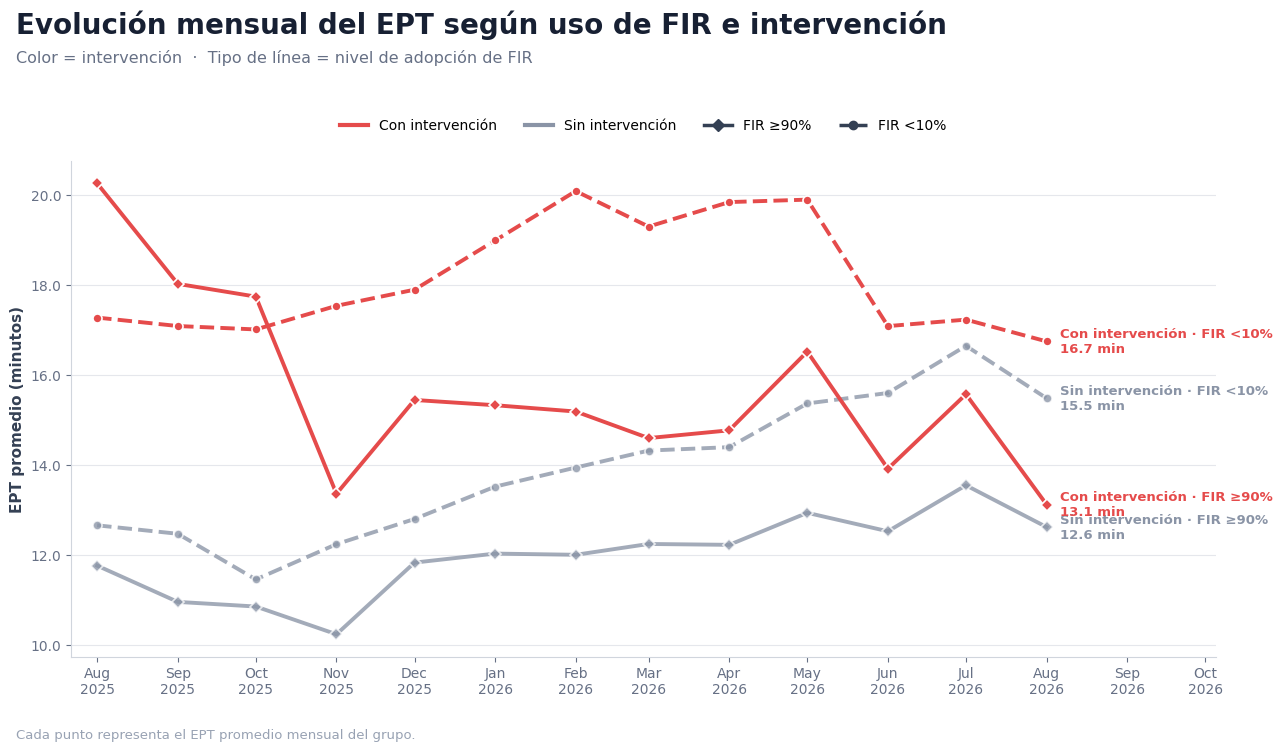

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter


# ============================================================
# PREPARAR DATA
# ============================================================

df_plot = df_4groups.copy()

# Convertir métricas
df_plot["avg_ept_minutes"] = pd.to_numeric(
    df_plot["avg_ept_minutes"],
    errors="coerce"
)

# Convertir mes. Funciona con fechas o etiquetas tipo Aug-26
df_plot["month"] = pd.to_datetime(
    df_plot["month_label"],
    errors="coerce"
)

# Si month_label viene como "Aug-26", usa esto:
if df_plot["month"].isna().all():
    df_plot["month"] = pd.to_datetime(
        df_plot["month_label"],
        format="%b-%y",
        errors="coerce"
    )

# Clasificar los dos ejes del análisis
df_plot["fir_group"] = np.where(
    df_plot["group_name"].str.contains(
        r">=?\s*90|90%",
        case=False,
        regex=True,
        na=False
    ),
    "FIR ≥90%",
    "FIR <10%"
)

# Ojo: primero identificamos "Not reduced",
# porque también contiene la palabra "reduced"
df_plot["intervention_group"] = np.where(
    df_plot["group_name"].str.contains(
        r"not reduced|sin intervención",
        case=False,
        regex=True,
        na=False
    ),
    "Sin intervención",
    "Con intervención"
)

df_plot = (
    df_plot
    .dropna(subset=["month", "avg_ept_minutes"])
    .sort_values(["intervention_group", "fir_group", "month"])
)

# Opcional: excluir agosto de 2026 si todavía está incompleto
# df_plot = df_plot[df_plot["month"] != pd.Timestamp("2026-08-01")]


# ============================================================
# CONFIGURACIÓN VISUAL
# ============================================================

colors = {
    "Sin intervención": "#8A94A6",
    "Con intervención": "#E54B4B",
}

linestyles = {
    "FIR <10%": "--",
    "FIR ≥90%": "-",
}

markers = {
    "FIR <10%": "o",
    "FIR ≥90%": "D",
}

plot_order = [
    ("Sin intervención", "FIR <10%"),
    ("Sin intervención", "FIR ≥90%"),
    ("Con intervención", "FIR <10%"),
    ("Con intervención", "FIR ≥90%"),
]


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7.5))

for intervention, fir in plot_order:

    part = df_plot[
        (df_plot["intervention_group"] == intervention)
        & (df_plot["fir_group"] == fir)
    ].sort_values("month")

    if part.empty:
        continue

    ax.plot(
        part["month"],
        part["avg_ept_minutes"],
        color=colors[intervention],
        linestyle=linestyles[fir],
        marker=markers[fir],
        linewidth=2.8,
        markersize=6.5,
        markeredgecolor="white",
        markeredgewidth=1.2,
        alpha=1 if intervention == "Con intervención" else 0.78,
        zorder=3,
    )

    # Etiqueta directa al final de cada línea
    last = part.iloc[-1]

    ax.annotate(
        (
            f"{intervention} · {fir}\n"
            f"{last['avg_ept_minutes']:.1f} min"
        ),
        xy=(last["month"], last["avg_ept_minutes"]),
        xytext=(10, 0),
        textcoords="offset points",
        color=colors[intervention],
        fontsize=9.5,
        fontweight="semibold",
        va="center",
        annotation_clip=False,
    )


# ============================================================
# TÍTULOS Y EJES
# ============================================================

fig.text(
    0.075,
    0.965,
    "Evolución mensual del EPT según uso de FIR e intervención",
    fontsize=20,
    fontweight="bold",
    color="#172033",
)

fig.text(
    0.075,
    0.925,
    "Color = intervención  ·  Tipo de línea = nivel de adopción de FIR",
    fontsize=11.5,
    color="#667085",
)

ax.set_xlabel("")
ax.set_ylabel(
    "EPT promedio (minutos)",
    fontsize=11,
    fontweight="semibold",
    color="#344054",
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:.1f}")
)

ax.grid(
    axis="y",
    color="#D0D5DD",
    linewidth=0.8,
    alpha=0.55,
)

ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(
    axis="both",
    colors="#667085",
    labelsize=10,
)

# Dejar espacio para las etiquetas a la derecha
months = sorted(df_plot["month"].dropna().unique())

if months:
    ax.set_xlim(
        pd.Timestamp(months[0]) - pd.Timedelta(days=10),
        pd.Timestamp(months[-1]) + pd.Timedelta(days=65),
    )


# ============================================================
# LEYENDA CON SIGNIFICADO VISUAL
# ============================================================

legend_elements = [
    Line2D(
        [0], [0],
        color=colors["Con intervención"],
        linewidth=3,
        label="Con intervención",
    ),
    Line2D(
        [0], [0],
        color=colors["Sin intervención"],
        linewidth=3,
        label="Sin intervención",
    ),
    Line2D(
        [0], [0],
        color="#344054",
        linestyle="-",
        marker="D",
        linewidth=2.5,
        label="FIR ≥90%",
    ),
    Line2D(
        [0], [0],
        color="#344054",
        linestyle="--",
        marker="o",
        linewidth=2.5,
        label="FIR <10%",
    ),
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.11),
    ncol=4,
    frameon=False,
    fontsize=10,
)

fig.text(
    0.075,
    0.025,
    "Cada punto representa el EPT promedio mensual del grupo.",
    fontsize=9.5,
    color="#98A2B3",
)

plt.tight_layout(rect=[0.06, 0.06, 0.99, 0.89])
plt.show()

In [80]:
orders_col = "orders"

df_4groups[orders_col] = pd.to_numeric(df_4groups[orders_col], errors='coerce').fillna(0)

table_order_share = (
    df_4groups
    .groupby("group_name", as_index=False)[orders_col]
    .sum()
    .rename(columns={"group_name": "Grupo"})
)

table_order_share["Share de orders"] = (
    table_order_share[orders_col]
    / table_order_share[orders_col].sum()
).map(lambda x: f"{x:.1%}")

table_order_share = table_order_share[
    ["Grupo", "Share de orders"]
]

display(table_order_share)

,Grupo,Share de orders
0,FIR <10% | Not reduced,38.5%
1,FIR <10% | Reduced,21.6%
2,FIR >=90% | Not reduced,38.4%
3,FIR >=90% | Reduced,1.5%


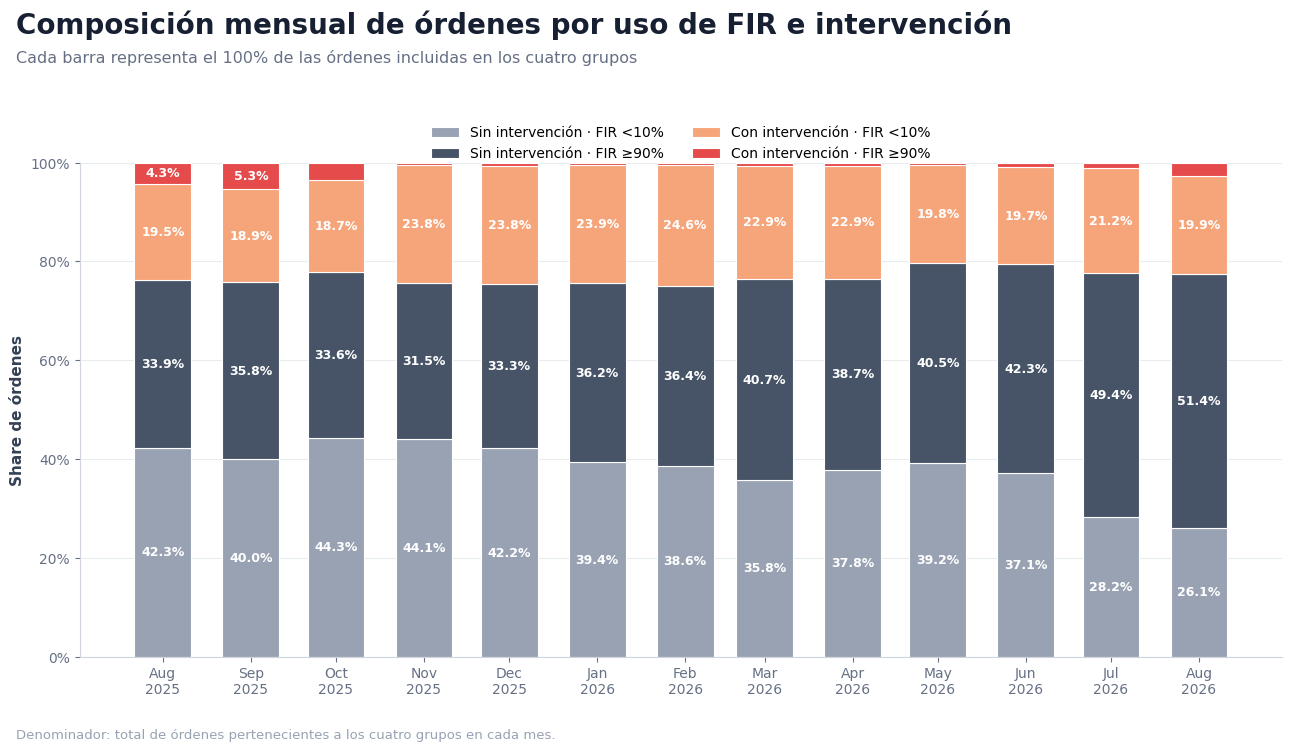

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter


# ============================================================
# CONFIGURACIÓN
# ============================================================

ORDERS_COL = "orders"  # Cambiar si tu columna tiene otro nombre


# ============================================================
# PREPARAR DATA
# ============================================================

df_share = df_4groups.copy()

df_share["month"] = pd.to_datetime(
    df_share["month_label"],
    errors="coerce"
)

# Para etiquetas tipo "Aug-26"
if df_share["month"].isna().all():
    df_share["month"] = pd.to_datetime(
        df_share["month_label"],
        format="%b-%y",
        errors="coerce"
    )

df_share[ORDERS_COL] = pd.to_numeric(
    df_share[ORDERS_COL],
    errors="coerce"
).fillna(0)

# Clasificación FIR
df_share["fir_group"] = np.where(
    df_share["group_name"].str.contains(
        r"(?:>=|≥|>)\s*90|90%",
        case=False,
        regex=True,
        na=False
    ),
    "FIR ≥90%",
    "FIR <10%"
)

# Clasificación intervención
df_share["intervention_group"] = np.where(
    df_share["group_name"].str.contains(
        r"not reduced|sin intervención",
        case=False,
        regex=True,
        na=False
    ),
    "Sin intervención",
    "Con intervención"
)

df_share["plot_group"] = (
    df_share["intervention_group"]
    + " · "
    + df_share["fir_group"]
)

df_share = df_share.dropna(subset=["month"])


# ============================================================
# CALCULAR SHARE MENSUAL
# ============================================================

group_order = [
    "Sin intervención · FIR <10%",
    "Sin intervención · FIR ≥90%",
    "Con intervención · FIR <10%",
    "Con intervención · FIR ≥90%",
]

orders_monthly = (
    df_share
    .pivot_table(
        index="month",
        columns="plot_group",
        values=ORDERS_COL,
        aggfunc="sum",
        fill_value=0
    )
    .reindex(columns=group_order, fill_value=0)
    .sort_index()
)

share_monthly = orders_monthly.div(
    orders_monthly.sum(axis=1).replace(0, np.nan),
    axis=0
)

# Opcional: excluir agosto si sigue incompleto
# share_monthly = share_monthly[
#     share_monthly.index != pd.Timestamp("2026-08-01")
# ]


# ============================================================
# PLOT
# ============================================================

colors = {
    "Sin intervención · FIR <10%": "#98A2B3",
    "Sin intervención · FIR ≥90%": "#475467",
    "Con intervención · FIR <10%": "#F6A57A",
    "Con intervención · FIR ≥90%": "#E54B4B",
}

fig, ax = plt.subplots(figsize=(14, 7.5))

bottom = np.zeros(len(share_monthly))

for group in group_order:

    values = share_monthly[group].fillna(0).values

    bars = ax.bar(
        share_monthly.index,
        values,
        bottom=bottom,
        width=20,
        color=colors[group],
        edgecolor="white",
        linewidth=0.8,
        label=group,
    )

    # Mostrar etiqueta solo cuando el segmento sea suficientemente grande
    for bar, value, base in zip(bars, values, bottom):
        if value >= 0.04:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                base + value / 2,
                f"{value:.1%}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="semibold",
                color="white",
            )

    bottom += values


# ============================================================
# FORMATO
# ============================================================

fig.text(
    0.075,
    0.965,
    "Composición mensual de órdenes por uso de FIR e intervención",
    fontsize=20,
    fontweight="bold",
    color="#172033",
)

fig.text(
    0.075,
    0.925,
    "Cada barra representa el 100% de las órdenes incluidas en los cuatro grupos",
    fontsize=11.5,
    color="#667085",
)

ax.set_xlabel("")
ax.set_ylabel(
    "Share de órdenes",
    fontsize=11,
    fontweight="semibold",
    color="#344054",
)

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.grid(
    axis="y",
    color="#D0D5DD",
    linewidth=0.8,
    alpha=0.45,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(
    axis="both",
    colors="#667085",
    labelsize=10,
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=2,
    frameon=False,
    fontsize=10,
)

fig.text(
    0.075,
    0.025,
    "Denominador: total de órdenes pertenecientes a los cuatro grupos en cada mes.",
    fontsize=9.5,
    color="#98A2B3",
)

plt.tight_layout(rect=[0.06, 0.06, 0.99, 0.88])
plt.show()

In [82]:
metrics = [
    "avg_ept_minutes",
    "highpreptime_pct",
    "awt10_pct",
    "partner_performance_pct",
]

print(
    "Período:",
    df_4groups["month_start"].min(),
    "a",
    df_4groups["month_start"].max()
)

duplicates = (
    df_4groups
    .groupby(["month_start", "group_name"])
    .size()
    .loc[lambda x: x > 1]
)

print("\nDuplicados month-group:")
print(duplicates if not duplicates.empty else "No hay duplicados")

for metric in metrics:
    print(f"\n===== {metric} =====")
    display(
        df_4groups.pivot(
            index="month_start",
            columns="group_name",
            values=metric,
        )
    )

Período: 2025-08-01 a 2026-08-01

Duplicados month-group:
No hay duplicados

===== avg_ept_minutes =====


group_name,FIR <10% | Not reduced,FIR <10% | Reduced,FIR >=90% | Not reduced,FIR >=90% | Reduced
month_start,,,,
2025-08-01,12.66578391,17.27526149,11.77110867,20.25320554
2025-09-01,12.47813634,17.0881359,10.96659569,18.02351973
2025-10-01,11.46481757,17.01210198,10.86407171,17.74027296
2025-11-01,12.24754335,17.53637656,10.24801437,13.36613272
2025-12-01,12.80616132,17.89436164,11.83847881,15.44743293
2026-01-01,13.52410501,18.98666248,12.03845513,15.33070725
2026-02-01,13.9475023,20.08151792,12.01179908,15.1908362
2026-03-01,14.32451235,19.294568,12.25196433,14.60145124
2026-04-01,14.40023722,19.83799171,12.23265584,14.77356542



===== highpreptime_pct =====


group_name,FIR <10% | Not reduced,FIR <10% | Reduced,FIR >=90% | Not reduced,FIR >=90% | Reduced
month_start,,,,
2025-08-01,0.2185496358,1.569849108,0.04369137706,0.9843991475
2025-09-01,0.2921198612,1.80847266,0.04054340737,0.6790488043
2025-10-01,0.1944036895,2.19525452,0.03463505812,0.2450057853
2025-11-01,0.1949866501,2.151649003,0.03931131126,1.315108423
2025-12-01,0.2228280747,2.239703266,0.07675836065,2.148304508
2026-01-01,0.2346903333,2.420545183,0.1133993427,2.319456879
2026-02-01,0.1921957278,3.310890465,0.05208904861,3.55288278
2026-03-01,0.1566837683,2.774747282,0.06268464307,2.522718025
2026-04-01,0.09948465861,3.08297796,0.075576962,3.063996656



===== awt10_pct =====


group_name,FIR <10% | Not reduced,FIR <10% | Reduced,FIR >=90% | Not reduced,FIR >=90% | Reduced
month_start,,,,
2025-08-01,0.2693404456,1.697462018,0.1301179226,2.040482054
2025-09-01,0.2868260525,1.566113326,0.1320148869,1.976765035
2025-10-01,0.2746213045,1.693710217,0.1428815414,2.11559998
2025-11-01,0.3361242882,2.058648311,0.1068039868,2.253595946
2025-12-01,0.3786024964,2.205623581,0.1446536037,1.82032775
2026-01-01,0.2754522335,1.723017461,0.1235614682,1.53685467
2026-02-01,0.3274206139,2.08276591,0.08459755295,0.93069874
2026-03-01,0.2730684022,1.826594189,0.07894218546,2.02088702
2026-04-01,0.265513634,1.76035896,0.07842078177,2.299995083



===== partner_performance_pct =====


group_name,FIR <10% | Not reduced,FIR <10% | Reduced,FIR >=90% | Not reduced,FIR >=90% | Reduced
month_start,,,,
2025-08-01,1.759406996,7.716449085,0.8136109182,7.547895157
2025-09-01,1.882089546,8.00385752,0.8577628315,7.064006019
2025-10-01,1.614897975,8.264962395,0.8118366981,7.094479993
2025-11-01,1.878390405,8.939817763,0.6835189291,13.85188515
2025-12-01,2.132171676,9.384654493,0.7873347488,12.47730265
2026-01-01,1.937926932,8.845173775,0.8024174796,11.12876753
2026-02-01,1.962906419,10.66778119,0.6165756794,18.40206186
2026-03-01,1.731385691,9.43918876,0.6061216451,13.98062751
2026-04-01,1.590547932,9.792106731,0.7229087922,16.91252397


# Gráficos finales de impacto

Las curvas usan shares sobre todas las órdenes del grupo e incluyen `AWT null`,
`AWT0`, `AWT1` y la cola completa. Post es sólido y dominante; Pre queda
punteado y más opaco. `AWT10 causal` se mantiene separado de `awt_10min`, que es
solo el bucket de distribución entre 9 y 10 minutos.


In [83]:
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ============================================================
# FORMATOS Y DETALLES DE CADA PANEL
# ============================================================

def fmt_plot_date(value):
    value = pd.to_datetime(value, errors="coerce")
    return "N/A" if pd.isna(value) else value.strftime("%d/%m")


def fmt_plot_number(value):
    value = pd.to_numeric(value, errors="coerce")
    return "N/A" if pd.isna(value) else f"{value:,.0f}"


def fmt_plot_pct(value):
    value = pd.to_numeric(value, errors="coerce")
    return "N/A" if pd.isna(value) else f"{value:.2f}%"


def natural_wave_key(value):
    match = re.search(r"(\d+)", str(value))
    return (
        int(match.group(1)) if match else float("inf"),
        str(value),
    )


def detail_line_from_holy_row(row, include_wave=False):
    prefix = f"{row['wave']} · " if include_wave else ""

    return (
        f"{prefix}Pre {fmt_plot_date(row['Pre inicio'])}–"
        f"{fmt_plot_date(row['Pre fin'])} | "
        f"Post {fmt_plot_date(row['Post inicio'])}–"
        f"{fmt_plot_date(row['Post fin'])}\n"
        f"Vendors: {fmt_plot_number(row['Vendors'])} | "
        f"Franquicias: {fmt_plot_number(row['Franchises'])} | "
        f"Orders Pre: {fmt_plot_number(row['Pre #Orders'])} "
        f"({fmt_plot_pct(row['% Orders CL Pre'])} CL) | "
        f"Orders Post: {fmt_plot_number(row['Post #Orders'])} "
        f"({fmt_plot_pct(row['% Orders CL Post'])} CL)"
    )


# Detalles por wave.
plot_info_wave = {
    str(row["wave"]): detail_line_from_holy_row(row)
    for _, row in appendix_holy_wave.iterrows()
}


# Detalles por wave + flag.
appendix_awt_wave_flag_plot = appendix_awt_wave_flag.copy()
appendix_awt_wave_flag_plot["panel"] = (
    appendix_awt_wave_flag_plot["wave"].astype(str)
    + "\n"
    + appendix_awt_wave_flag_plot["flag"].astype(str)
)

appendix_awt_detailed_wave_flag_plot = (
    appendix_awt_detailed_wave_flag.copy()
)
appendix_awt_detailed_wave_flag_plot["panel"] = (
    appendix_awt_detailed_wave_flag_plot["wave"].astype(str)
    + "\n"
    + appendix_awt_detailed_wave_flag_plot["flag"].astype(str)
)

plot_info_wave_flag = {}

for _, row in appendix_holy_wave_flag.iterrows():
    panel = f"{row['wave']}\n{row['flag']}"
    plot_info_wave_flag[panel] = detail_line_from_holy_row(row)


# Detalles por flag. Cada wave conserva su período y volumen propio.
plot_info_flag = {}

for flag, group in appendix_holy_wave_flag.groupby(
    "flag",
    dropna=False,
):
    group = group.copy()
    group["_sort_date"] = pd.to_datetime(
        group["Post inicio"],
        errors="coerce",
    )
    group = group.sort_values("_sort_date")

    plot_info_flag[str(flag)] = "\n".join(
        detail_line_from_holy_row(row, include_wave=True)
        for _, row in group.iterrows()
    )


# ============================================================
# GRÁFICO ESTÁNDAR
# ============================================================

def plot_awt_distribution_facets(
    distribution_df,
    facet_col,
    title,
    plot_info,
    ncols=1,
    curve_buckets=None,
    bucket_labels=None,
):
    """
    Un panel por wave, wave+flag o flag.
    Siempre muestra:
    - los buckets solicitados para la vista;
    - cifras Pre y Post;
    - fechas, orders, vendors, franquicias y % Orders CL.
    """

    df = distribution_df.copy()
    curve_buckets = list(
        AWT_CURVE_BUCKETS
        if curve_buckets is None
        else curve_buckets
    )
    bucket_labels = (
        AWT_BUCKET_LABELS
        if bucket_labels is None
        else bucket_labels
    )

    required_columns = {
        facet_col,
        "bucket",
        "bucket_label",
        "bucket_order",
        "pre_share_pct",
        "post_share_pct",
    }

    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise KeyError(
            "Faltan columnas para el gráfico AWT: "
            + ", ".join(sorted(missing_columns))
        )

    df = df[df["bucket"].isin(curve_buckets)].copy()

    for column in [
        "bucket_order",
        "pre_share_pct",
        "post_share_pct",
    ]:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    df = df.dropna(subset=[facet_col, "bucket_order"])
    df[facet_col] = df[facet_col].astype(str)

    if facet_col == "wave":
        facets = sorted(
            df[facet_col].unique(),
            key=natural_wave_key,
        )
    elif facet_col == "panel":
        facets = sorted(
            df[facet_col].unique(),
            key=lambda value: (
                natural_wave_key(str(value).split("\n", 1)[0]),
                str(value),
            ),
        )
    else:
        facets = sorted(df[facet_col].unique())

    if not facets:
        print(f"No hay datos para graficar por {facet_col}.")
        return

    ncols = min(ncols, len(facets))
    nrows = math.ceil(len(facets) / ncols)

    detail_lines = [
        len(plot_info.get(str(facet), "").splitlines())
        for facet in facets
    ]

    max_detail_lines = max(detail_lines + [1])
    panel_height = 6.5 + 0.42 * max_detail_lines

    panel_width = max(13.5, 1.35 * len(curve_buckets))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        sharey=True,
        squeeze=False,
    )

    axes = axes.ravel()

    all_values = pd.concat(
        [df["pre_share_pct"], df["post_share_pct"]],
        ignore_index=True,
    ).replace([np.inf, -np.inf], np.nan)

    global_max = all_values.max()
    if pd.isna(global_max) or global_max <= 0:
        global_max = 1

    # Espacio para ambas cifras, incluso en el mayor punto.
    y_upper = global_max * 1.35

    pre_handle = None
    post_handle = None

    for ax, facet in zip(axes, facets):

        part = (
            df[df[facet_col].eq(str(facet))]
            .sort_values("bucket_order")
            .set_index("bucket")
            .reindex(curve_buckets)
            .reset_index()
        )

        x = np.arange(len(part))

        pre_handle, = ax.plot(
            x,
            part["pre_share_pct"],
            color="#94A3B8",
            linewidth=2.4,
            linestyle="--",
            marker="o",
            markersize=7,
            markeredgecolor="white",
            markeredgewidth=1,
            label="Pre",
            zorder=2,
        )

        post_handle, = ax.plot(
            x,
            part["post_share_pct"],
            color="#2563EB",
            linewidth=3.2,
            linestyle="-",
            marker="o",
            markersize=8,
            markeredgecolor="white",
            markeredgewidth=1,
            label="Post",
            zorder=3,
        )

        # Cifras de ambas líneas. Gris = Pre; azul = Post.
        for x_value, pre_value, post_value in zip(
            x,
            part["pre_share_pct"],
            part["post_share_pct"],
        ):
            close_values = (
                pd.notna(pre_value)
                and pd.notna(post_value)
                and abs(pre_value - post_value) < y_upper * 0.055
            )

            if pd.notna(pre_value):
                pre_offset = -16 if close_values else 10
                ax.annotate(
                    f"{pre_value:.1f}%",
                    xy=(x_value, pre_value),
                    xytext=(-7, pre_offset),
                    textcoords="offset points",
                    ha="right",
                    va="top" if pre_offset < 0 else "bottom",
                    fontsize=12,
                    fontweight="semibold",
                    color="#64748B",
                    annotation_clip=False,
                )

            if pd.notna(post_value):
                ax.annotate(
                    f"{post_value:.1f}%",
                    xy=(x_value, post_value),
                    xytext=(7, 11),
                    textcoords="offset points",
                    ha="left",
                    va="bottom",
                    fontsize=12,
                    fontweight="bold",
                    color="#2563EB",
                    annotation_clip=False,
                )

        facet_title = str(facet).replace("\n", " · ")
        details = plot_info.get(str(facet), "")

        ax.set_title(
            facet_title,
            fontsize=16,
            fontweight="bold",
            color="#172033",
            pad=76 + max_detail_lines * 10,
        )

        ax.text(
            0.5,
            1.025,
            details,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=10,
            color="#667085",
            linespacing=1.35,
            wrap=True,
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            [bucket_labels[bucket] for bucket in curve_buckets],
            fontsize=10,
            fontweight="semibold",
        )

        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda value, _: f"{value:.1f}%")
        )

        ax.set_ylim(0, y_upper)
        ax.set_xlim(-0.45, len(part) - 0.55)

        ax.grid(
            axis="y",
            color="#D0D5DD",
            linewidth=0.8,
            alpha=0.45,
        )

        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_color("#D0D5DD")
        ax.tick_params(axis="both", colors="#667085")
        ax.tick_params(axis="y", labelleft=False, length=0)

    for ax in axes[len(facets):]:
        ax.set_visible(False)

    fig.suptitle(
        title,
        fontsize=18,
        fontweight="bold",
        color="#172033",
        y=0.998,
    )

    fig.supxlabel(
        "Bucket de AWT",
        fontsize=11,
        color="#475467",
        y=0.01,
    )

    fig.supylabel(
        "Share sobre órdenes totales",
        fontsize=11,
        color="#344054",
        x=0.01,
    )

    fig.legend(
        handles=[post_handle, pre_handle],
        labels=["Post", "Pre"],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.968),
        ncol=2,
        frameon=False,
        fontsize=10,
    )

    plt.tight_layout(
        rect=[0.035, 0.04, 0.99, 0.90],
        h_pad=8,
        w_pad=3,
    )

    plt.show()


# ============================================================
# GRÁFICOS FINALES
# ============================================================

plot_awt_distribution_facets(
    distribution_df=appendix_awt_wave,
    facet_col="wave",
    title="Distribución AWT Pre vs Post — por wave",
    plot_info=plot_info_wave,
    ncols=1,
)

plot_awt_distribution_facets(
    distribution_df=appendix_awt_wave_flag_plot,
    facet_col="panel",
    title="Distribución AWT Pre vs Post — por wave y flag",
    plot_info=plot_info_wave_flag,
    ncols=1,
)

plot_awt_distribution_facets(
    distribution_df=appendix_awt_flag,
    facet_col="flag",
    title="Distribución AWT Pre vs Post — por flag",
    plot_info=plot_info_flag,
    ncols=1,
)


# Vista adicional detallada: Null, 0, 1, ..., 10, 11+.
plot_awt_distribution_facets(
    distribution_df=appendix_awt_detailed_wave,
    facet_col="wave",
    title="Distribución AWT detallada Pre vs Post — por wave",
    plot_info=plot_info_wave,
    ncols=1,
    curve_buckets=AWT_DETAILED_BUCKETS,
    bucket_labels=AWT_DETAILED_BUCKET_LABELS,
)

plot_awt_distribution_facets(
    distribution_df=appendix_awt_detailed_wave_flag_plot,
    facet_col="panel",
    title="Distribución AWT detallada Pre vs Post — por wave y flag",
    plot_info=plot_info_wave_flag,
    ncols=1,
    curve_buckets=AWT_DETAILED_BUCKETS,
    bucket_labels=AWT_DETAILED_BUCKET_LABELS,
)

plot_awt_distribution_facets(
    distribution_df=appendix_awt_detailed_flag,
    facet_col="flag",
    title="Distribución AWT detallada Pre vs Post — por flag",
    plot_info=plot_info_flag,
    ncols=1,
    curve_buckets=AWT_DETAILED_BUCKETS,
    bucket_labels=AWT_DETAILED_BUCKET_LABELS,
)


Output hidden; open in https://colab.research.google.com to view.